In [17]:
import pprint
import itertools
import pprint
from pathlib import Path
import pprint
from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

import sys
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')
from src import ExperimentParser, PosteriorUtilities, StandardLogisticSource

In [18]:
# TODO rodar com matriz gabarito sendo a identidade
# TODO rodar com outra prior errada
# TODO colocar gabarito nas figuras com modelo errado

# 1. Read and parse raw results

In [21]:
# Experiment name
EXPERIMENT_NAME = 'CBA_SBRT_posterior_broad_analysis'

# Whether or not to save graphs
SAVE_GRAPHS=True

# Whether or not to create folder structure for saving results
CREATE_FOLDER_STRUCTURE = True

# Folder which will contain output directory tree
OUTPUT_DIR='./output'
base_output_path=Path(OUTPUT_DIR)

# Directory which holds experiments
experiment_dir = base_output_path / EXPERIMENT_NAME

# Instantiate and execute parser object
parser = ExperimentParser(experiment_dir)
parser.parse(verbose=True)


['0']
####################################################################################################
Total of 1 realizations with executed results
----------------------------------------------------------------------------------------------------
Total of 0 realizations without executed results
####################################################################################################


# 2. Distributions

In [22]:
def test_case_samples(
    case,
    realization,
    parser,
    B,
    discard_zero_var=True,
    samples_per_chain=None
):
    
    test_case_mapping = {
        'i': 1,
        'ii': 2,
        'iii': 3,
        'iv': 4,
        'v': 5,
        'vi': 6,
        'vii': 7,
        'viii': 8,
        'ix': 9,
        'x': 10,
        'xi': 11,
        'xii': 12
    }

    test_case_signal_mapping = {
        'i': 'perfect_model',
        'ii': 'perfect_model',
        'iii': 'perfect_model',
        'iv': 'perfect_model',
        'v': 'slightly_misspecified_model',
        'vi': 'slightly_misspecified_model',
        'vii': 'slightly_misspecified_model',
        'viii': 'slightly_misspecified_model',
        'ix': 'largely_misspecified_model',
        'x': 'largely_misspecified_model',
        'xi': 'largely_misspecified_model',
        'xii': 'largely_misspecified_model'
    }

    test_case_prior_mapping = {
        'i': 'likelihood',
        'ii': 'non_informative_prior',
        'iii': 'informative_prior',
        'iv': 'identity_transform',
        'v': 'likelihood',
        'vi': 'non_informative_prior',
        'vii': 'informative_prior',
        'viii': 'identity_transform',
        'ix': 'likelihood',
        'x': 'non_informative_prior',
        'xi': 'informative_prior',
        'xii': 'identity_transform'
    }

    # Get source model
    source_pdf = StandardLogisticSource().get()

    # Get prior
    prior_pdf = parser.execution_config['sim']['priors'][test_case_prior_mapping[case]].get()

    # Get posterior
    posterior_fn = PosteriorUtilities.get_log_posterior_fn(
            source_pdf_fn=source_pdf,
            prior_pdf_fn=prior_pdf
    )

    # Get mixture signal
    x = parser.realizations_results[str(0)][
            test_case_signal_mapping[case]
    ]['x']
    
    if samples_per_chain is not None:
        SAMPLES_PER_CHAIN=samples_per_chain
    else:
        SAMPLES_PER_CHAIN = parser.execution_config['mcmc']['n_samples']//parser.execution_config['mcmc']['parallel_chains']
        
    STARTING_DIST_LOW=-5
    STARTING_DIST_HIGH=5

    samples_chains = [
        chain_samples[-SAMPLES_PER_CHAIN:,:,:] for chain_samples in parser.parsed_results[case]['mmse']['object'][0].samples
    ]

    discard_chain = []
    for c_samples in samples_chains:
        discard=True
        for i,j in np.ndindex(B.shape):
            if np.var(c_samples[:1000,i,j])>1E-10:
                discard=False

        discard_chain.append(discard)
    
    retained_chains_samples = [
        c_samples for c_samples, discard in zip(
            samples_chains, discard_chain
        ) if not discard
    ]    
    samples = np.concatenate(
        retained_chains_samples,
        axis=0
    )
    
    R_idx = np.where(
        np.array(parser.parsed_results[case]['realization'])==realization
    )[0][0]
    converged = parser.parsed_results[case]['mmse']['object'][R_idx].converged
    # estimated_mode = executor.cfg['sim']['test_cases'][case]['estimated_mode']
    diagnostics = parser.parsed_results[case]['mmse']['object'][R_idx].diagnostics

    dist_fig, dist_axs = plt.subplots(
        nrows=2, ncols=2,
        figsize=(20,15)
    )

    for i, j in np.ndindex(B.shape):
        dist_axs[i,j].hist(
            samples[:,i,j],
            alpha=0.3,
            bins='auto',
            color='cornflowerblue'
        )
        
        dist_axs[i,j].legend()

    # Get unique samples
    unique_samples = np.unique(
        samples,
        axis=0
    )


    print('Cadeias retidas: {}'.format(len(retained_chains_samples)))
    print('R-hat convergiu? {}'.format(converged))

    # Plot trajectories
    traj_fig, traj_axs = plt.subplots(
        nrows=2, ncols=2,
        figsize=(20,15)
    )

    for i, j in np.ndindex(B.shape):
        for c_samples in retained_chains_samples:
            traj_axs[i,j].plot(
                c_samples[:,i,j],
                linewidth=.5
            )

        traj_axs[i,j].set_ylim(STARTING_DIST_LOW,STARTING_DIST_HIGH)
        traj_axs[i,j].set_xlabel(r'iteration', fontsize=10)
        traj_axs[i,j].set_ylabel(r'b_{}{}'.format(i,j), fontsize=10)
    
    return diagnostics



Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,11.574282,5.039996,10.90085,5.045239,11.73102,5.038972,11.632327,5.03973


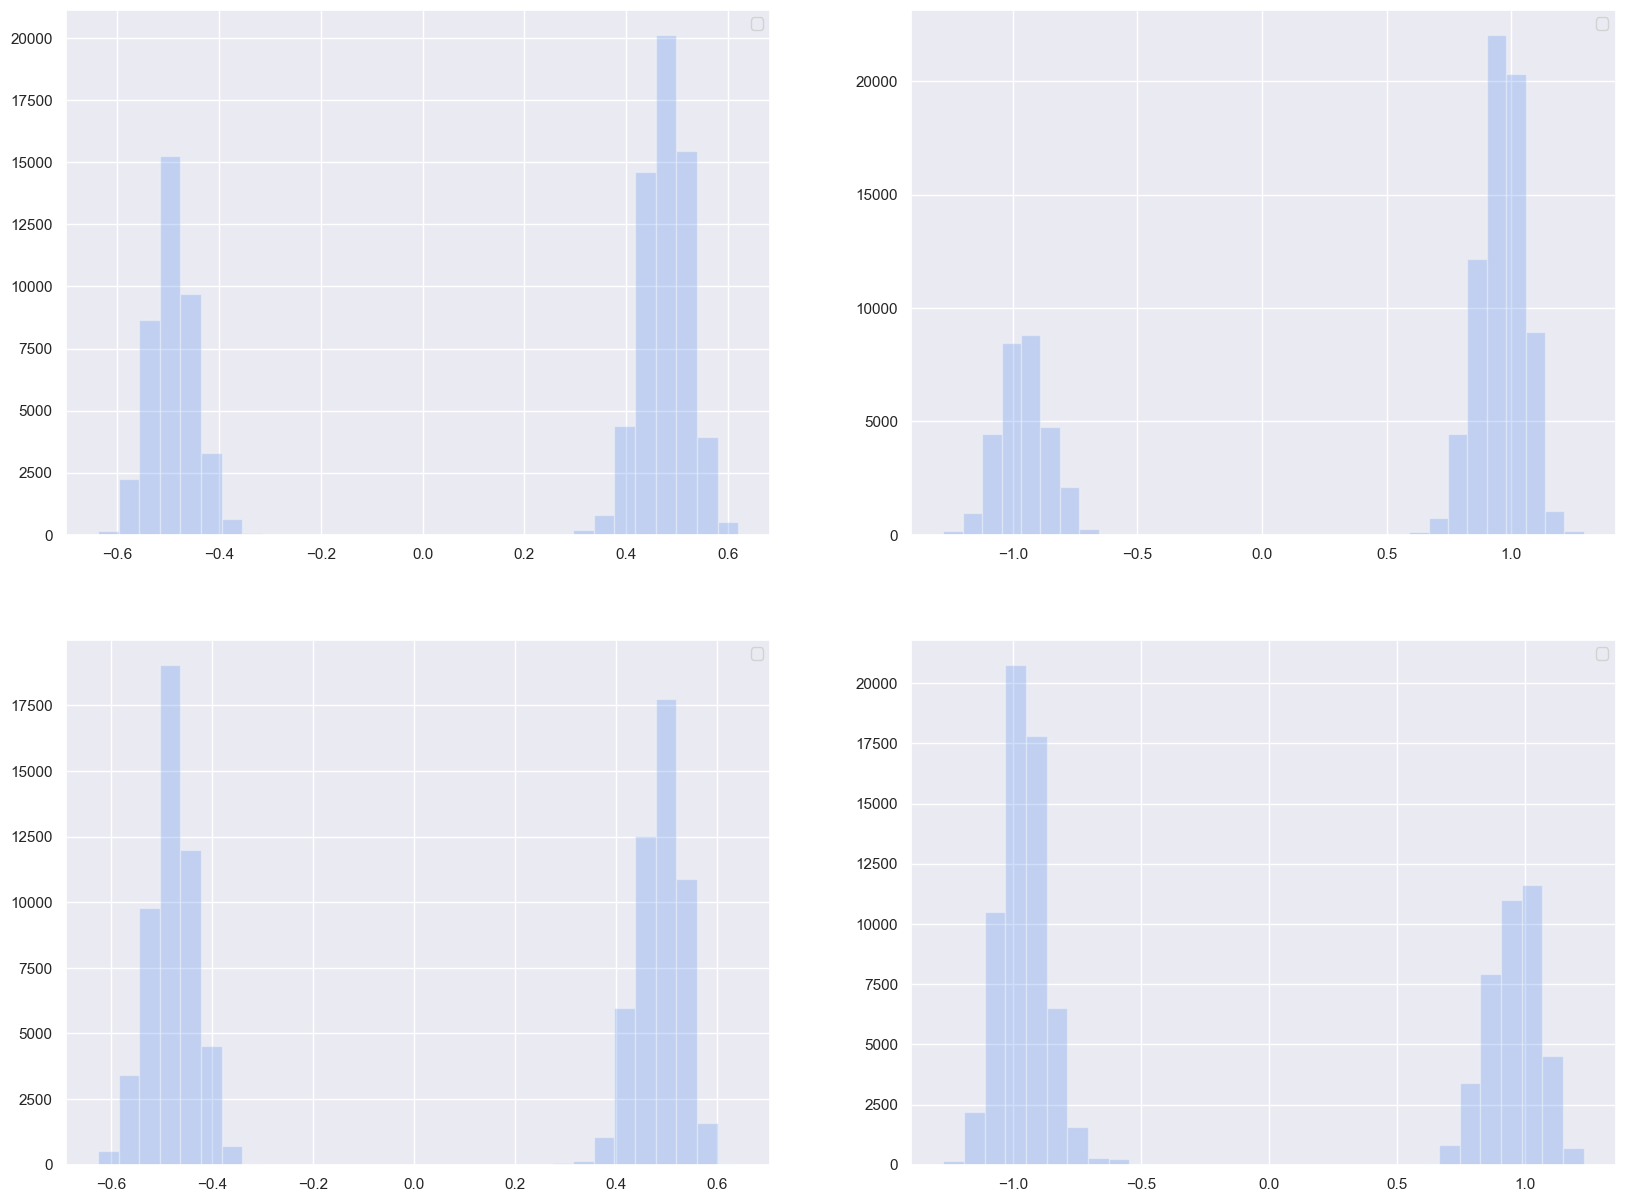

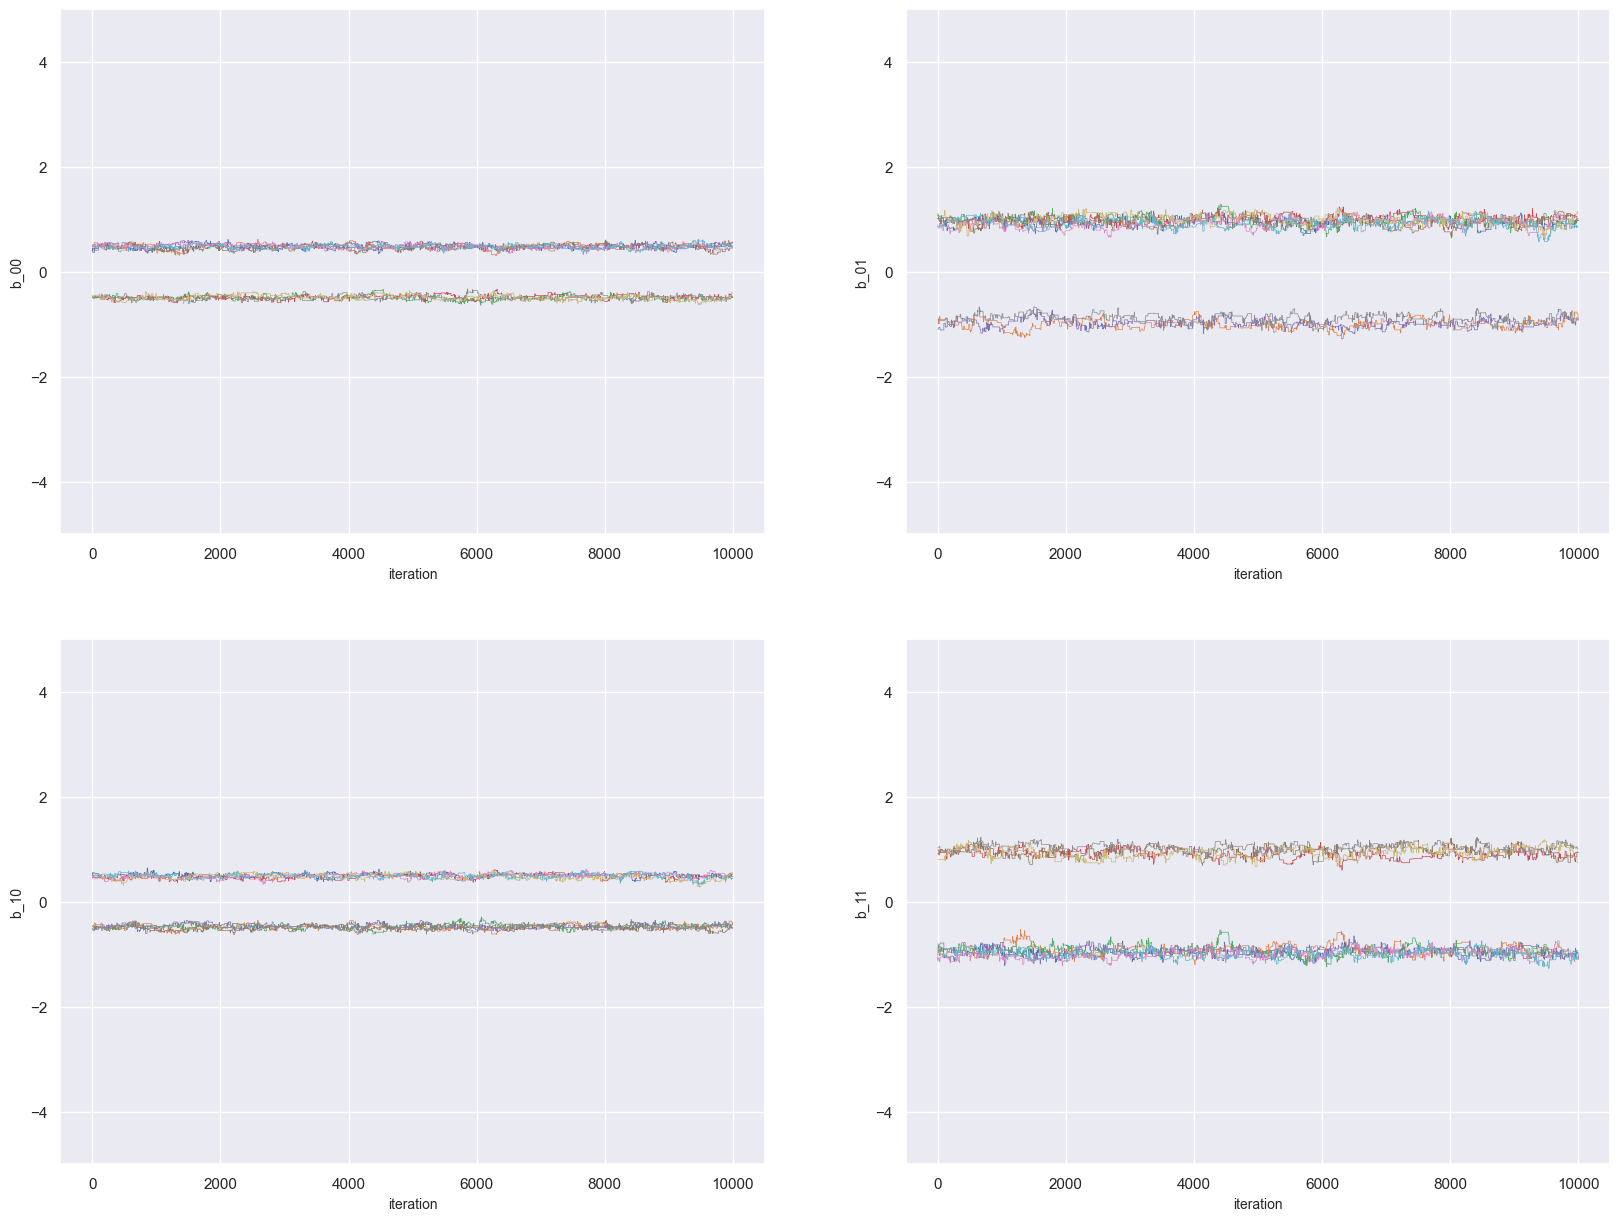

In [24]:
CASE = 'i'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B']
)

Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,11.783803,5.038469,10.832126,5.045401,11.581331,5.039522,11.832892,5.037738


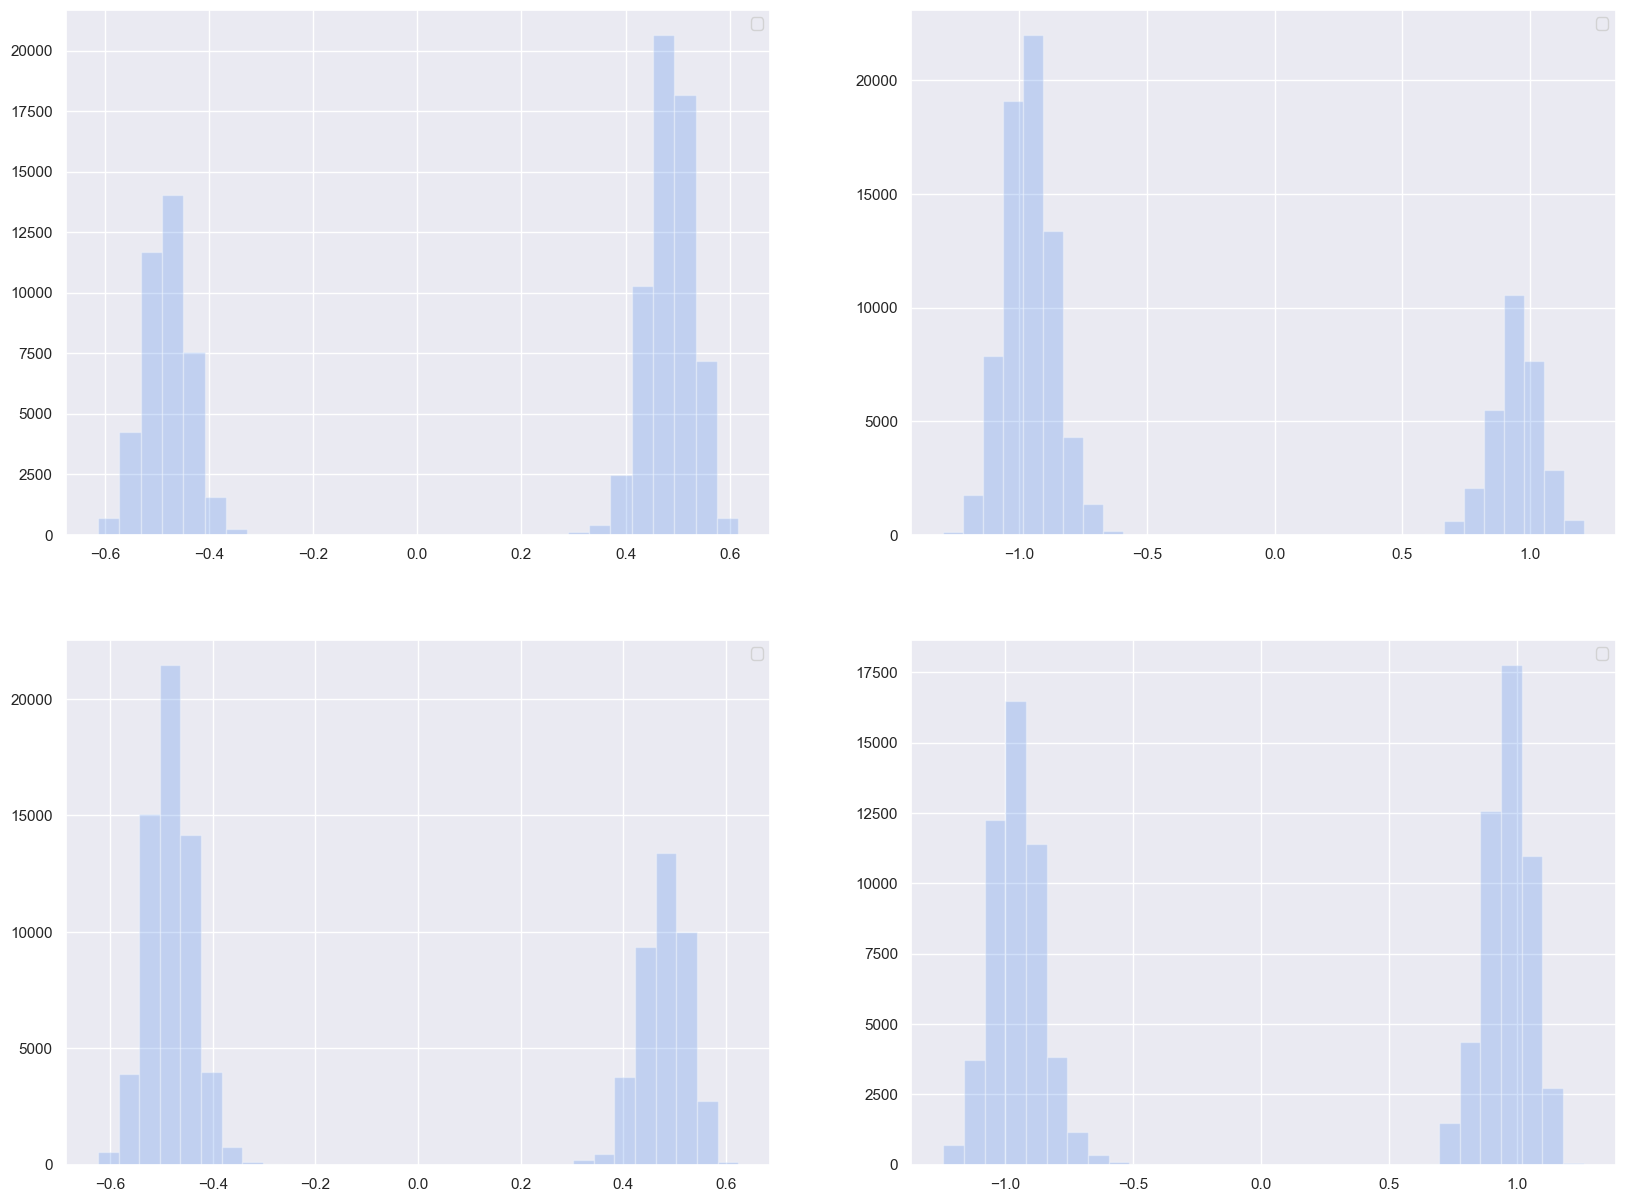

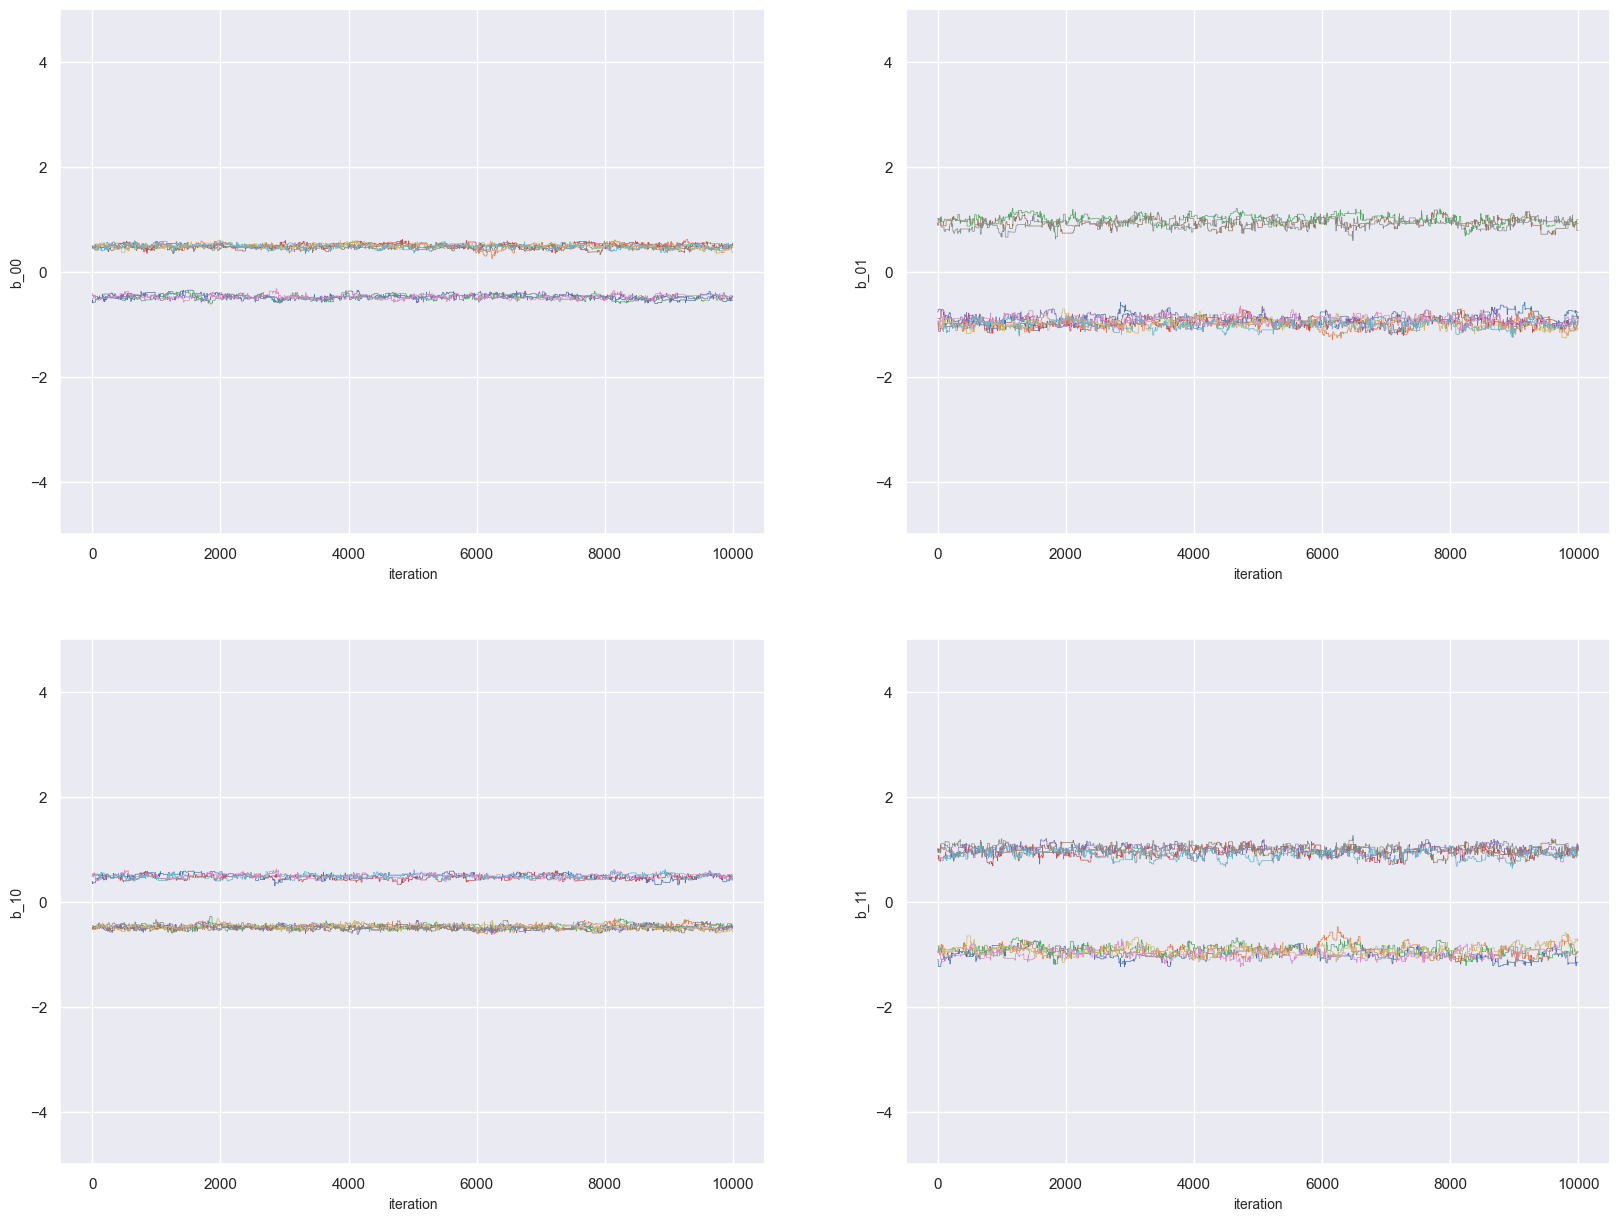

In [25]:
CASE = 'ii'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B']
)

Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,1.00343,965.031248,1.004018,821.017517,1.003778,861.216029,1.003666,852.302334


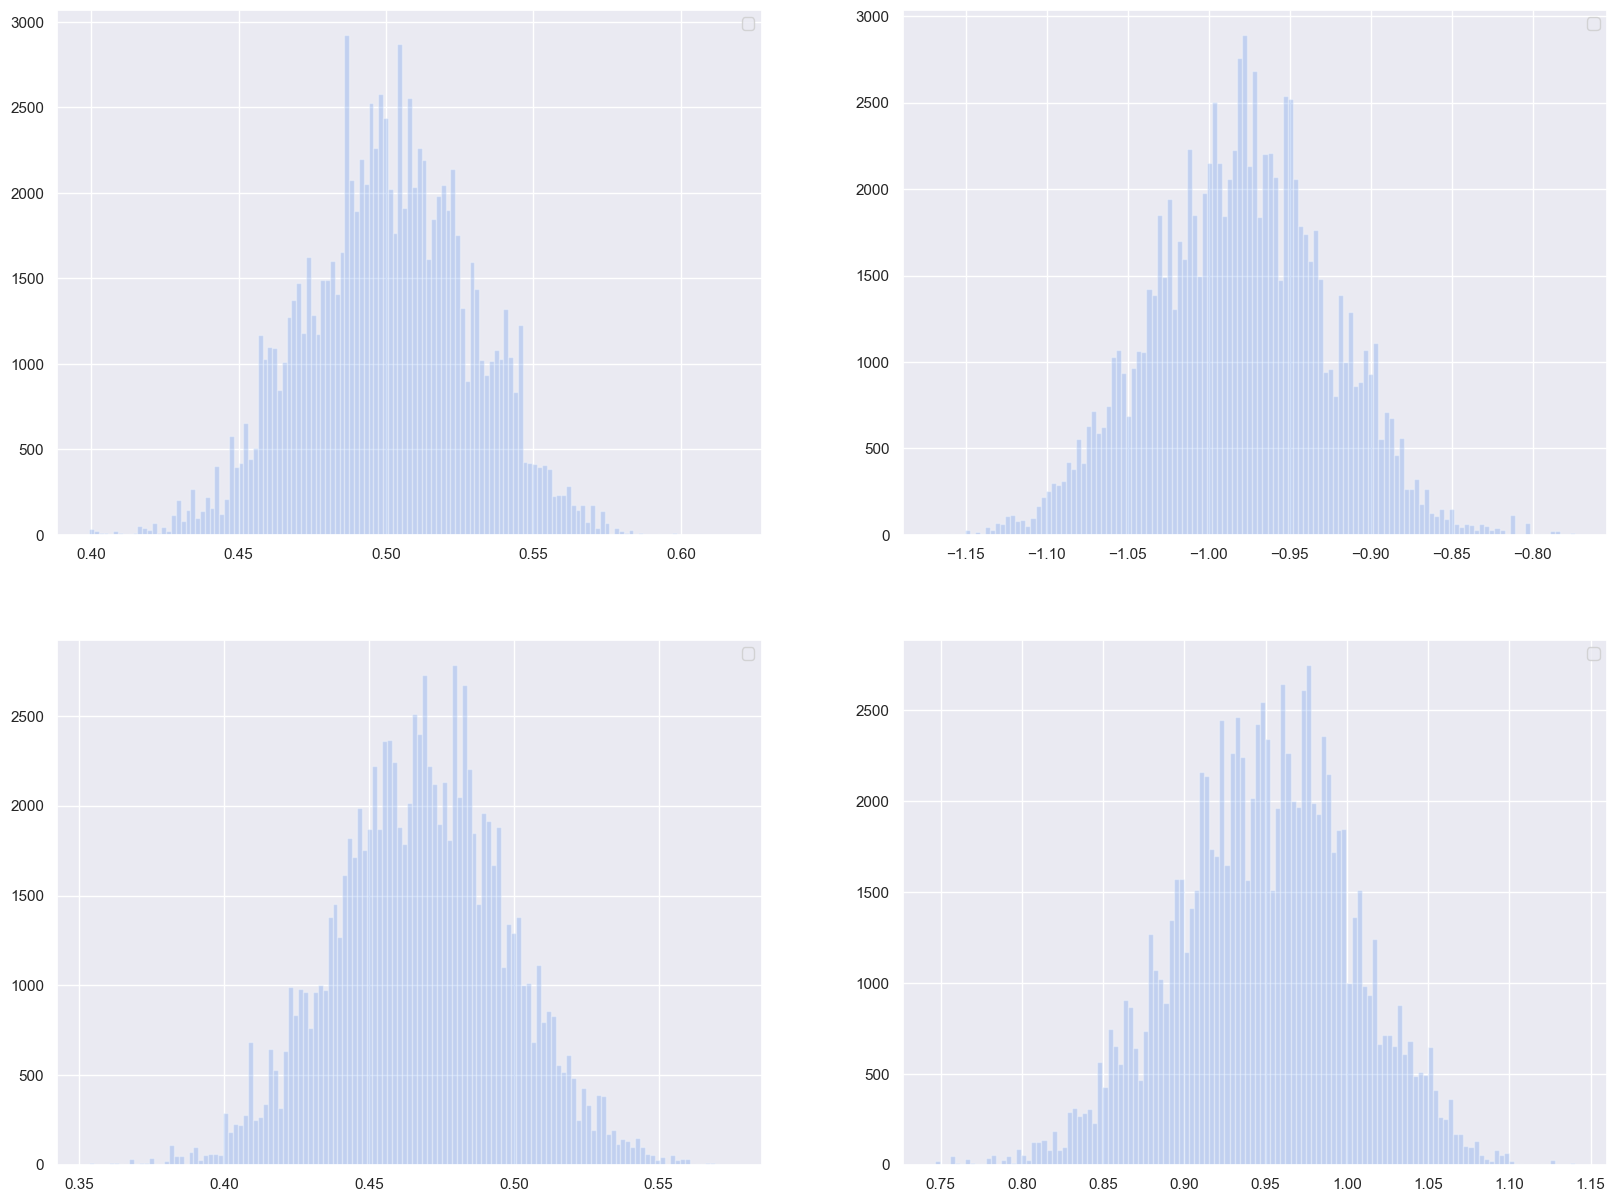

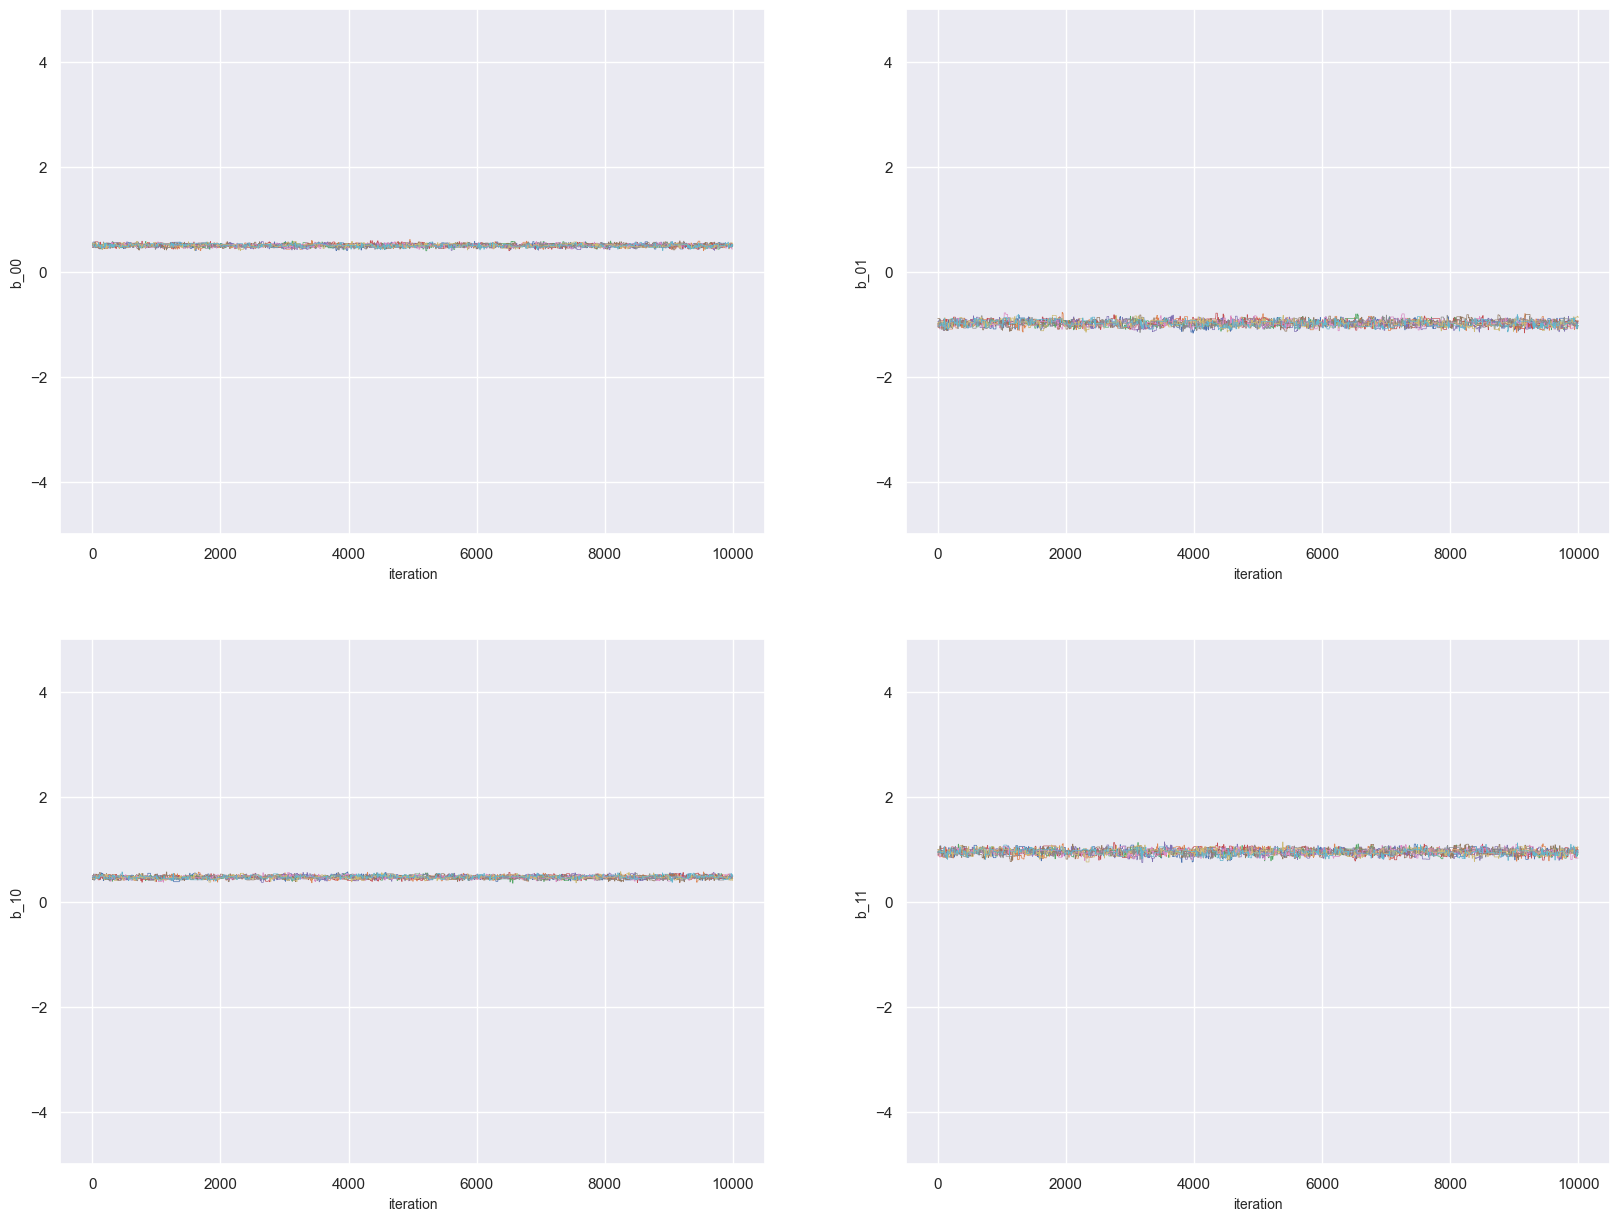

In [26]:
CASE = 'iii'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
)

Cadeias retidas: 9
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,1.043802,109.210076,1.895072,NaN,2.023531,6.792065,13.123781,NaN


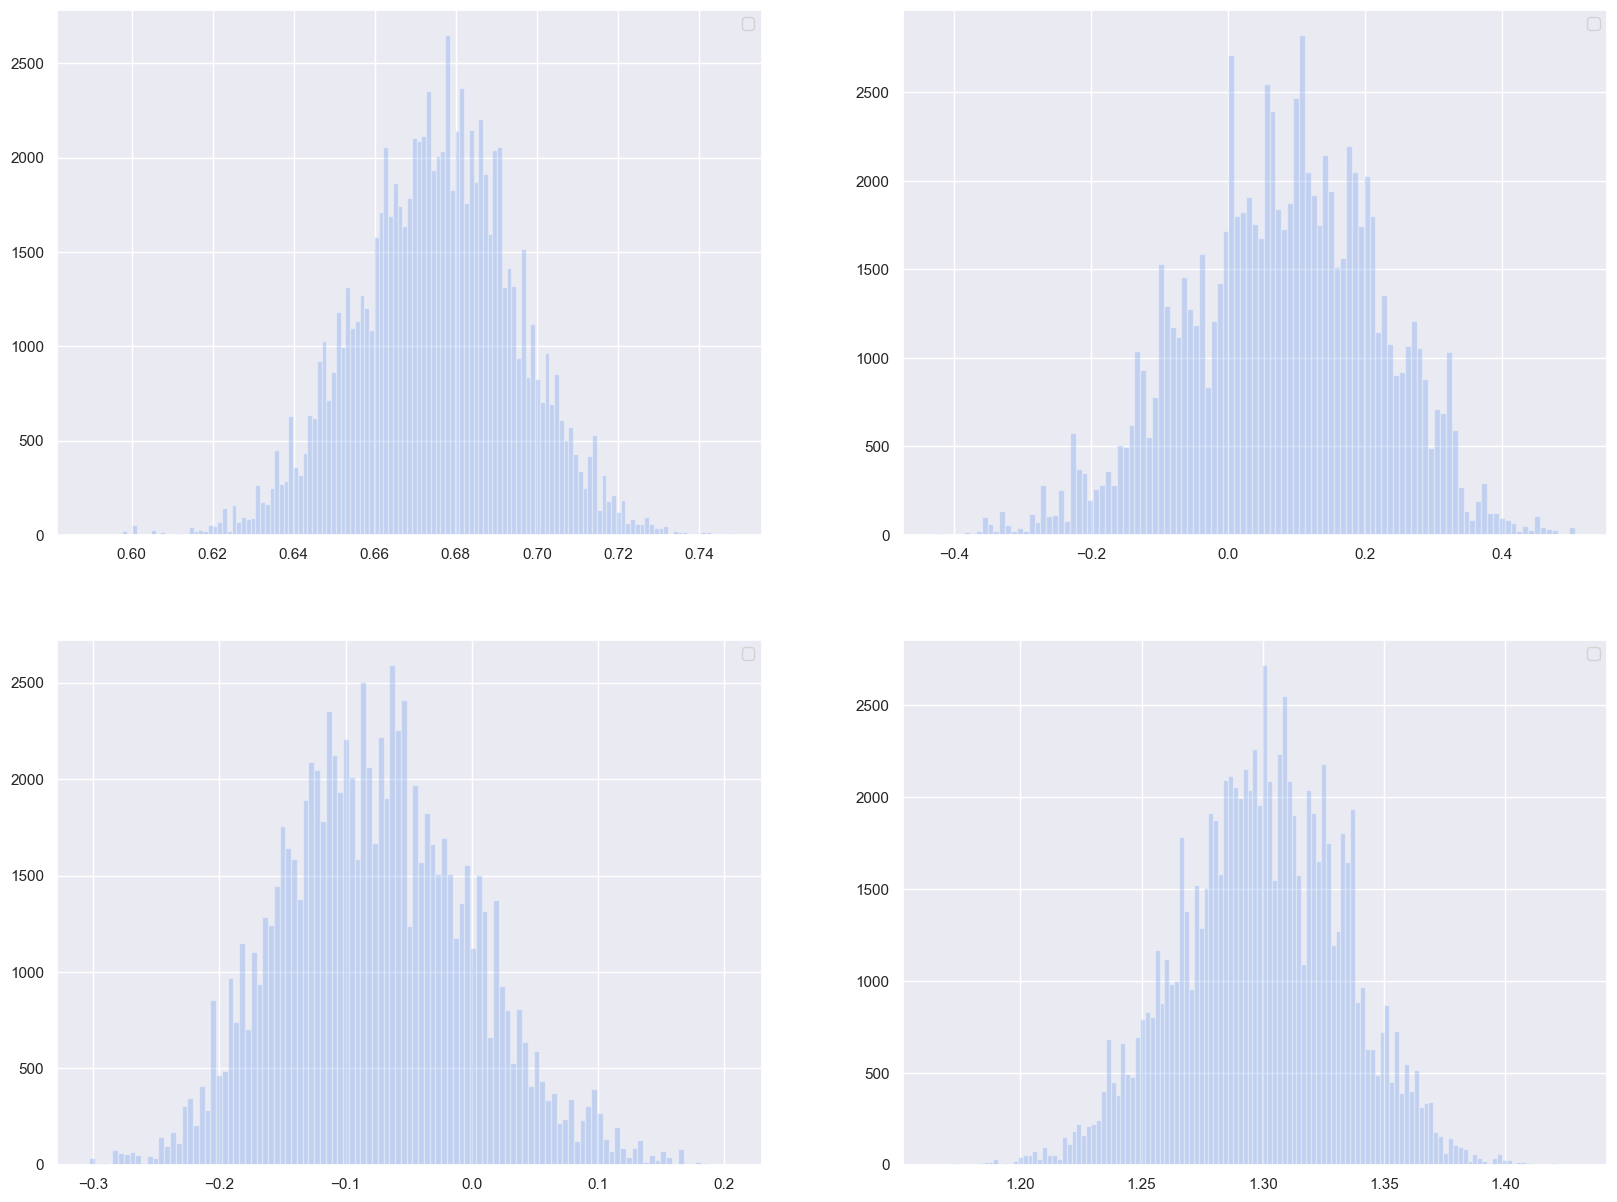

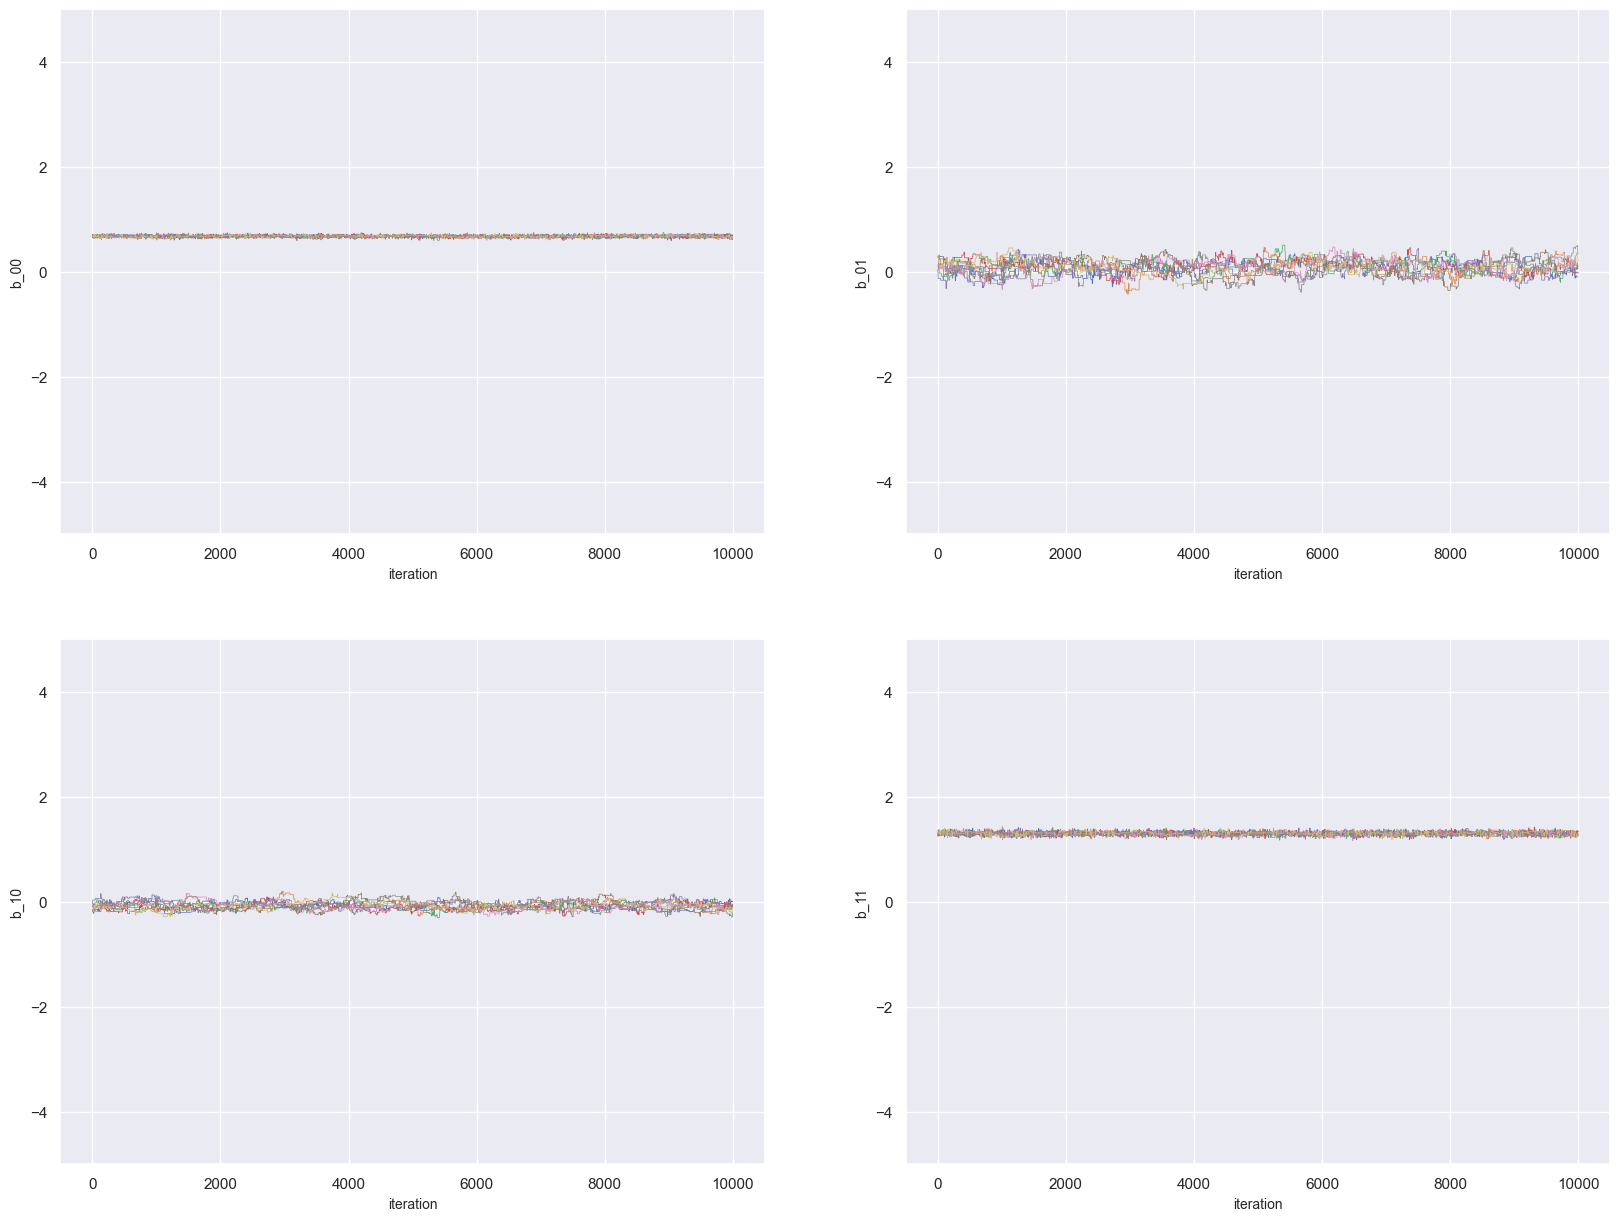

In [27]:
CASE = 'iv'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,11.122046,5.042693,11.823812,5.037861,11.800232,5.038372,10.756135,5.045925


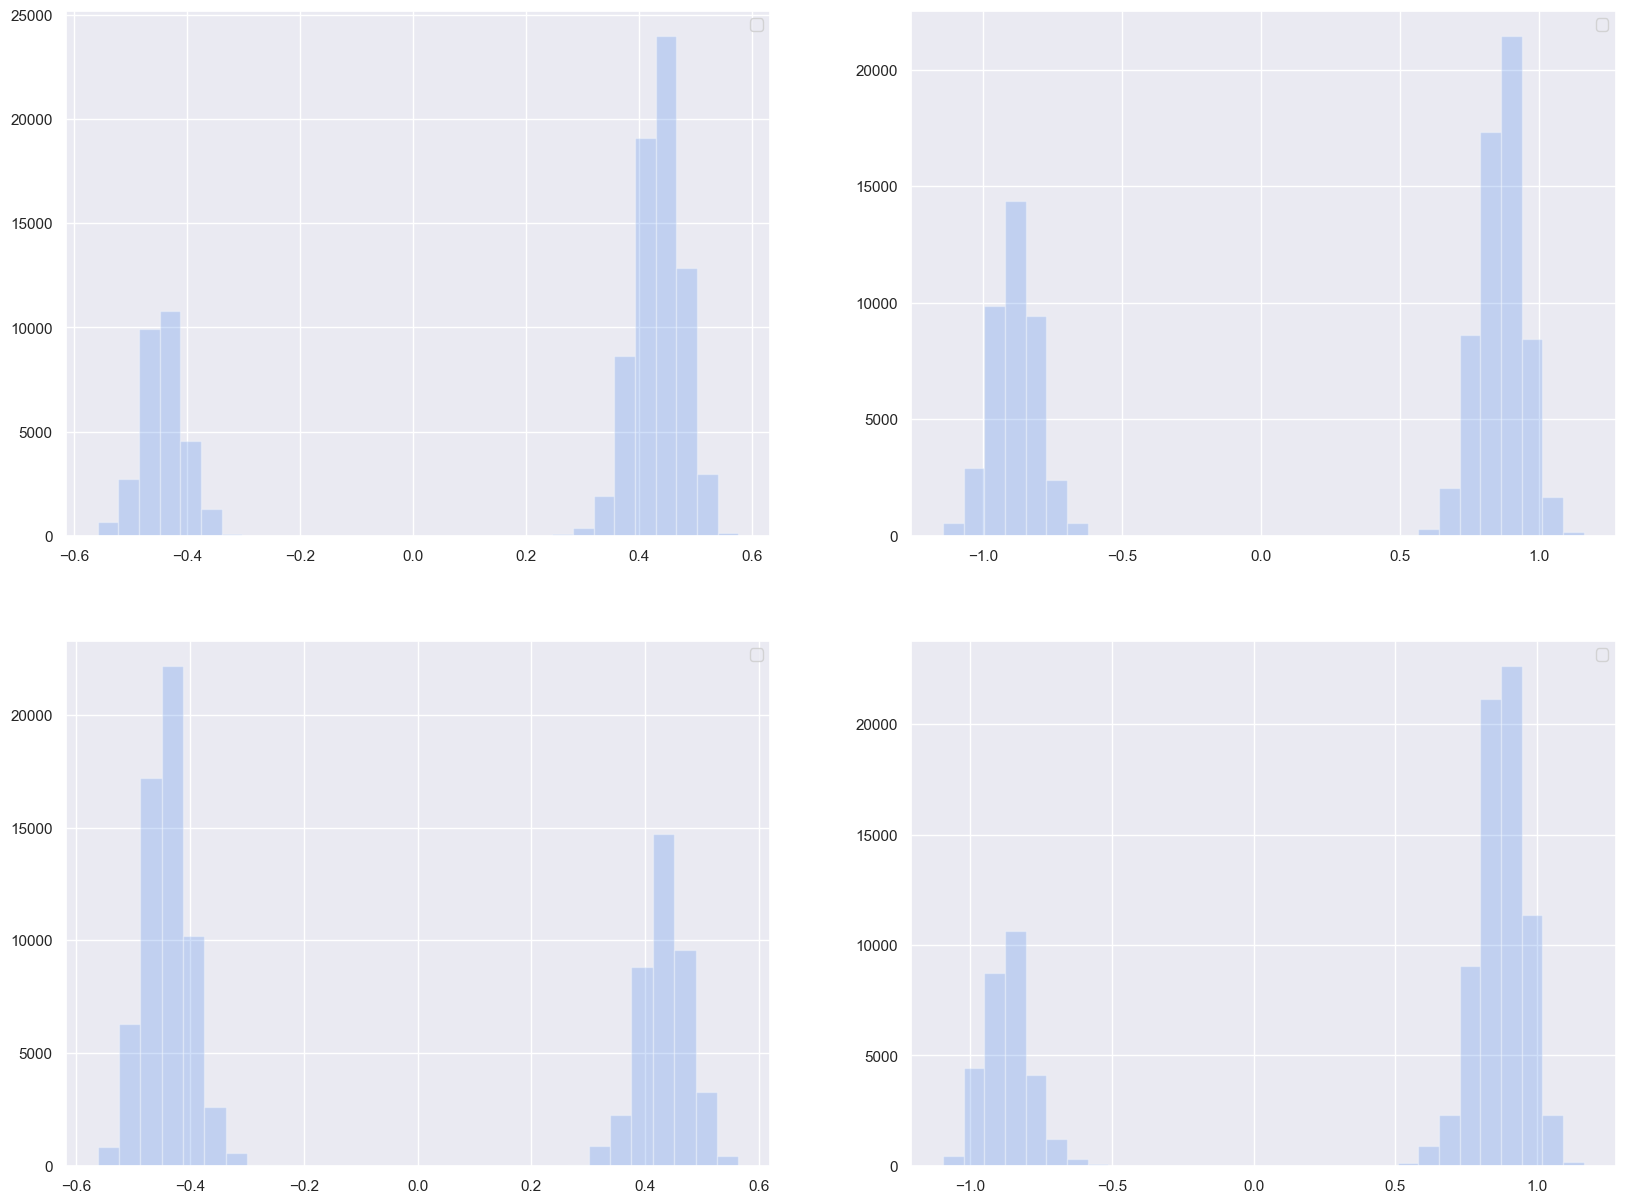

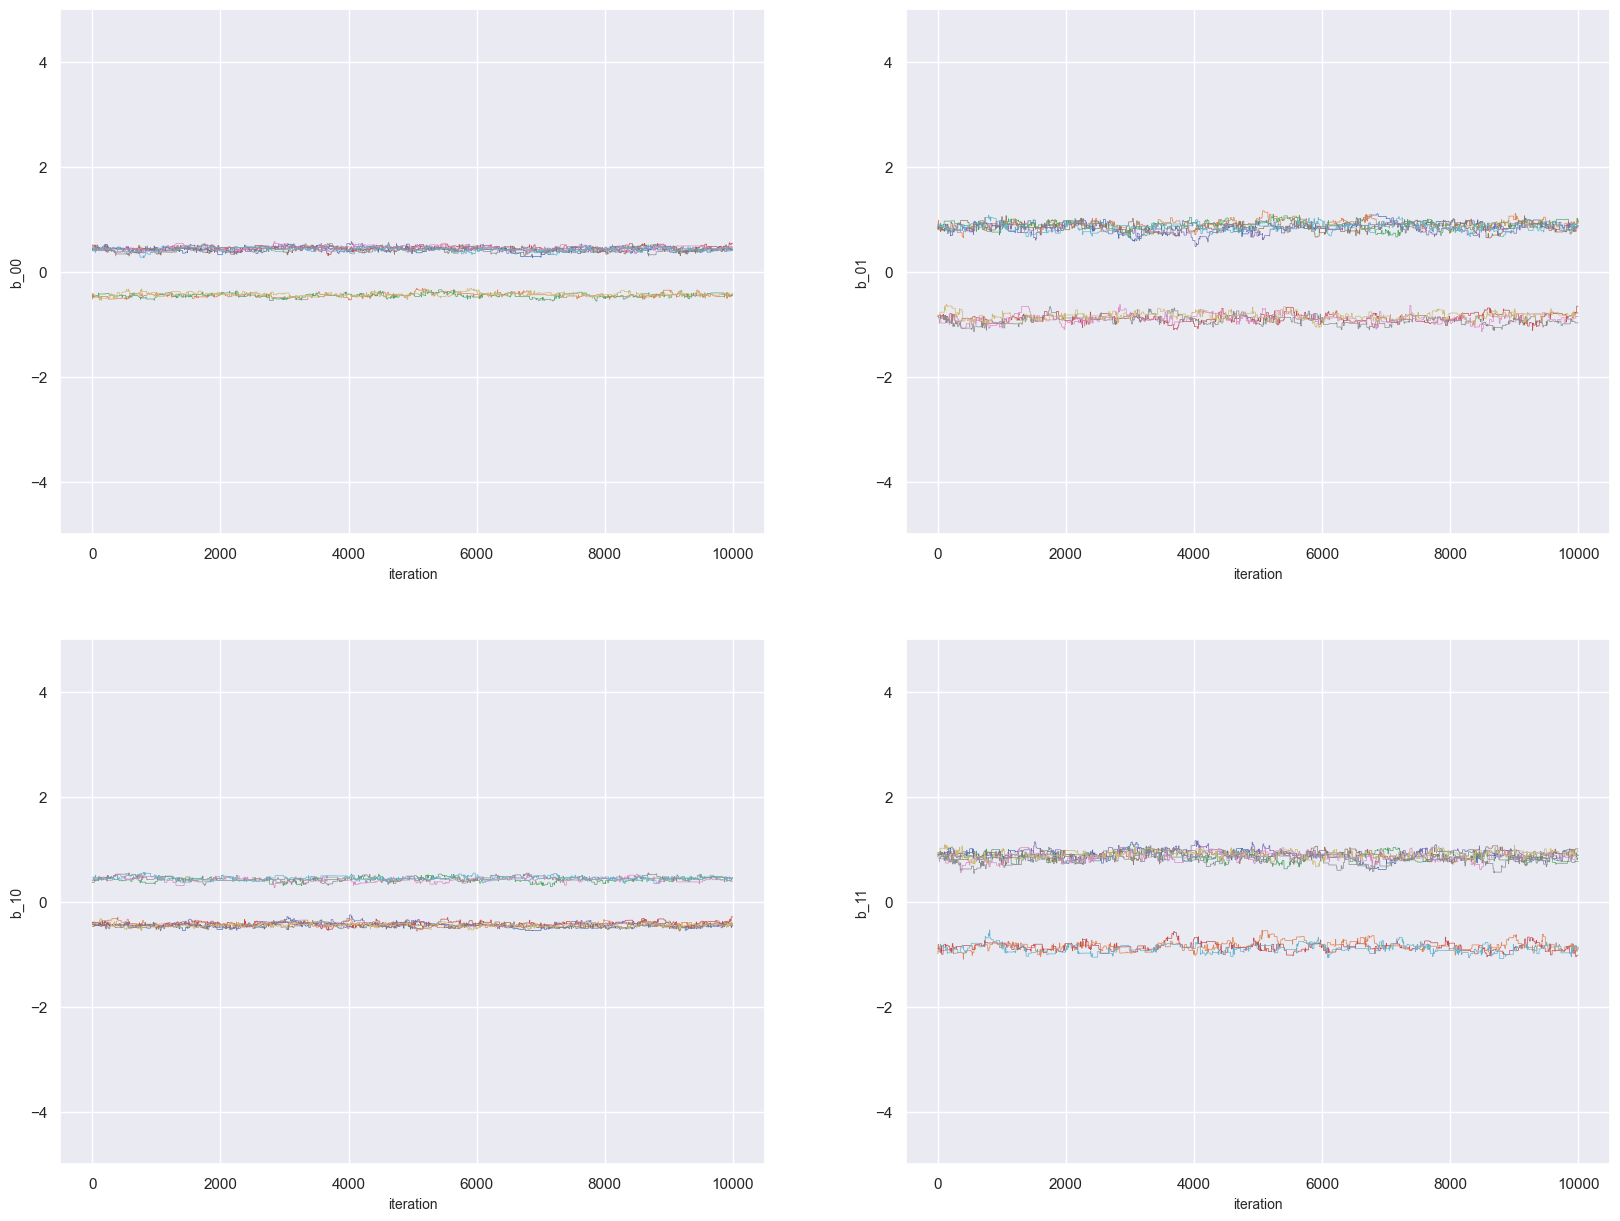

In [28]:
CASE = 'v'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,11.646527,5.039435,12.217129,5.035928,12.219265,5.035635,11.243265,5.042185


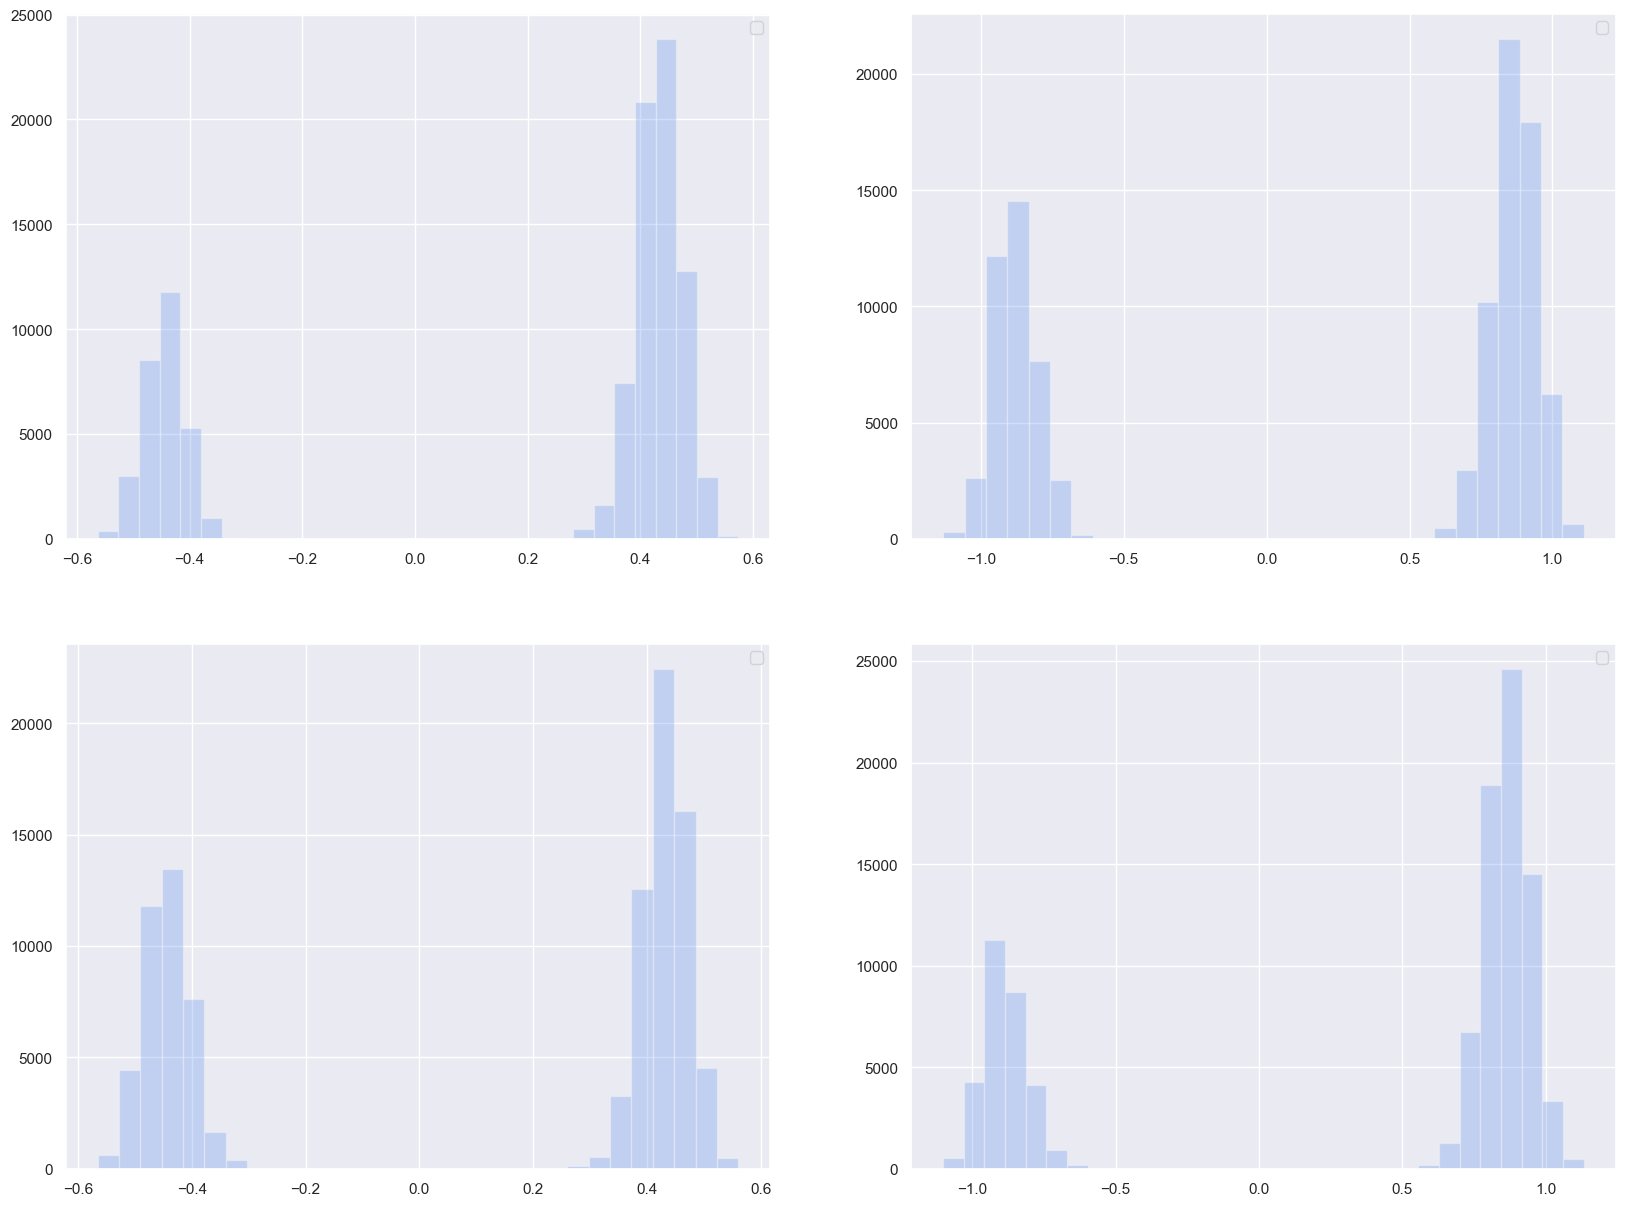

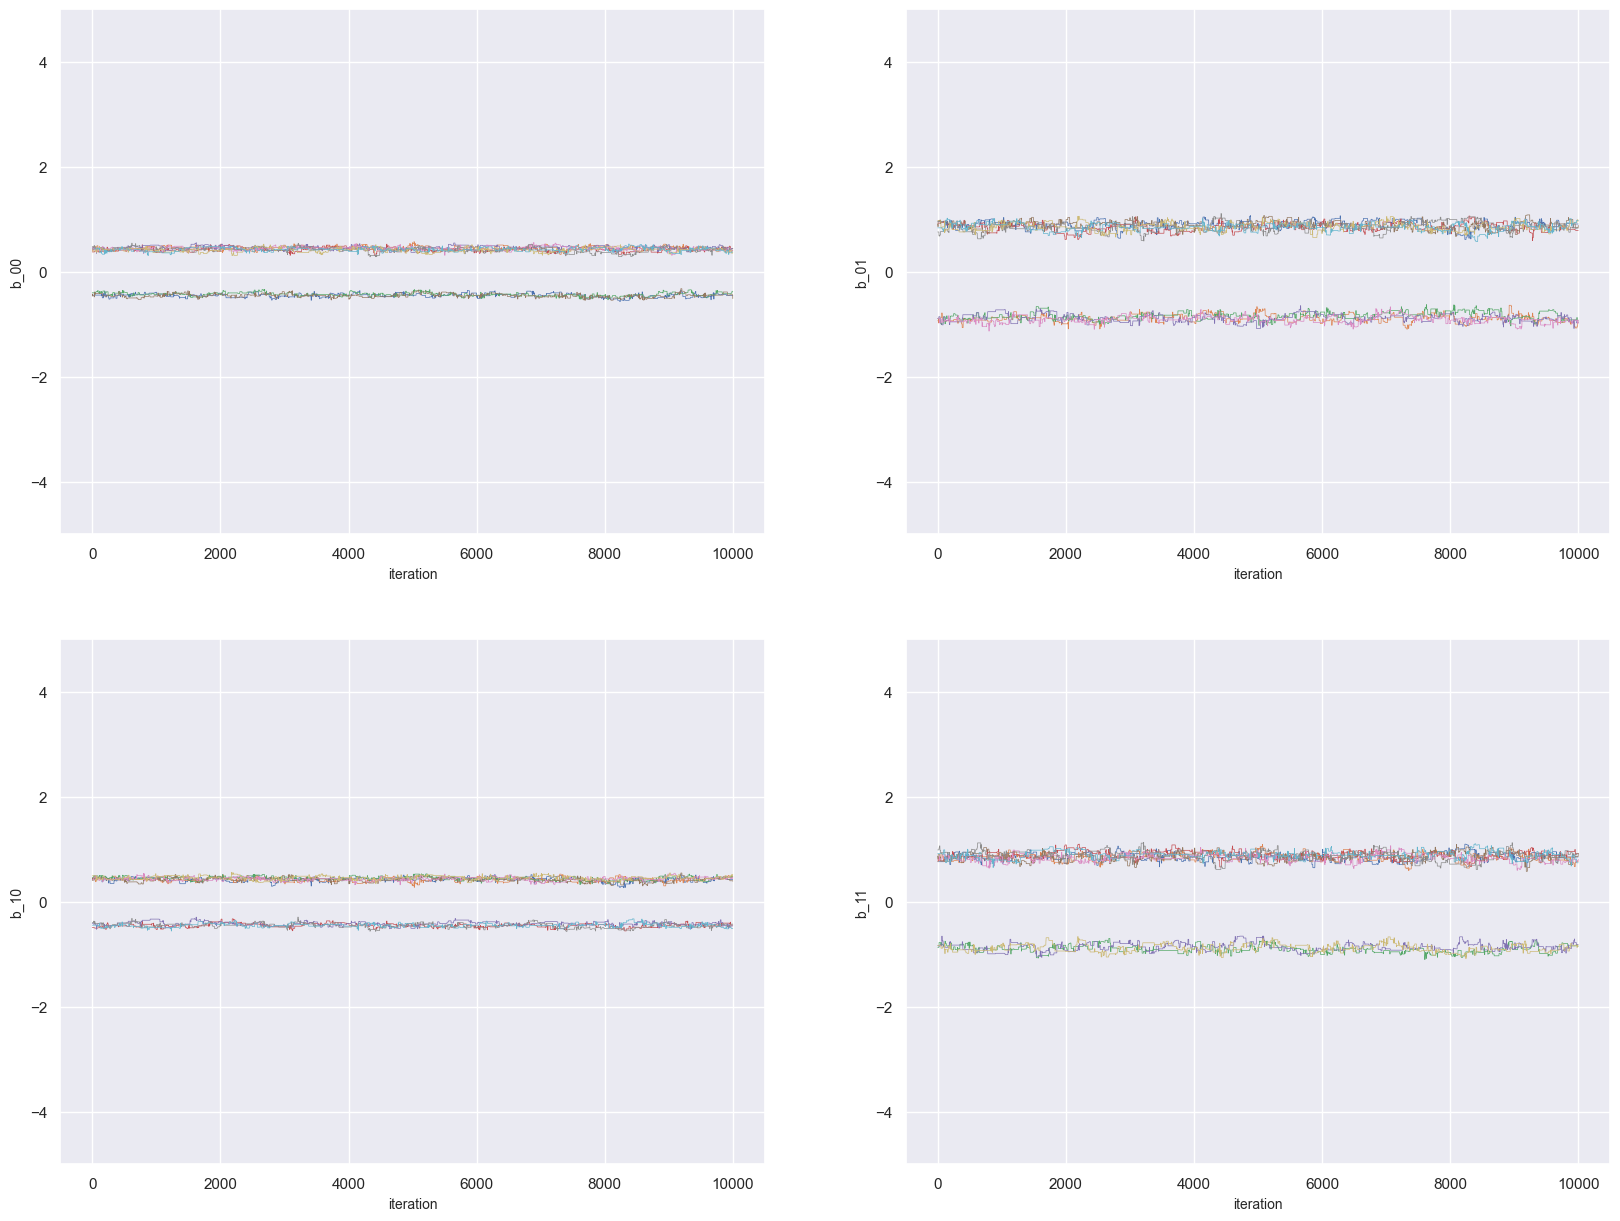

In [29]:
CASE = 'vi'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


Cadeias retidas: 9
R-hat convergiu? False


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,14.211872,5.02615,1.871199,7.176827,16.927921,5.018776,3.462049,5.488716


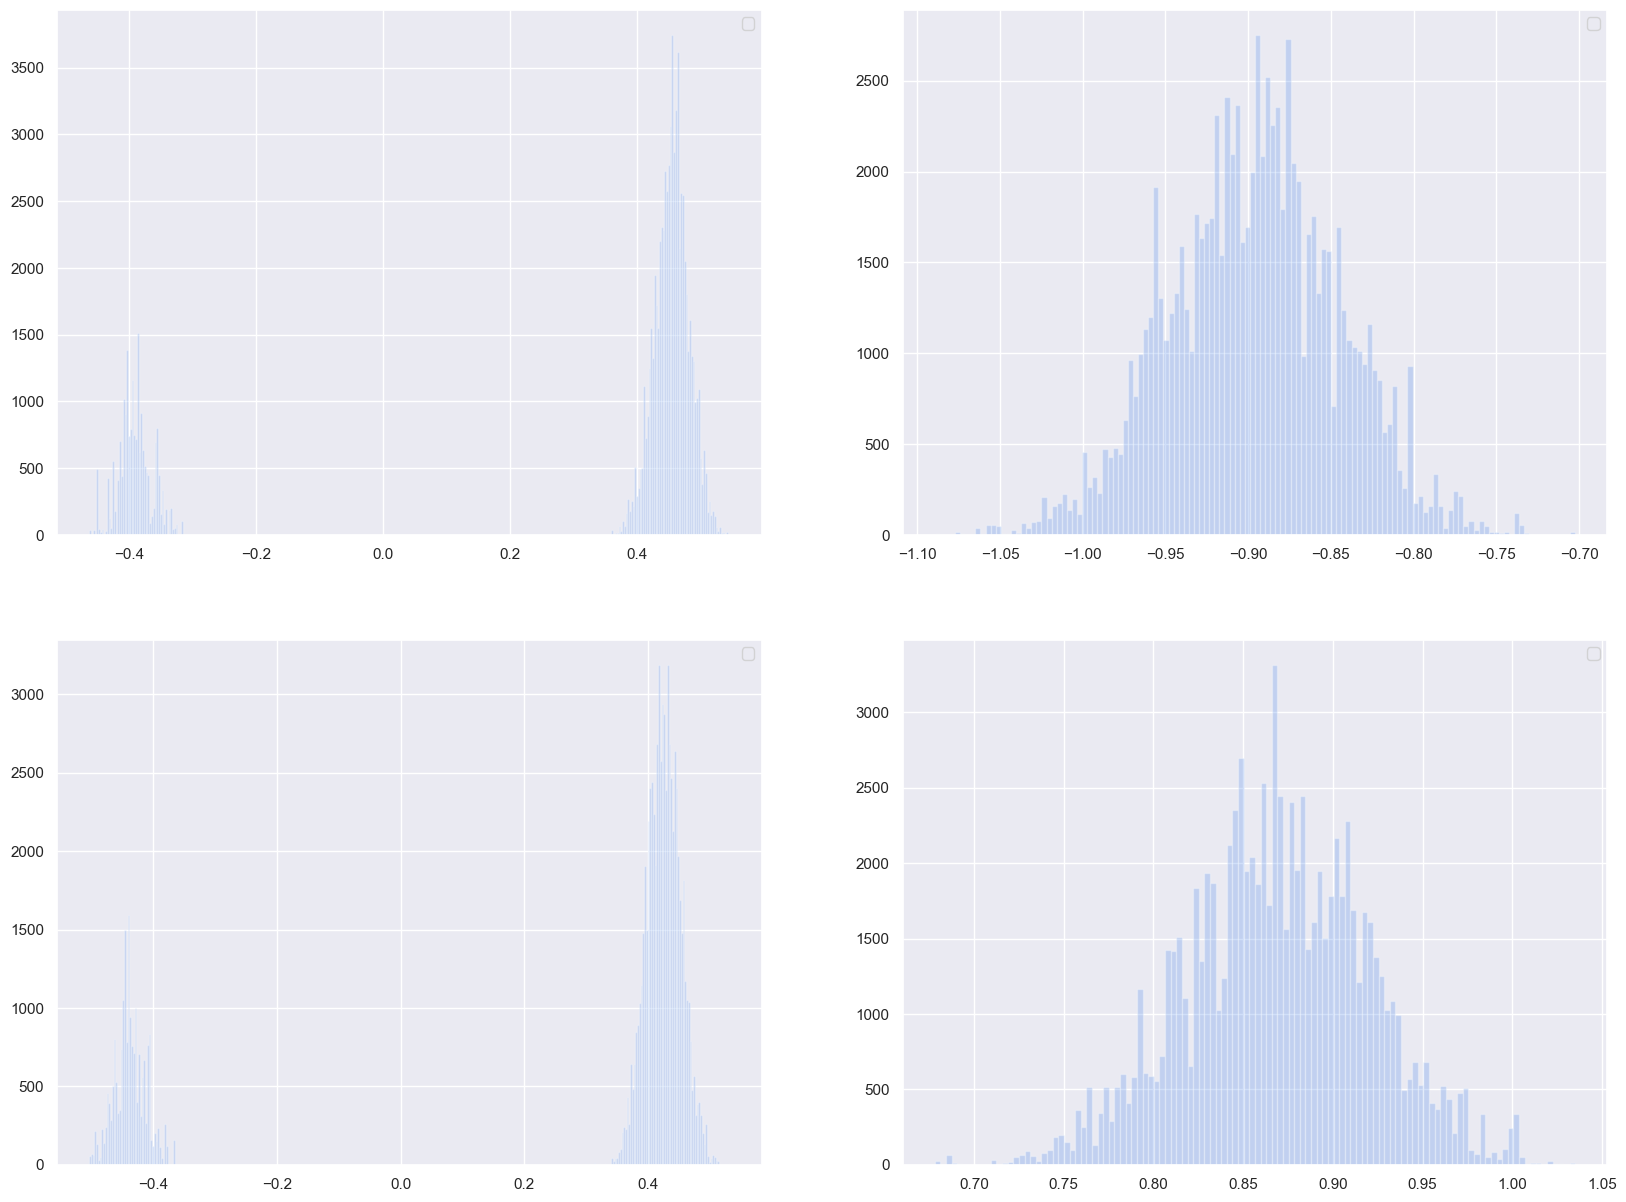

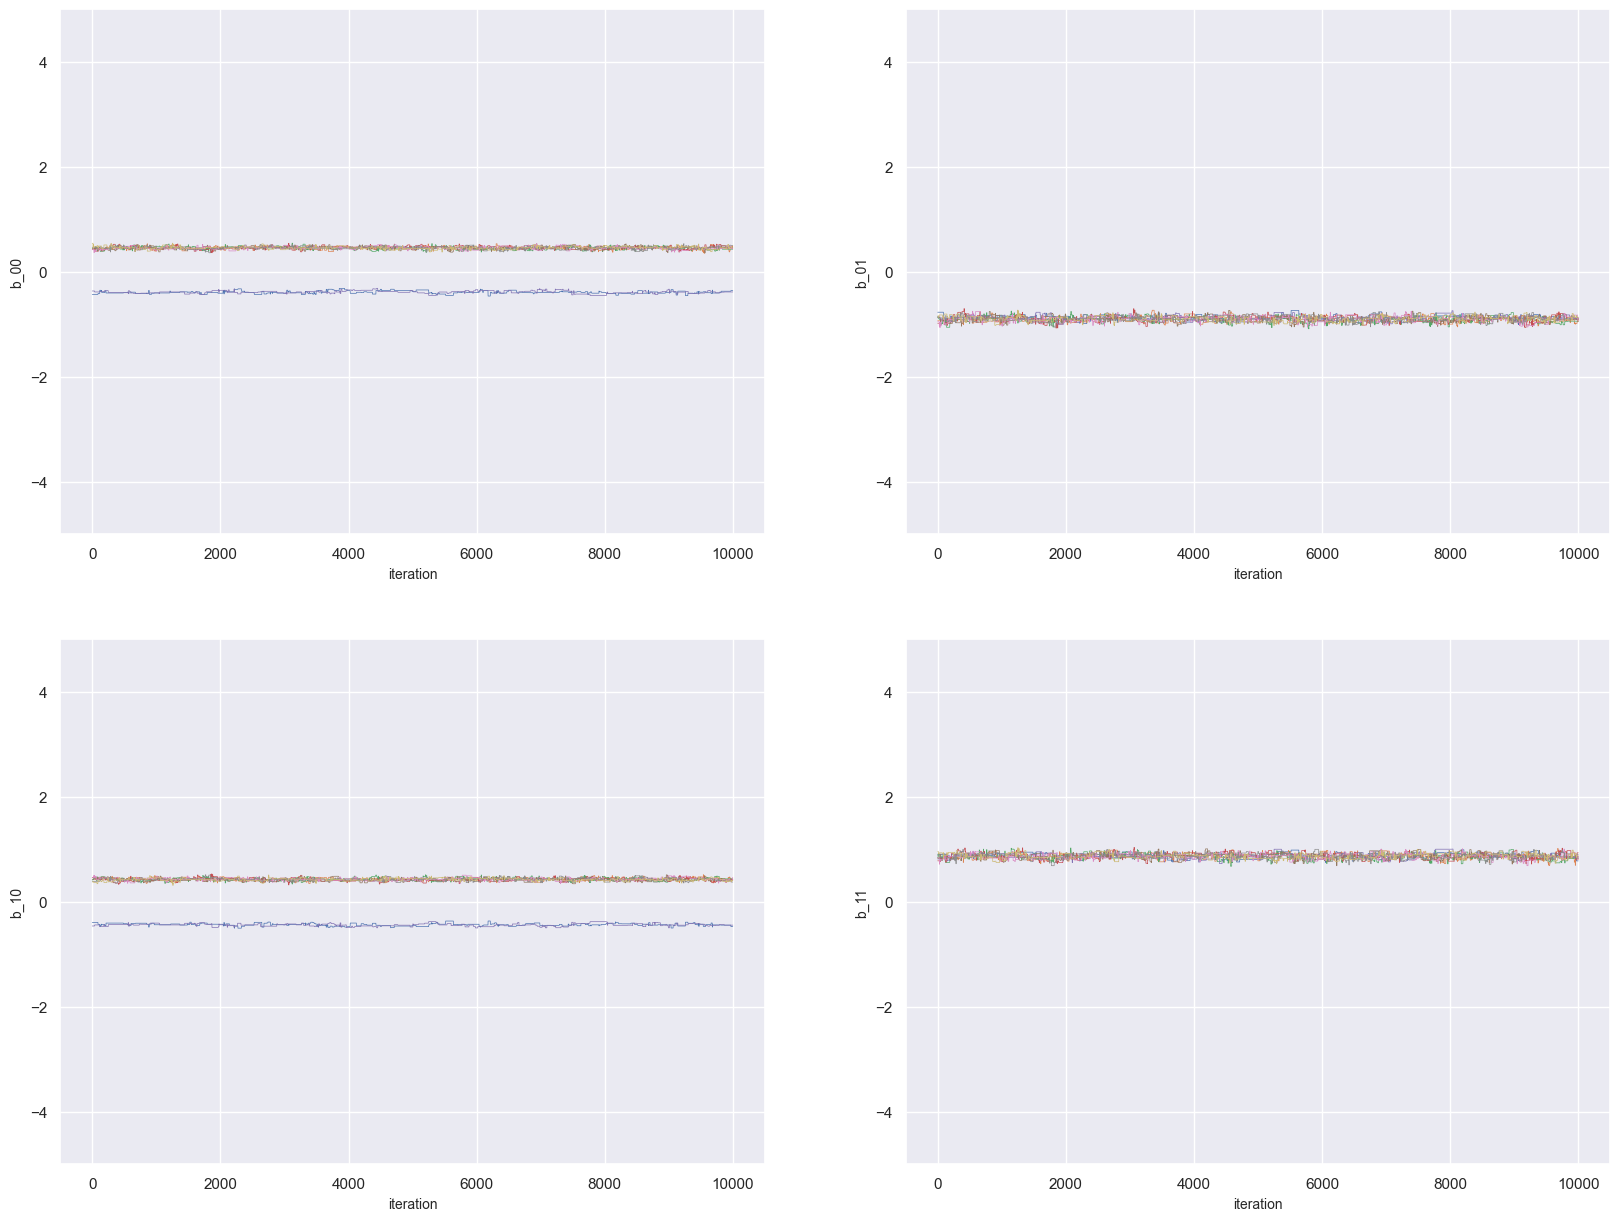

In [30]:
CASE = 'vii'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Cadeias retidas: 7
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,26.730116,5.007498,1.703799,NaN,2.536602,6.029379,16.069574,NaN


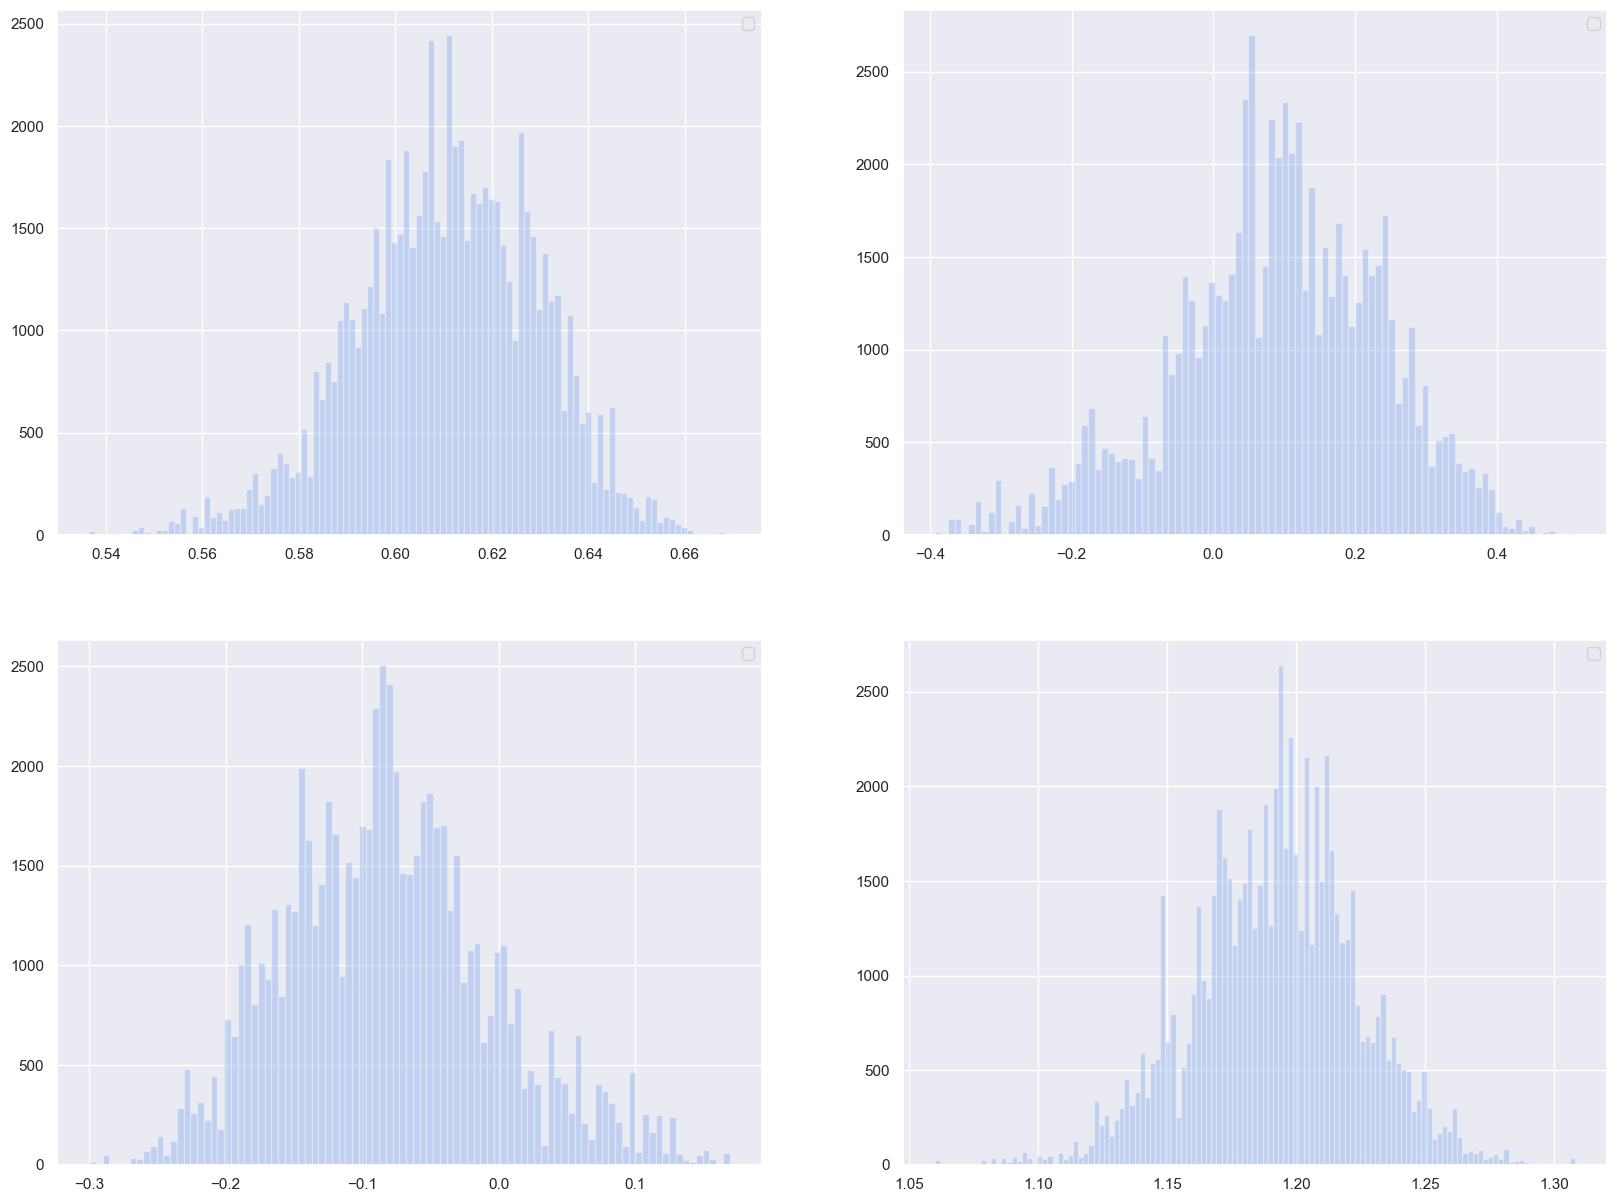

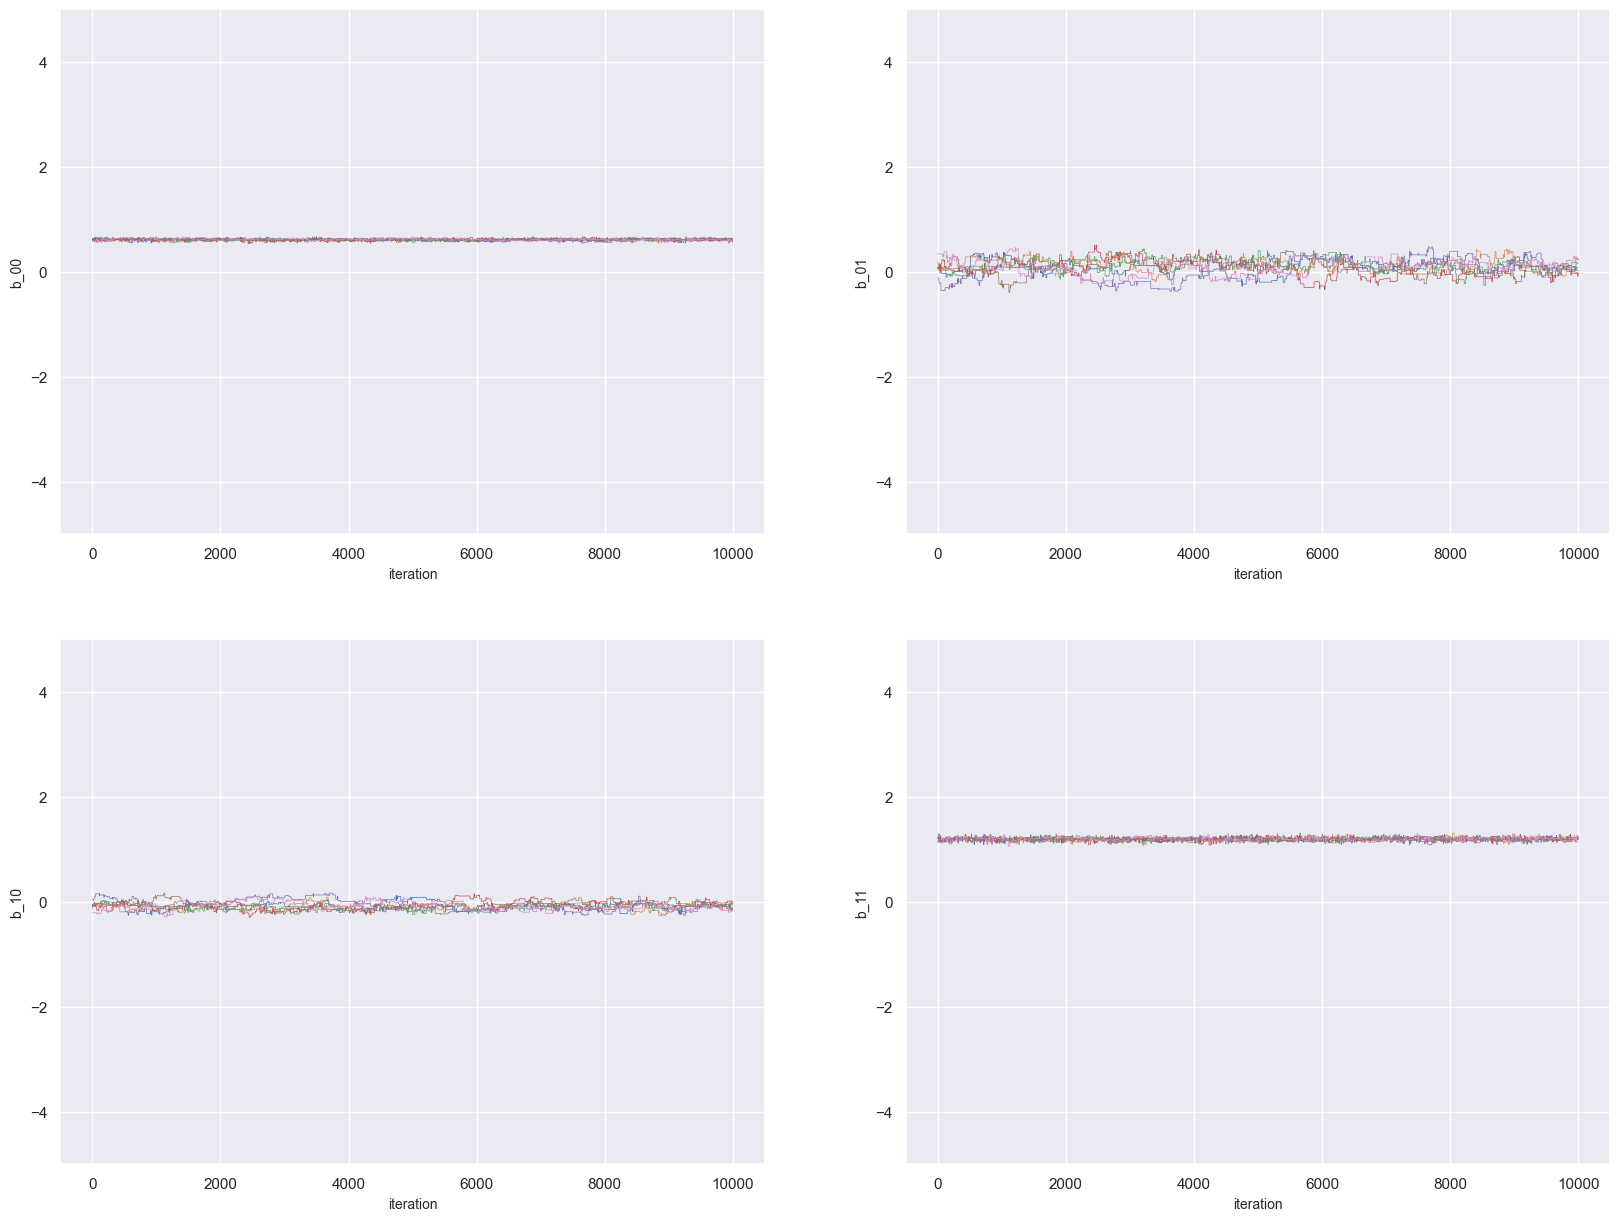

In [31]:
CASE = 'viii'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,11.522707,5.039999,11.231407,5.04293,10.168772,5.052452,10.648202,5.04691


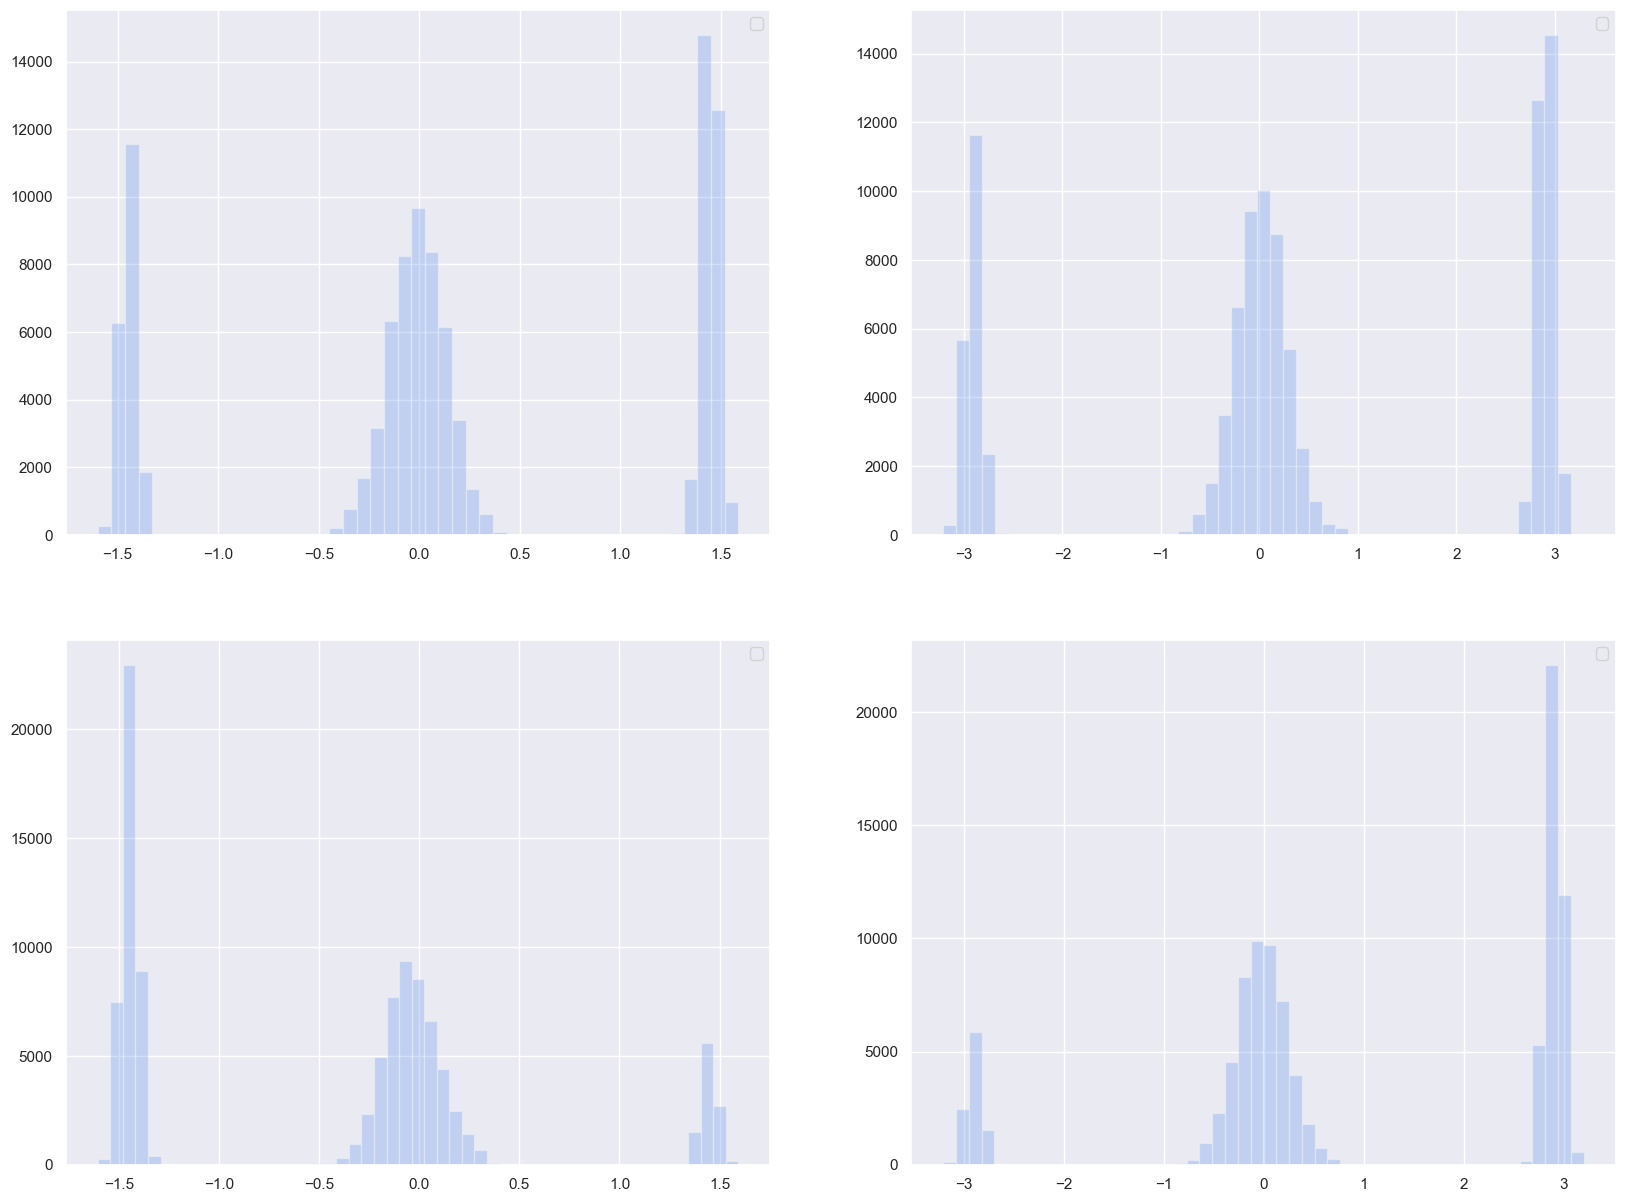

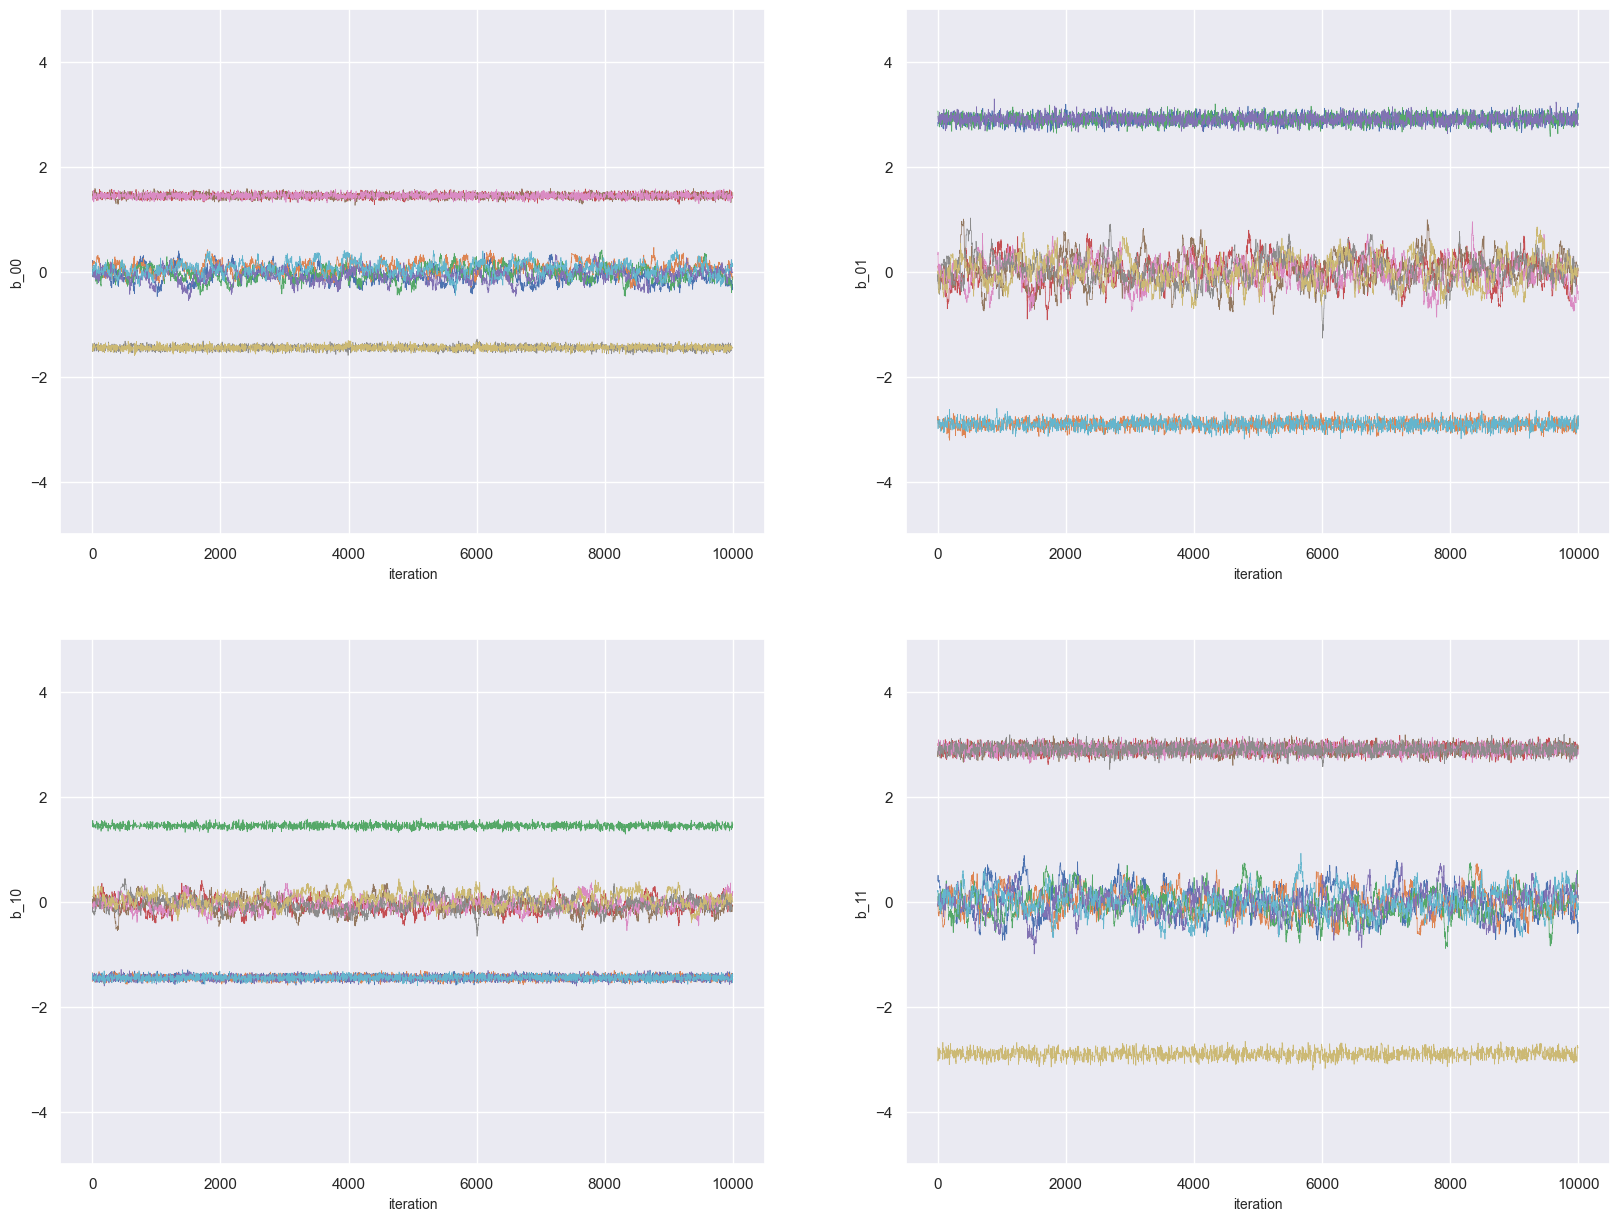

In [32]:
CASE = 'ix'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,16.063662,5.020852,6.76401,5.11768,7.910896,5.085249,16.16003,5.020675


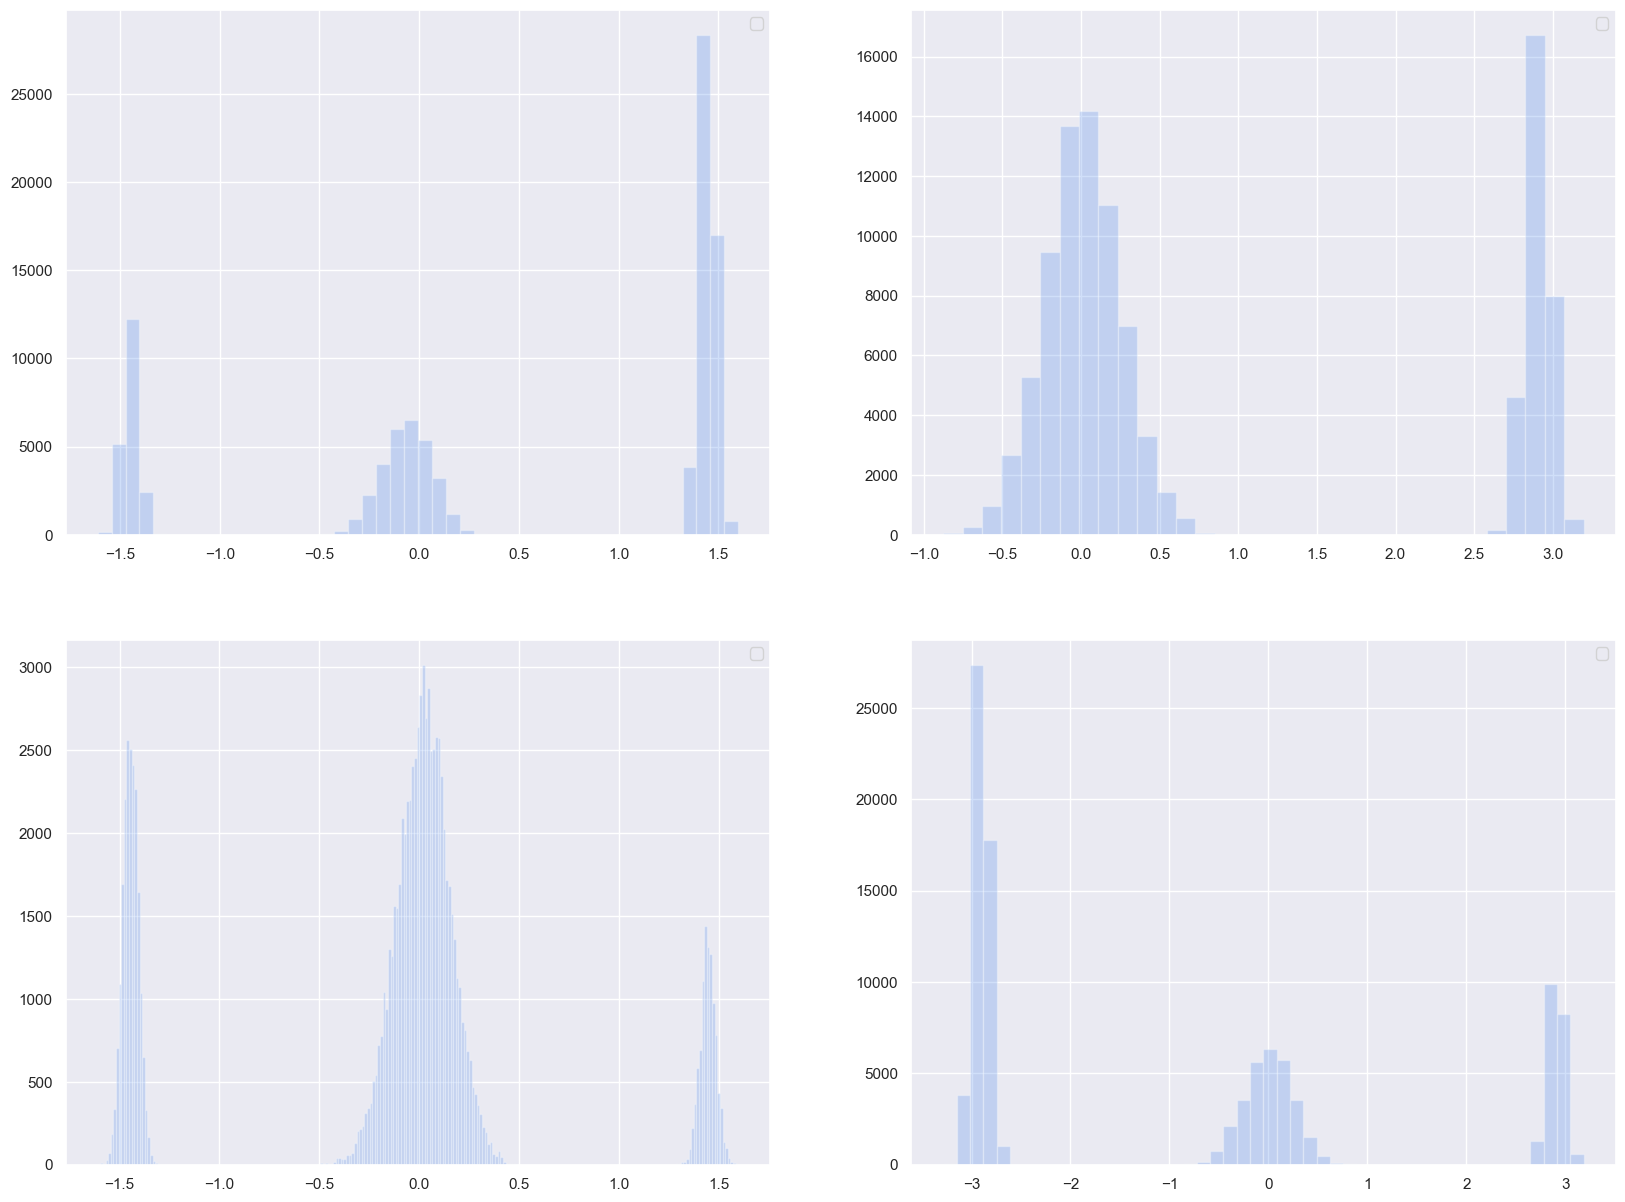

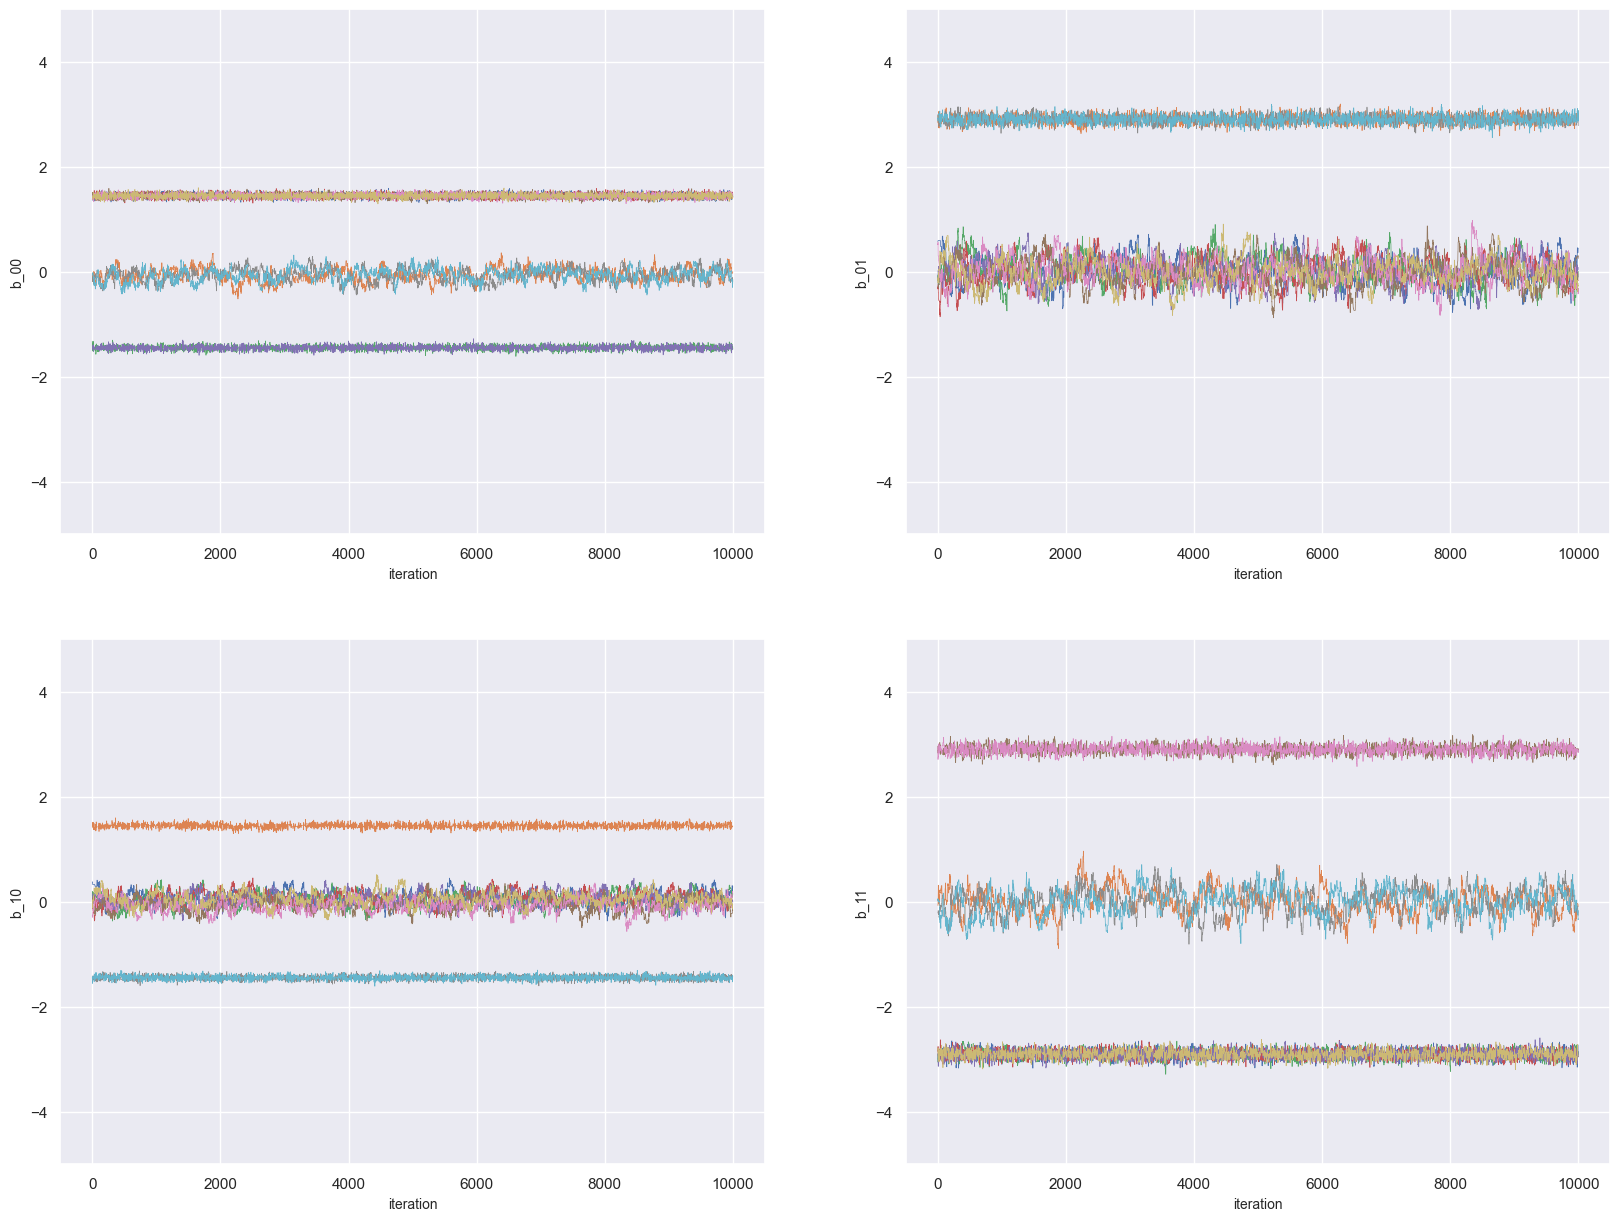

In [33]:
CASE = 'x'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Cadeias retidas: 8
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,5.221501,5.198306,2.478062,6.015743,10.789611,5.045283,6.116464,5.142188


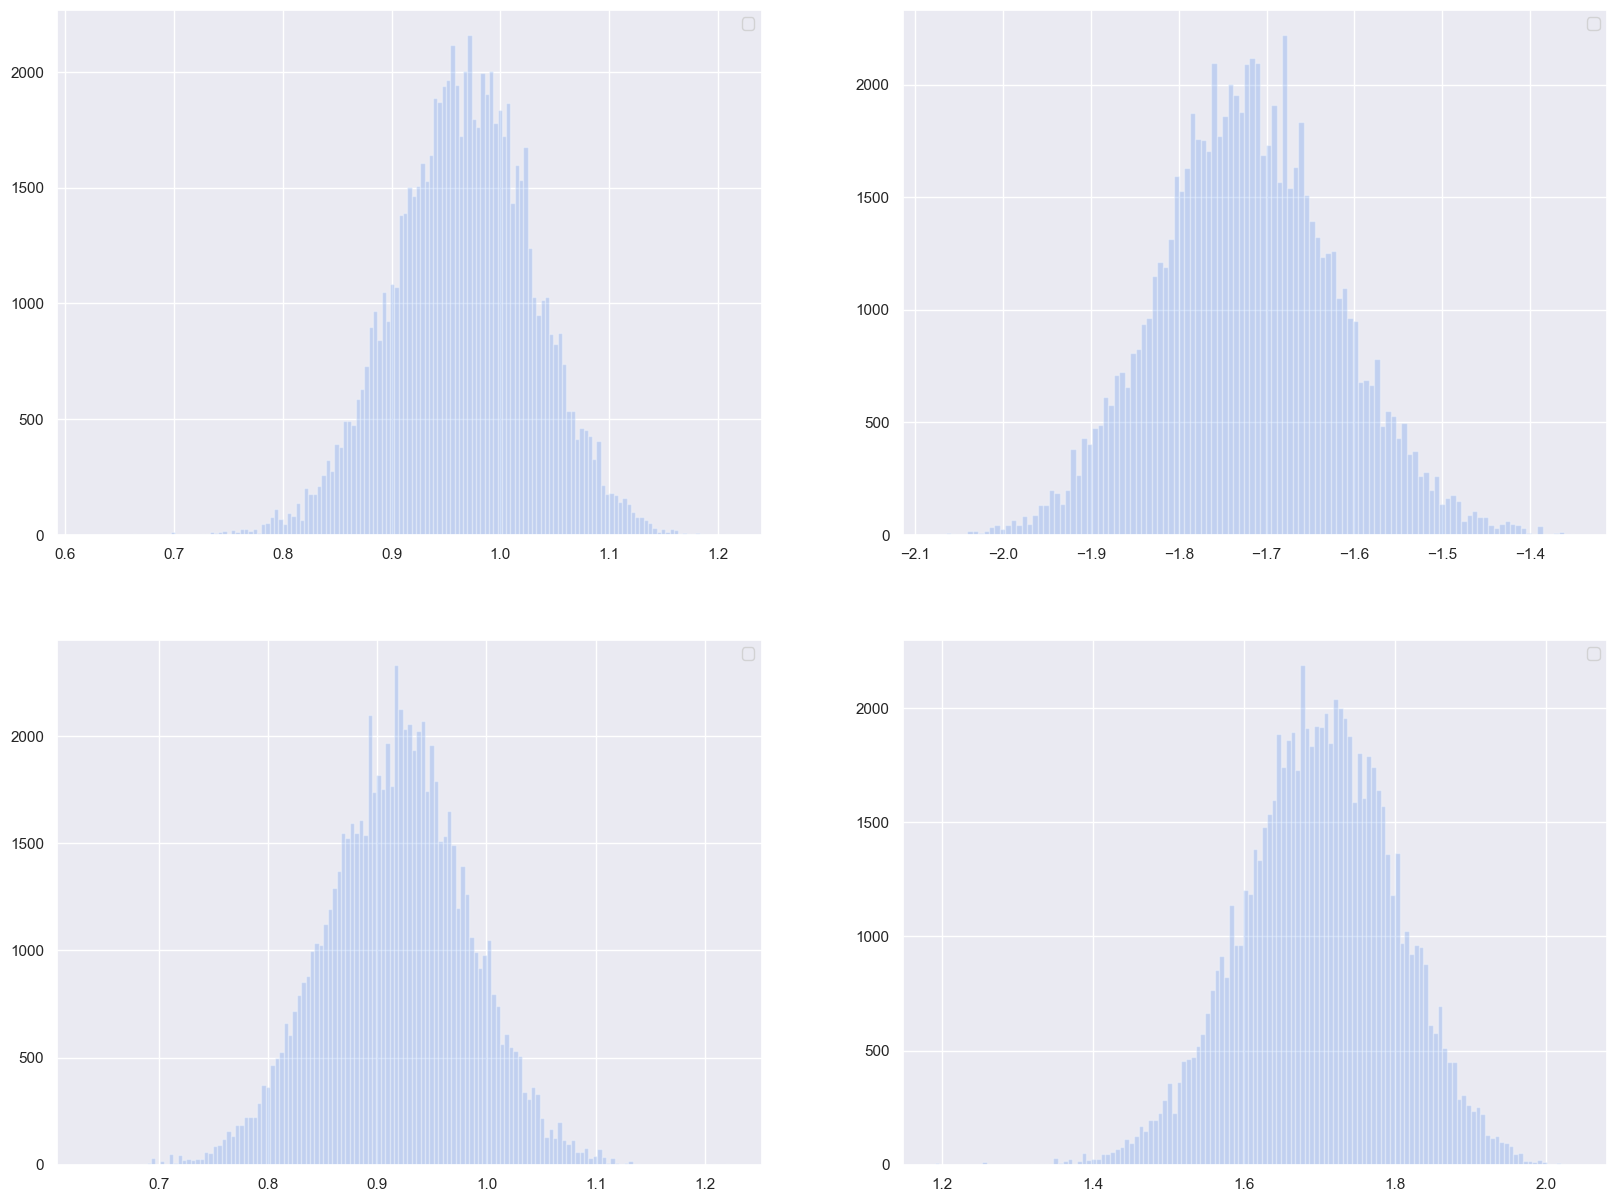

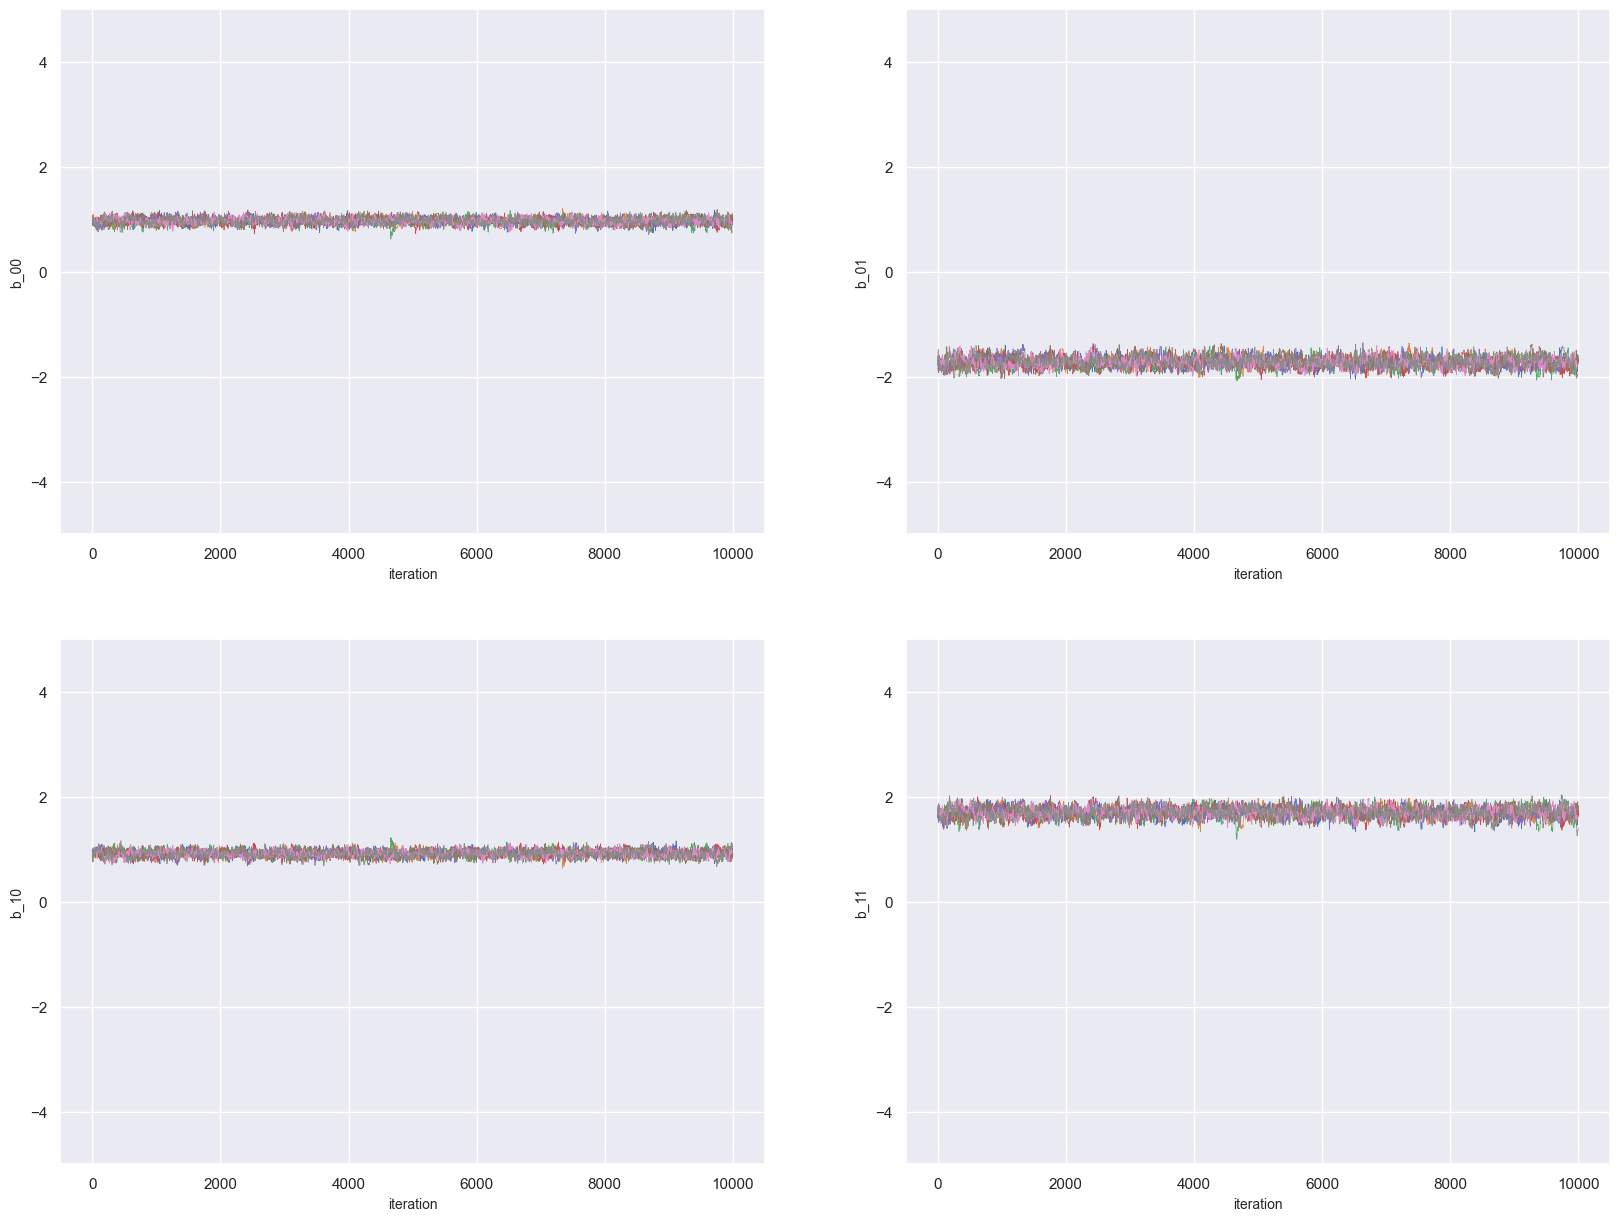

In [ ]:
CASE = 'xi'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
)

Cadeias retidas: 10
R-hat convergiu? False


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_37407/4271768138.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,21000,1.000783,5310.902567,1.004826,1137.759188,1.004026,1341.603724,1.001755,3817.649925


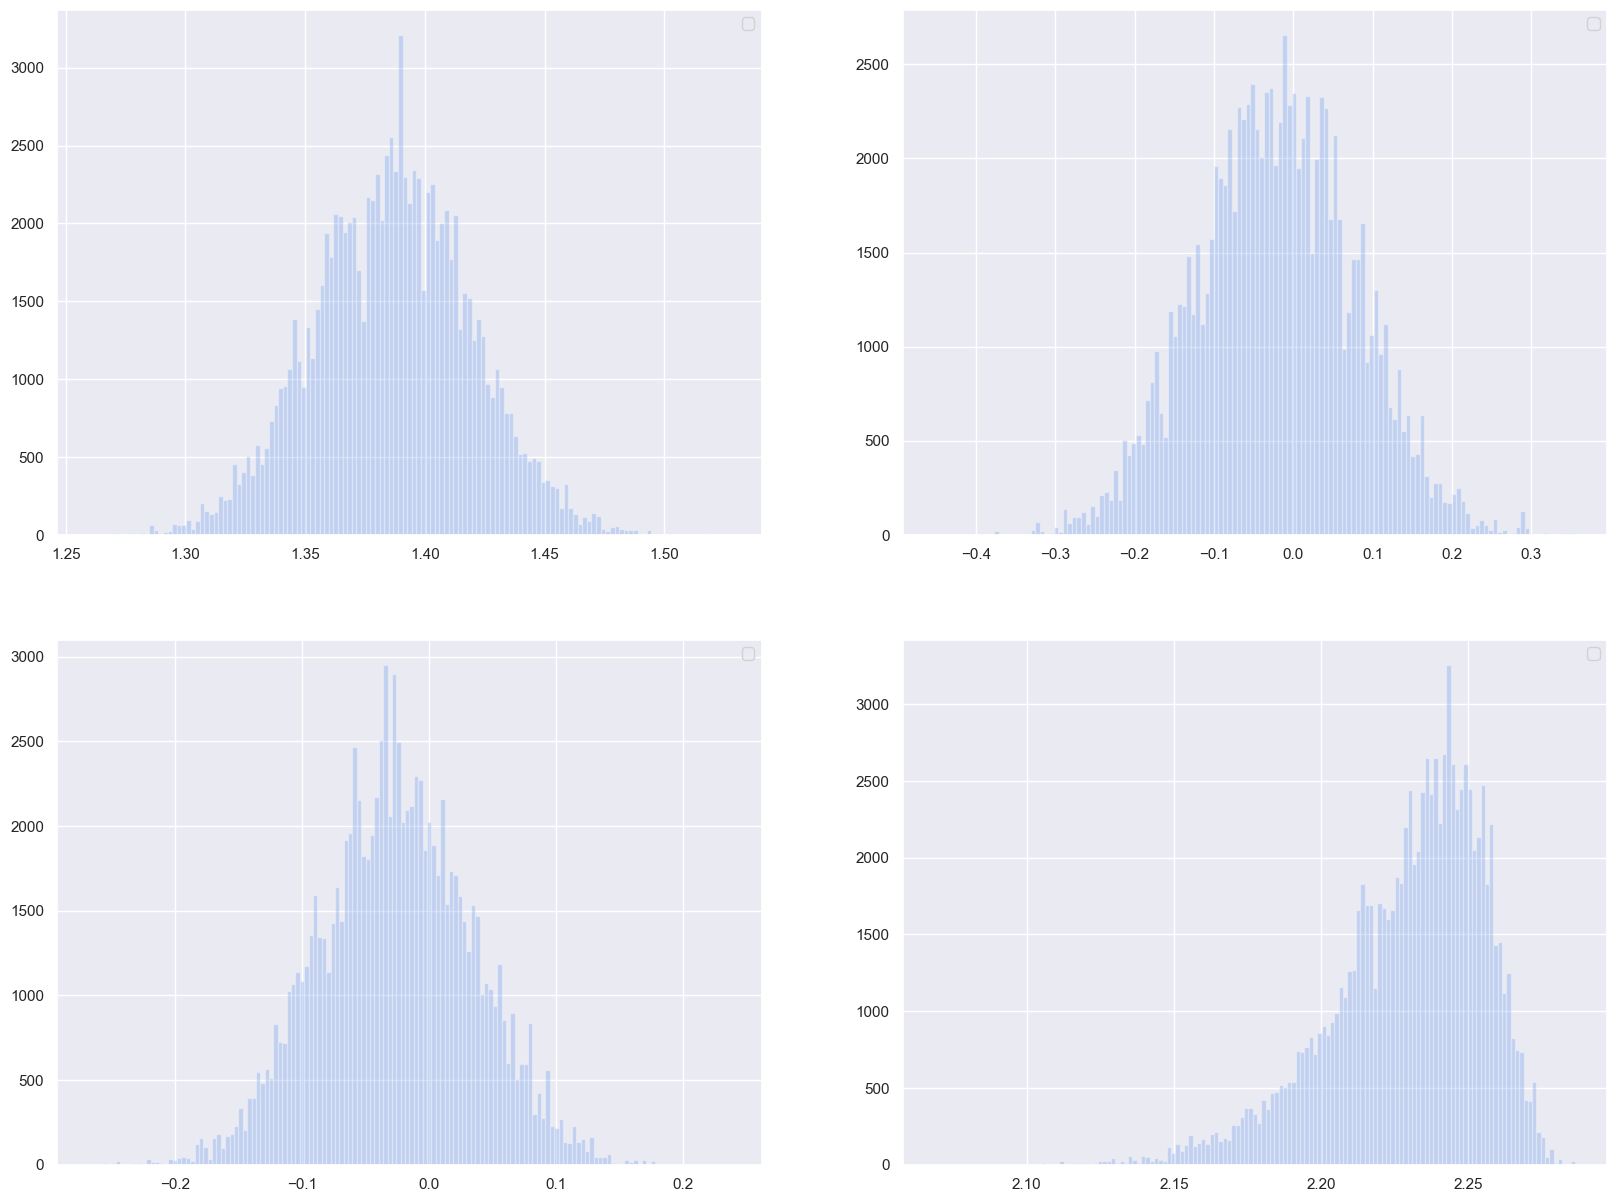

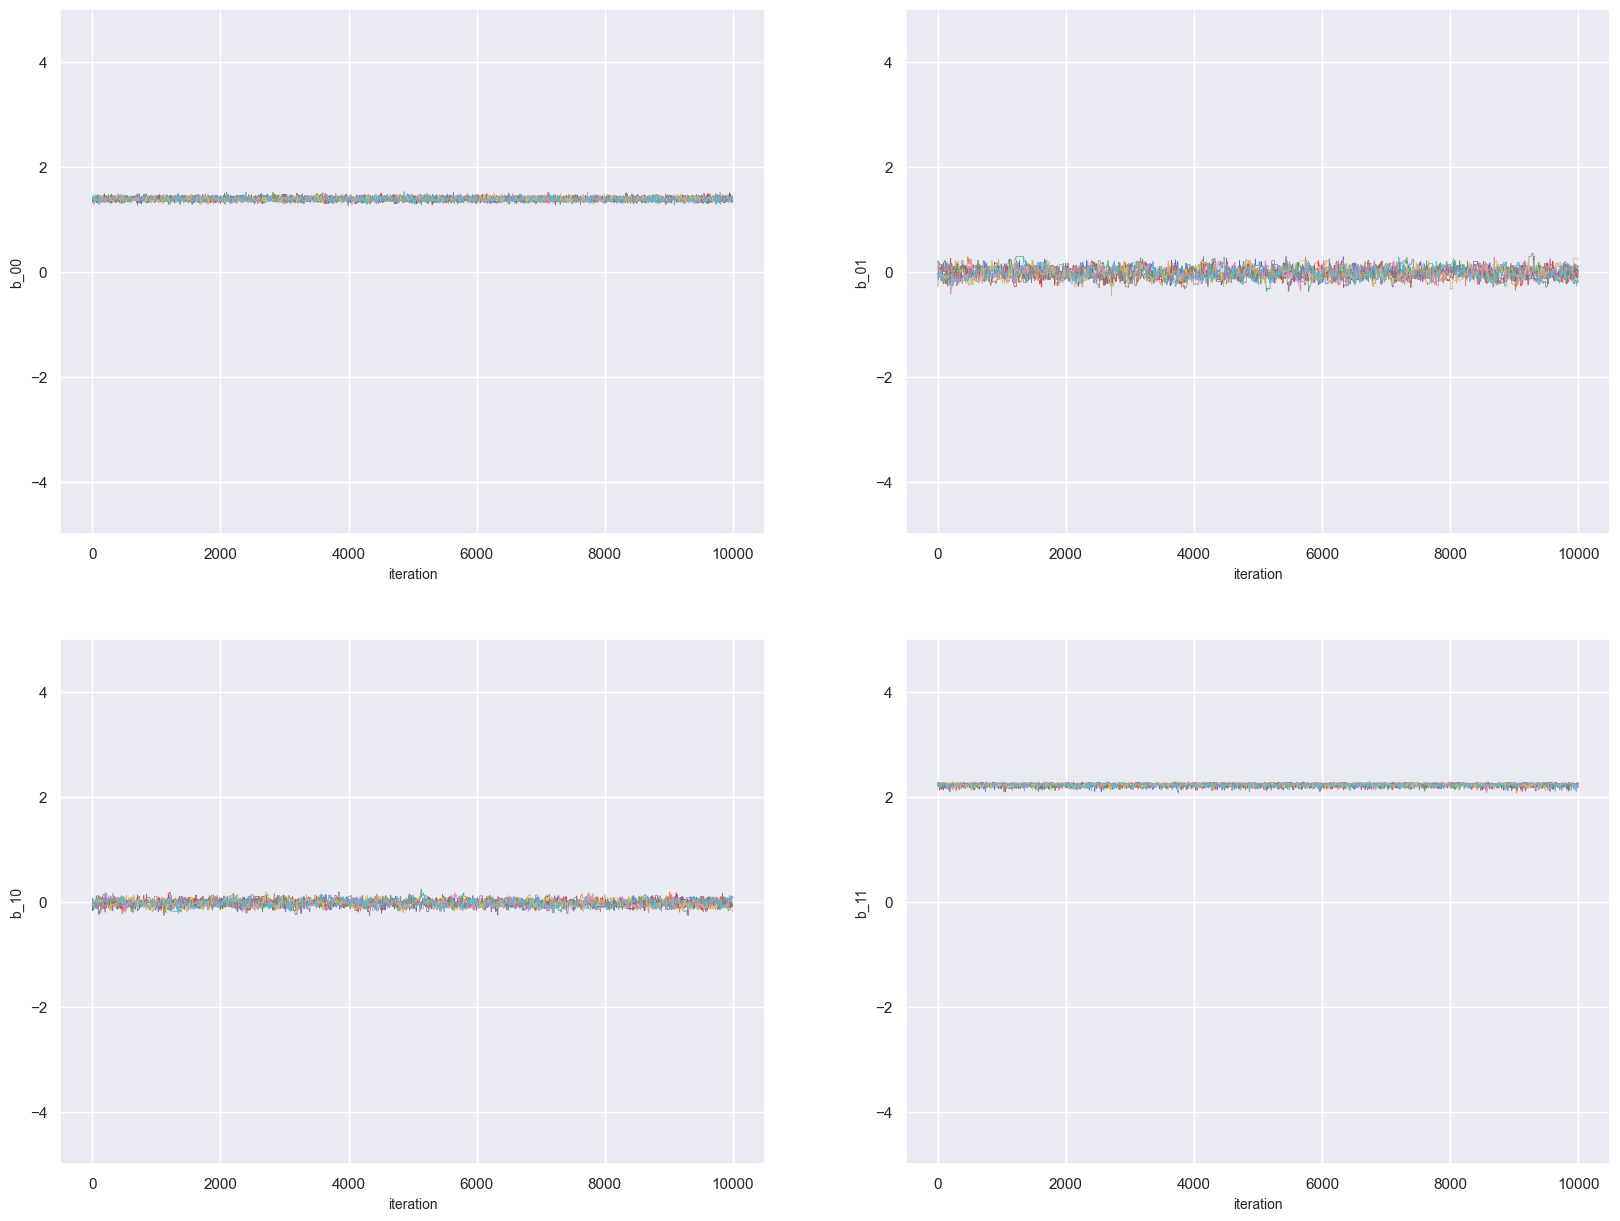

In [37]:
CASE = 'xii'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

In [38]:
def get_PCA(
    case,
    parser,
    B,
    bins=100,
    discard_zero_var=True
):
    

    SAMPLES_PER_CHAIN = parser.execution_config['mcmc']['n_samples']//parser.execution_config['mcmc']['parallel_chains']

    samples_chains = [
        chain_samples[-SAMPLES_PER_CHAIN:,:,:] for chain_samples in parser.parsed_results[case]['mmse']['object'][0].samples
    ]

    discard_chain = []
    for c_samples in samples_chains:
        discard=True
        if discard_zero_var:
            for i,j in np.ndindex(B.shape):
                if np.var(c_samples[:1000,i,j])>1E-20:
                    discard=False

        discard_chain.append(discard)
    
    retained_chains_samples = [
        c_samples for c_samples, discard in zip(
            samples_chains, discard_chain
        ) if not discard
    ]    
    samples = np.concatenate(
        retained_chains_samples,
        axis=0
    )

    flattened_samples = np.array([
        np.ravel(s) for s in samples
    ])
    
    pca = PCA(
        n_components=2,
        svd_solver='full'
    )
    reduced_samples = pca.fit_transform(flattened_samples)
    
    print('Componentes:\n{}'.format(pca.components_))
    print('Fração de variànciaz explicada: {}'.format(np.cumsum(pca.explained_variance_ratio_)))

    fig, ax = plt.subplots(
        nrows=1, ncols=1,
        figsize=(20,7)
    )

    ax.hist2d(
        reduced_samples[:,0],
        reduced_samples[:,-1],
        bins=bins
    )

    ax.set_xlabel('PC1', fontsize=15)
    ax.set_ylabel('PC2', fontsize=15)

    return pca
    

Componentes:
[[-0.30485526  0.47241437  0.13981871  0.81506974]
 [ 0.12432656  0.78940105  0.36925995 -0.47437954]]
Fração de variànciaz explicada: [0.4819413  0.88312256]


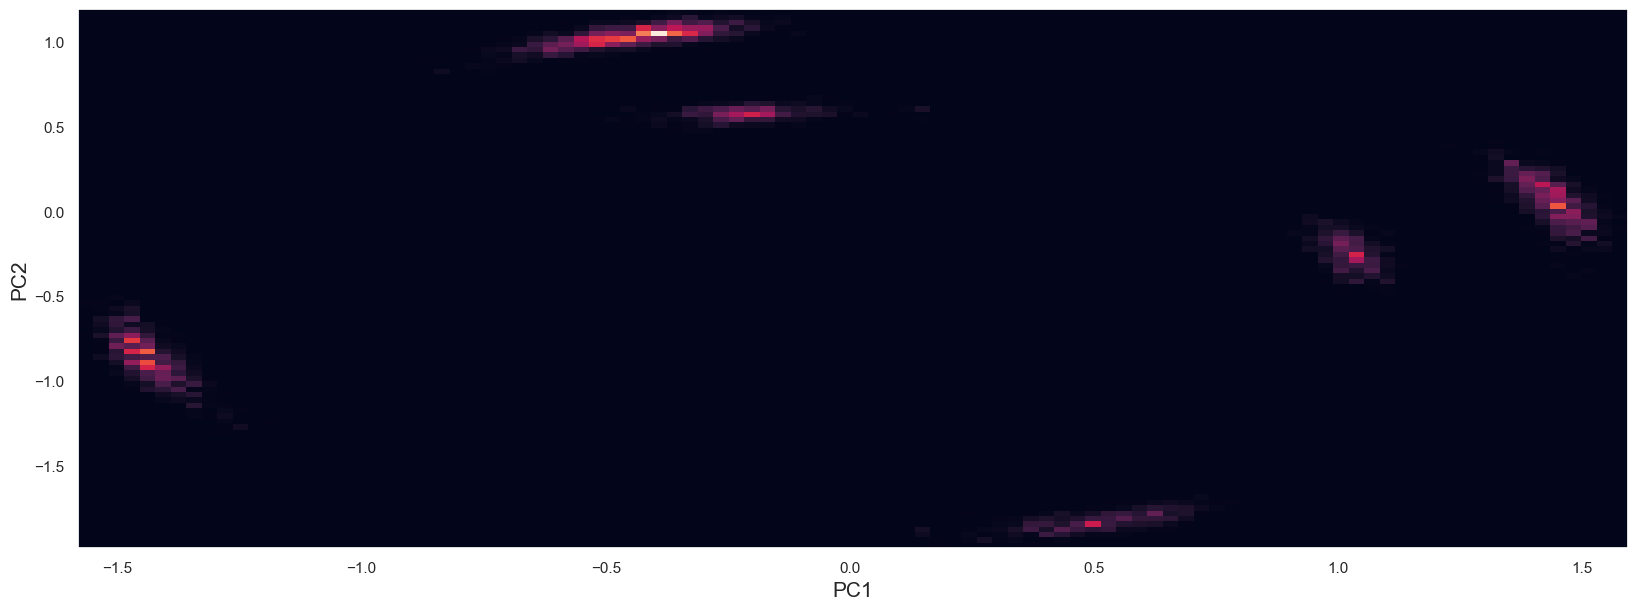

In [39]:
CASE='i'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[ 0.18573661  0.55242693 -0.16816074  0.7950147 ]
 [-0.16735327  0.760685   -0.2971349  -0.55232394]]
Fração de variànciaz explicada: [0.51394117 0.84953225]


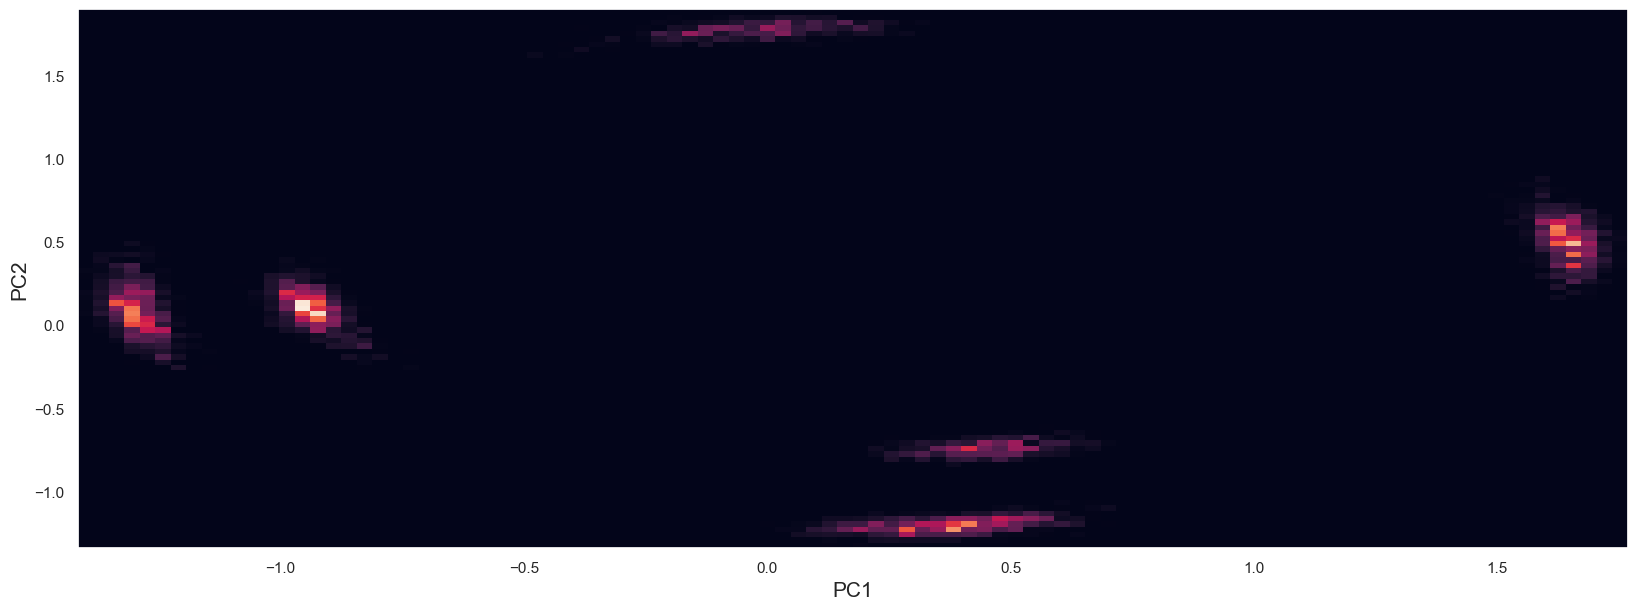

In [40]:
CASE='ii'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[ 0.27740476  0.64463586 -0.3074438   0.64262724]
 [-0.12221877  0.71435344 -0.04902755 -0.6872831 ]]
Fração de variànciaz explicada: [0.766614  0.9012184]


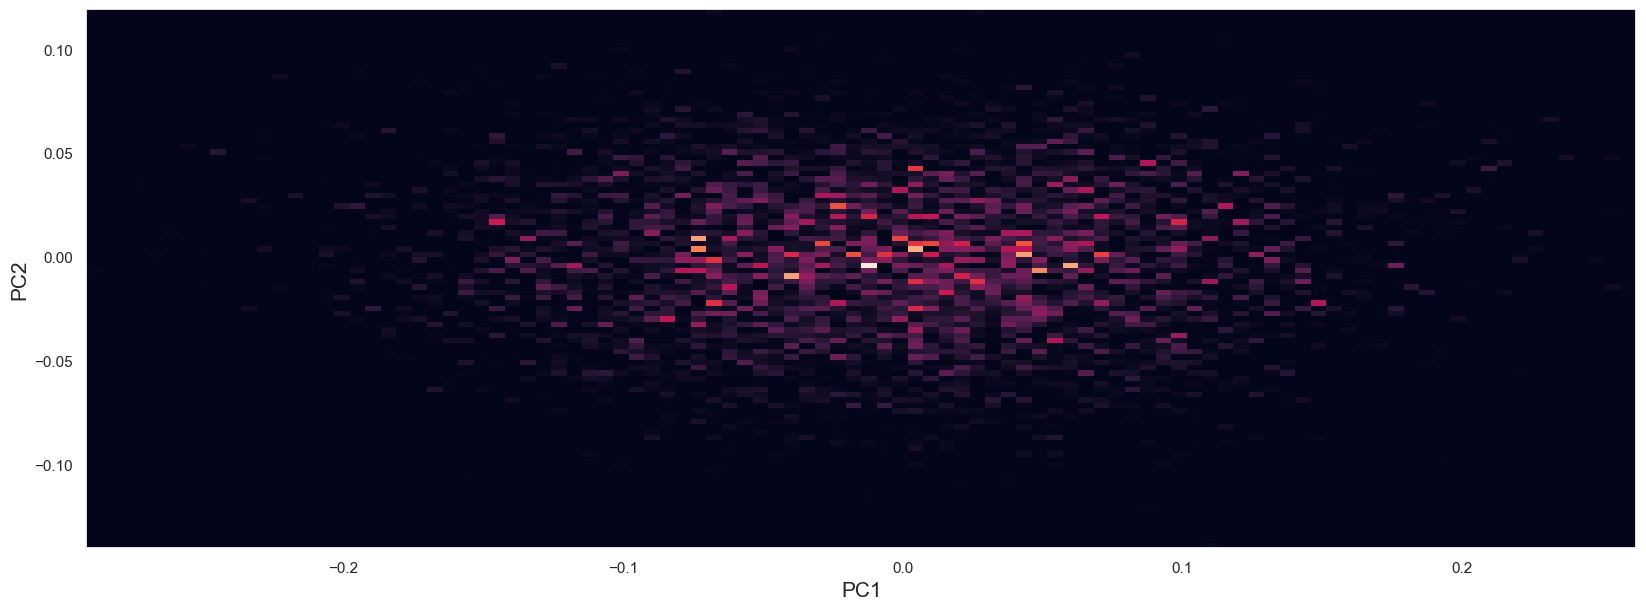

In [41]:
CASE='iii'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[ 0.0101169   0.45896965  0.23799177  0.8559231 ]
 [-0.04953128  0.793227   -0.54142535 -0.27421984]]
Fração de variànciaz explicada: [0.90549594 0.9967316 ]


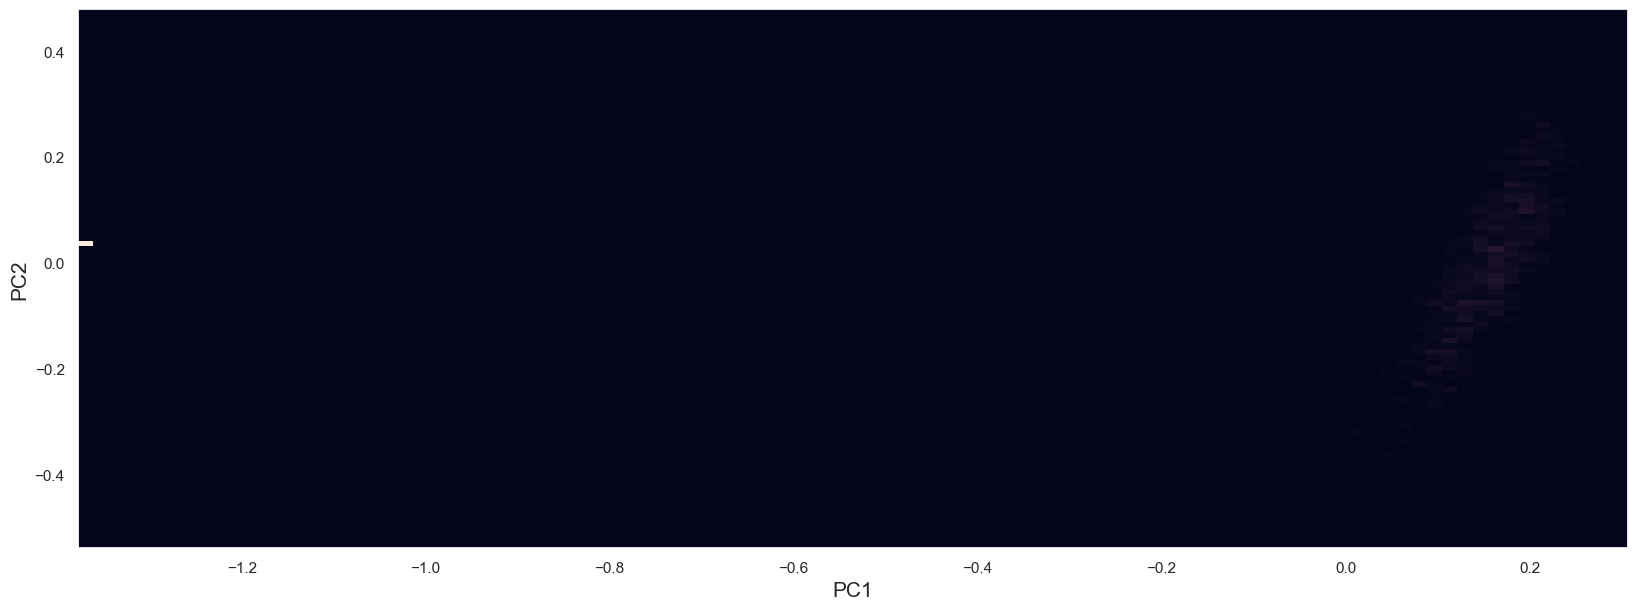

In [42]:
CASE='iv'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[-0.08343706  0.90802133 -0.1121759  -0.39490765]
 [-0.02135245  0.3925835  -0.04014326  0.9185917 ]]
Fração de variànciaz explicada: [0.44971082 0.80616593]


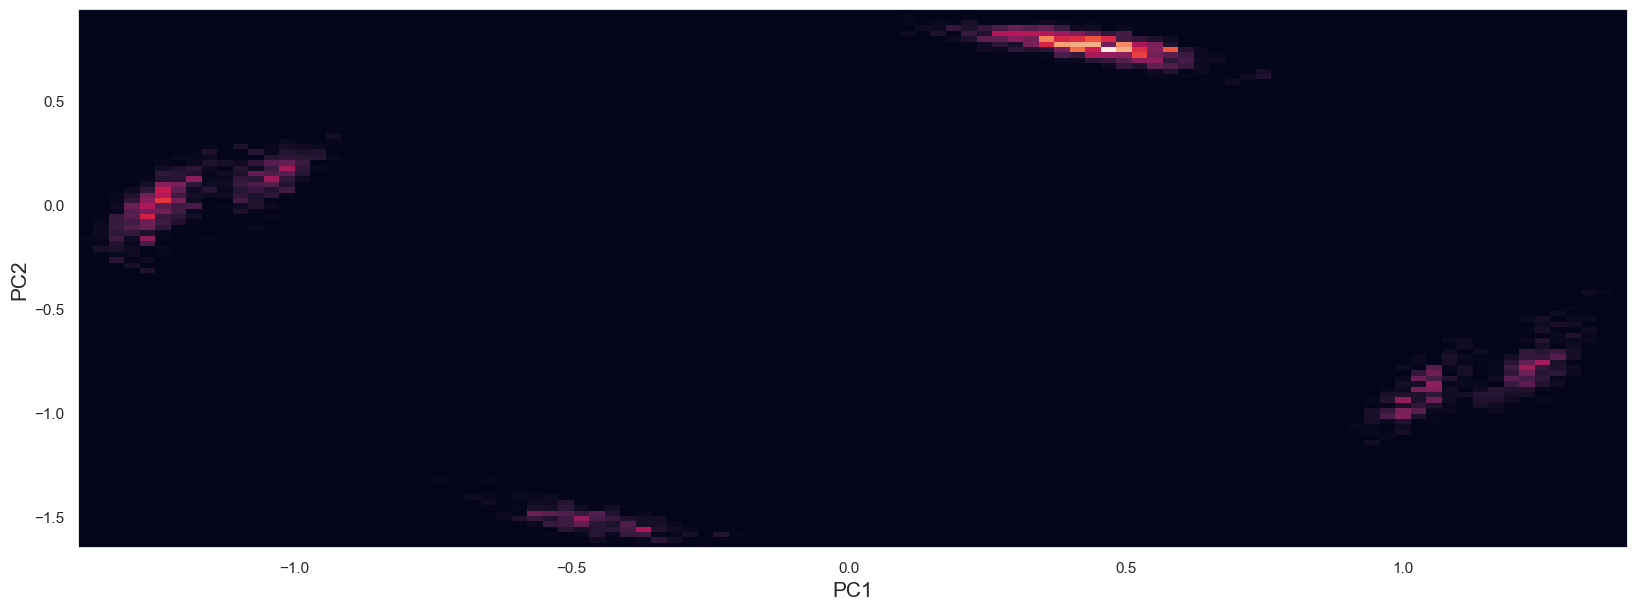

In [43]:
CASE='v'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[-0.02149594  0.76541823 -0.12925372  0.6300525 ]
 [ 0.14432839 -0.6234903   0.02704253  0.7679178 ]]
Fração de variànciaz explicada: [0.5504341 0.8106916]


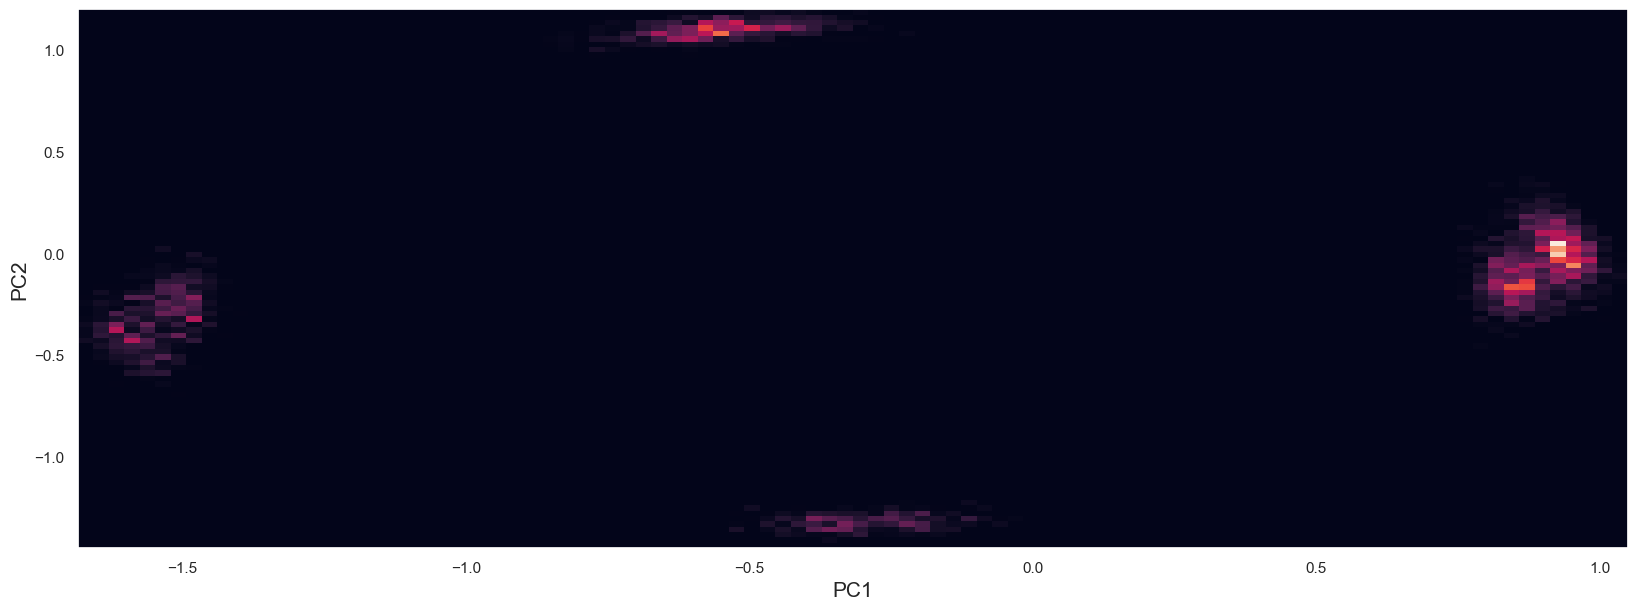

In [44]:
CASE='vi'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[ 0.6262992   0.04985857  0.76685655  0.13112733]
 [-0.44184288  0.40481102  0.2020794   0.7746398 ]]
Fração de variànciaz explicada: [0.88384145 0.9888075 ]


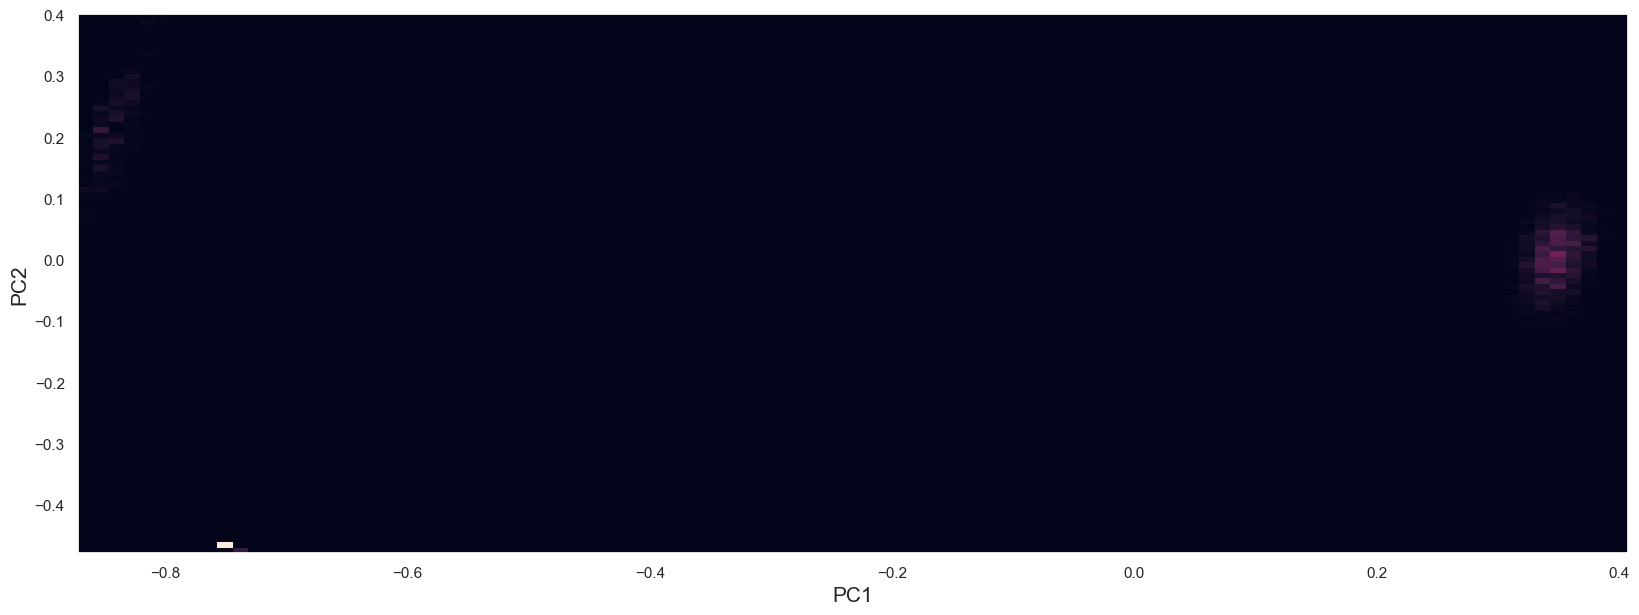

In [45]:
CASE='vii'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[-0.6177029  -0.31640166 -0.24734516  0.6761313 ]
 [ 0.7480252   0.04181656 -0.17630051  0.6384574 ]]
Fração de variànciaz explicada: [0.6801334  0.95054793]


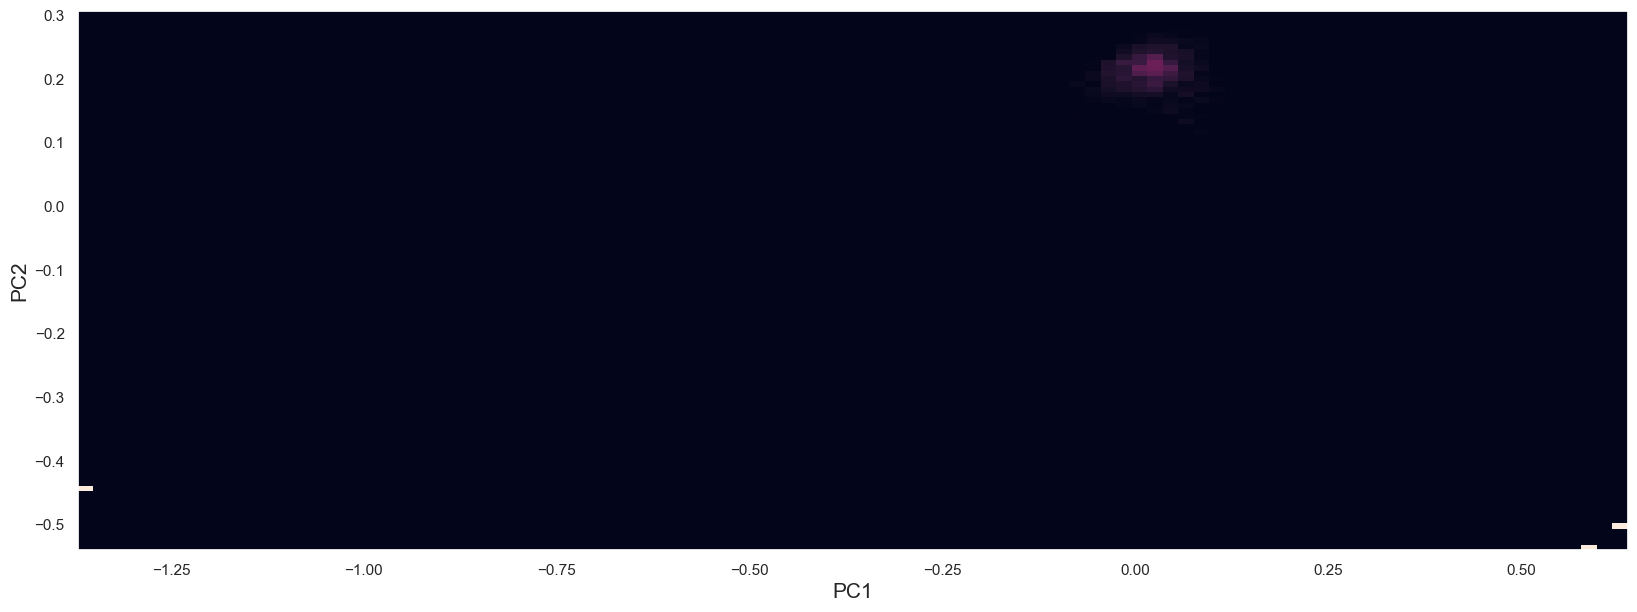

In [46]:
CASE='viii'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[-0.1902443   0.8625307   0.09186842 -0.4597913 ]
 [ 0.30419877  0.47834295  0.17155115  0.8057428 ]]
Fração de variànciaz explicada: [0.4589989 0.8616776]


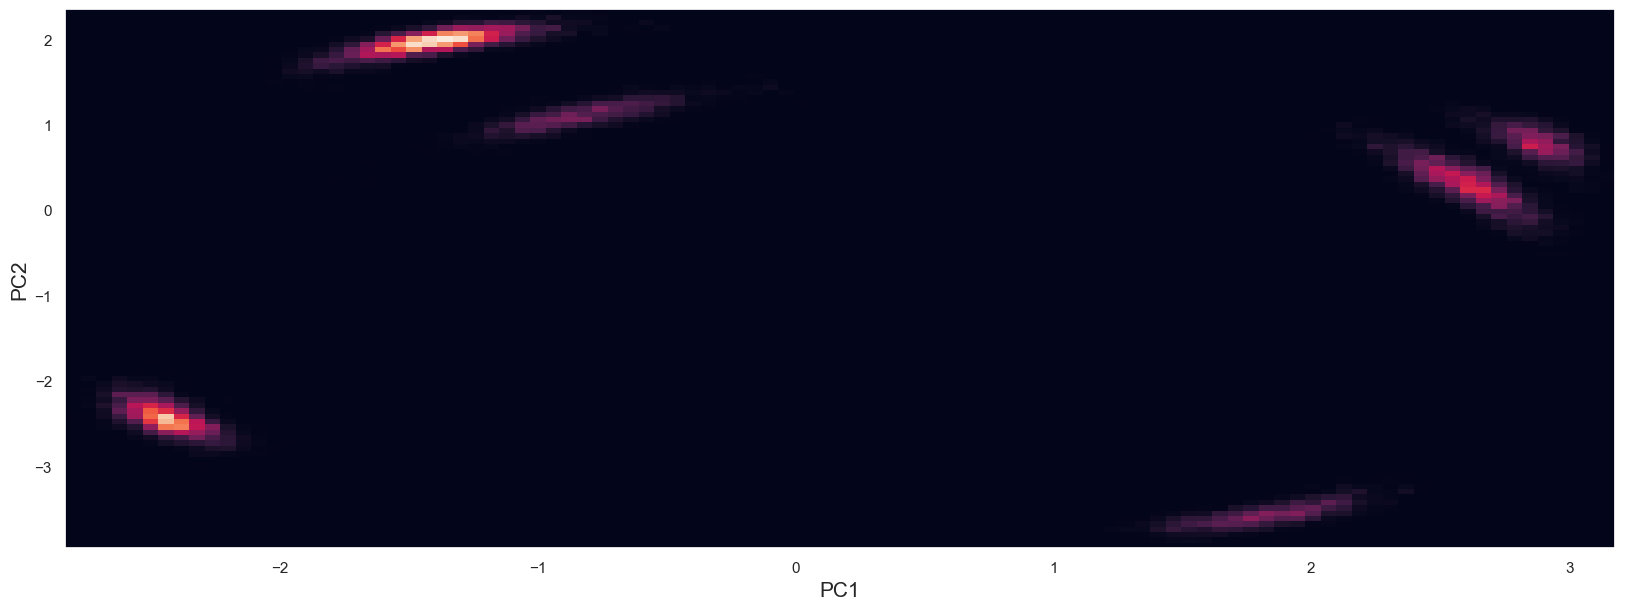

In [47]:
CASE='ix'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[ 0.16280973  0.18623227 -0.05631572  0.9672843 ]
 [-0.53866243  0.81900775 -0.18178816 -0.07760267]]
Fração de variànciaz explicada: [0.6138786 0.8476236]


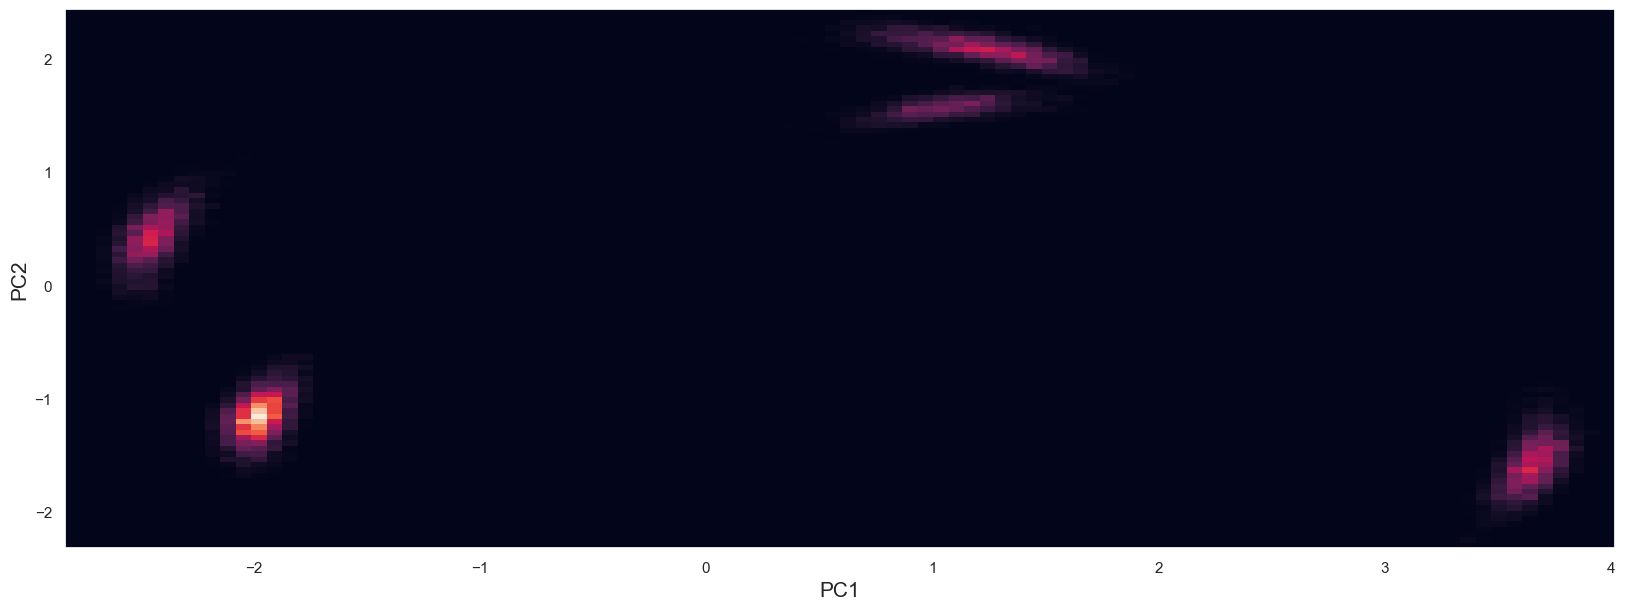

In [48]:
CASE='x'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[ 0.31689548 -0.22934437  0.70681614  0.58939743]
 [-0.32599726 -0.0782505  -0.52920085  0.77945447]]
Fração de variànciaz explicada: [0.89418536 0.9778384 ]


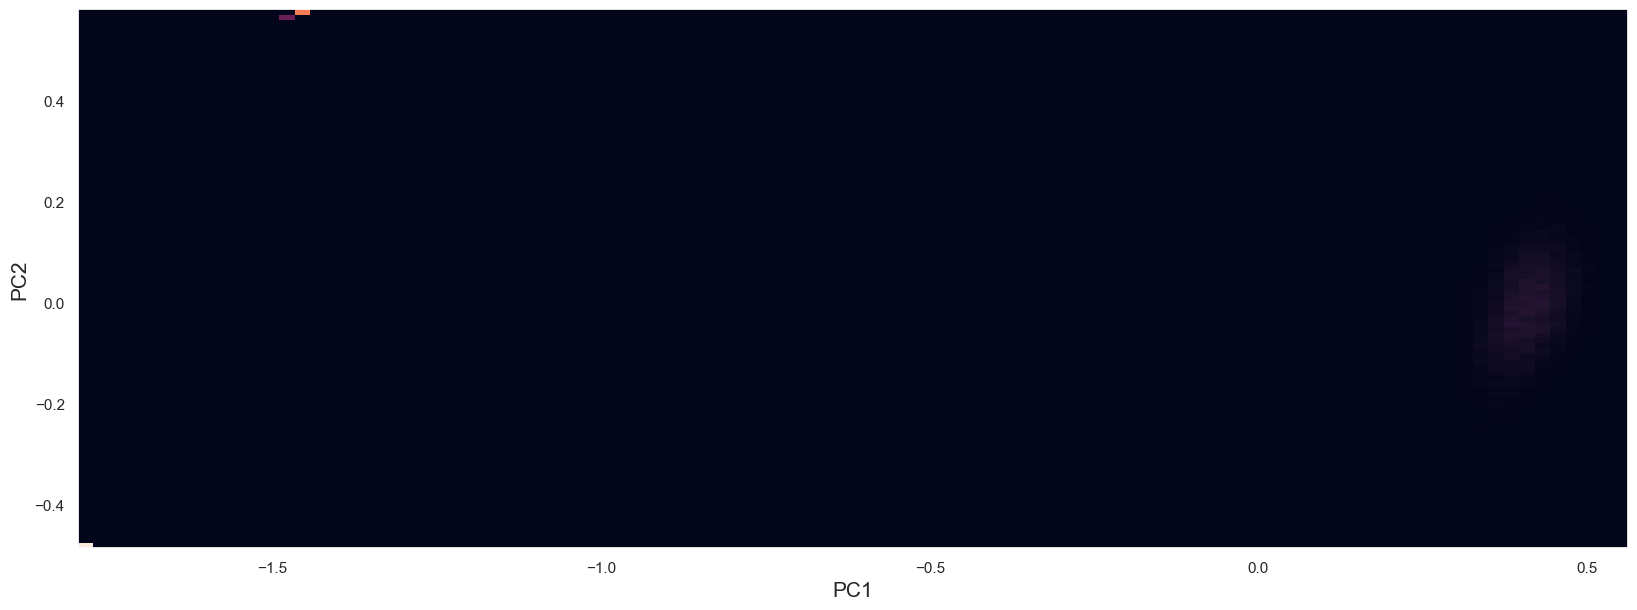

In [49]:
CASE='xi'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

Componentes:
[[-0.00526395  0.88188815 -0.47141972  0.0028987 ]
 [ 0.84781605 -0.1533368  -0.2988378  -0.4103557 ]]
Fração de variànciaz explicada: [0.8066235  0.88479203]


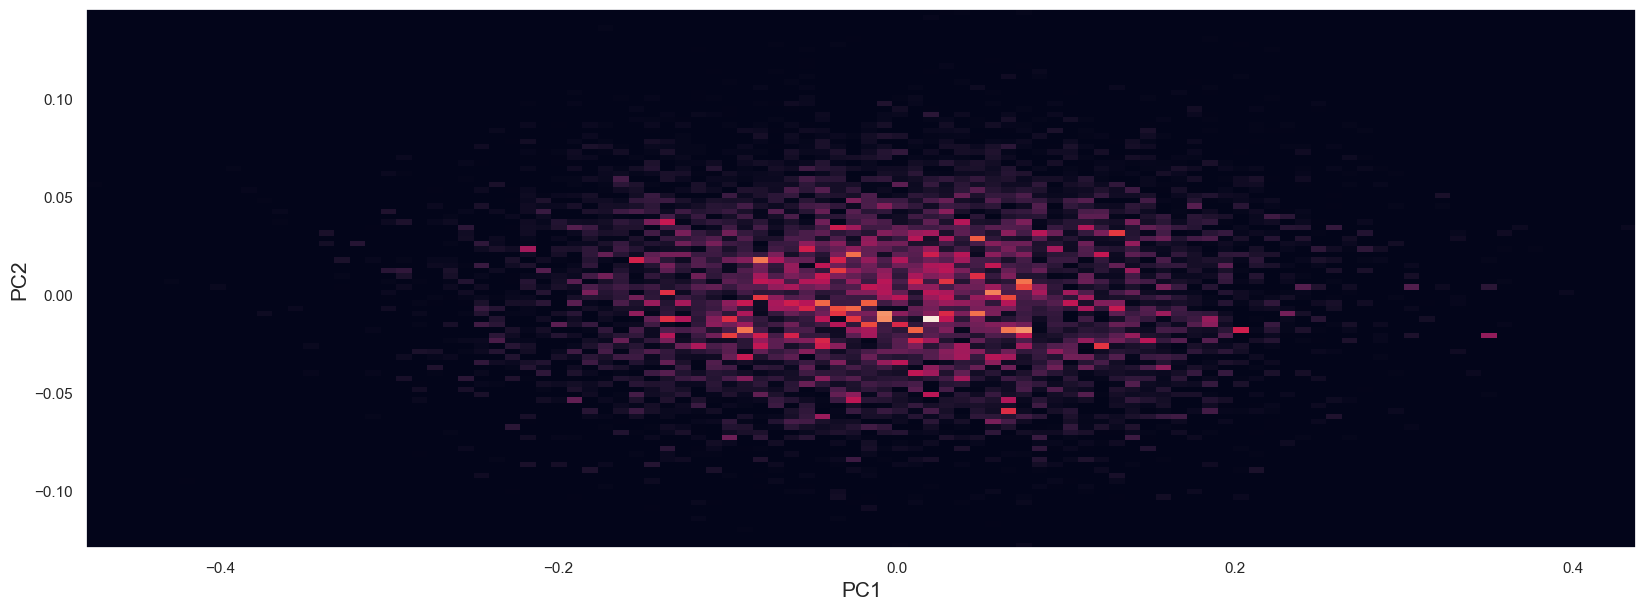

In [50]:
CASE='xii'
REALIZATION='0'

pca = get_PCA(
    case=CASE,
    parser=parser,
    B=parser.execution_config['general']['B'],
    discard_zero_var=True
)

# Executar Clustering

In [ ]:
def KMeans_analysis(
    parser,
    n_components,
    test_cases,
    covariance_type='full',
    n_init=10,
    init_params='random_from_data',
    samples_for_fit=None,
    progress_bar=False,
    random_state=0
):
    test_case_mapping = {
        'i': 1,
        'ii': 2,
        'iii': 3,
        'iv': 4,
        'v': 5,
        'vi': 6,
        'vii': 7,
        'viii': 8,
        'ix': 9,
        'x': 10,
        'xi': 11,
        'xii': 12
    }

    test_case_signal_mapping = {
        'i': 'perfect_model',
        'ii': 'perfect_model',
        'iii': 'perfect_model',
        'iv': 'perfect_model',
        'v': 'slightly_misspecified_model',
        'vi': 'slightly_misspecified_model',
        'vii': 'slightly_misspecified_model',
        'viii': 'slightly_misspecified_model',
        'ix': 'largely_misspecified_model',
        'x': 'largely_misspecified_model',
        'xi': 'largely_misspecified_model',
        'xii': 'largely_misspecified_model'
    }

    test_case_prior_mapping = {
        'i': 'likelihood',
        'ii': 'non_informative_prior',
        'iii': 'informative_prior',
        'iv': 'identity_transform',
        'v': 'likelihood',
        'vi': 'non_informative_prior',
        'vii': 'informative_prior',
        'viii': 'identity_transform',
        'ix': 'likelihood',
        'x': 'non_informative_prior',
        'xi': 'informative_prior',
        'xii': 'identity_transform'
    }
    
    SAMPLES_PER_CHAIN = parser.execution_config['mcmc']['n_samples']//parser.execution_config['mcmc']['parallel_chains']
    B = parser.execution_config['general']['B']

    bic_df = pd.DataFrame()
    # Iterate in test cases and component numbers and fit Models
    iterator = test_cases
    if progress_bar:
        iterator=tqdm(iterator)
    for case in iterator:
        for n in n_components:
            
            STARTING_DIST_LOW=-5
            STARTING_DIST_HIGH=5

            samples_chains = [
                chain_samples[-SAMPLES_PER_CHAIN:,:,:] for chain_samples in parser.parsed_results[case]['mmse']['object'][0].samples
            ]

            discard_chain = []
            for c_samples in samples_chains:
                discard=True
                for i,j in np.ndindex(B.shape):
                    if np.var(c_samples[:1000,i,j])>1E-20:
                        discard=False

                discard_chain.append(discard)
            
            retained_chains_samples = [
                c_samples for c_samples, discard in zip(
                    samples_chains, discard_chain
                ) if not discard
            ]    
            # Get test case samples
            test_case_samples = np.concatenate(
                retained_chains_samples,
                axis=0
            )

            # Get mixture signal
            x = parser.realizations_results[str(0)][
                    test_case_signal_mapping[case]
            ]['x']

            # Get source model
            source_pdf = StandardLogisticSource().get()

            # Get prior
            prior_pdf = parser.execution_config['sim']['priors'][test_case_prior_mapping[case]].get()

            # Get posterior
            posterior_fn = PosteriorUtilities.get_log_posterior_fn(
                    source_pdf_fn=source_pdf,
                    prior_pdf_fn=prior_pdf
            )

            flattened_samples = np.array(
                [np.matrix.flatten(s) for s in test_case_samples]
            )

            if samples_for_fit is not None:
                chosen_idxs = np.random.choice(
                        range(len(flattened_samples)),
                        samples_for_fit
                )
                flattened_samples = flattened_samples[chosen_idxs]
            
            # Get unique samples
            flattened_samples_unique, counts = np.unique(
                flattened_samples,
                axis=0,
                return_counts=True
            )

            # Fit KMeans
            kmeans = KMeans(
                n_clusters=n,
                init=init_params['kmeans'],
                n_init=n_init,
                random_state=random_state
            ).fit(
                flattened_samples_unique,
                sample_weight=counts
            )

            # Fit GMM
            gmm = GaussianMixture(
                n_components=n,
                covariance_type=covariance_type,
                means_init=kmeans.cluster_centers_,
                reg_covar=1E-5,
                tol=1E-5,
                max_iter=1000,
                random_state=random_state
            ).fit(
                flattened_samples
            )

            

            # Get largest GMM posterior mean
            max_posterior_mean = np.max([
                posterior_fn(
                    x=x,
                    B=np.reshape(
                        mu,
                        parser.execution_config['general']['B'].shape
                    )
                ) for mu in gmm.means_
            ])

            # Get largest KMeans posterior centroid
            max_posterior_centroid = np.max([
                posterior_fn(
                    x=x,
                    B=np.reshape(
                            mu,
                            parser.execution_config['general']['B'].shape
                    )
                ) for mu in kmeans.cluster_centers_
            ])


            # Log results
            bic_df = pd.concat(
                [
                    bic_df,
                    pd.DataFrame(
                        index=[0],
                        data={
                            'n_components': [n],
                            'test_case': [case],
                            'gmm': [gmm],
                            'gmm_bic': gmm.bic(flattened_samples),
                            'gmm_max_posterior_mean': [max_posterior_mean],
                            'kmeans': [kmeans],
                            'kmeans_inertia': [kmeans.inertia_],
                            'kmeans_max_posterior_centroid': [max_posterior_centroid]

                        }
                    )
                ],
                axis=0
            ).reset_index(
                drop=True
            )

    colors = [
        'green',
        'darkorange',
        'red'
    ]

    markers = [
        's',
        '>',
        '<',
        'o'
    ]

    gmm_fig, (gmm_ax, gmm_posterior_ax) = plt.subplots(
        nrows=2, ncols=1,
        figsize=(20,15)
    )
    gmm_fig.suptitle(
            'Análise: GMM',
            fontsize=20
    )

    kmeans_fig, (kmeans_ax, kmeans_posterior_ax) = plt.subplots(
        nrows=2, ncols=1,
        figsize=(20,15)
    )
    kmeans_fig.suptitle(
         'Análise: KMeans',
         fontsize=20
    )

    best_models = {}
    for case in test_cases:
        # Filter test case
        case_df = bic_df[
            bic_df.test_case==case
        ]

        # Get test case in number
        case_number = test_case_mapping[case]

        # Get x for plot
        case_components = case_df['n_components'].values

        # Get y for plots
        case_bic = case_df['gmm_bic'].values
        case_inertia = case_df['kmeans_inertia'].values
        case_max_mean_posterior = case_df['gmm_max_posterior_mean'].values
        case_max_centroid_posterior = case_df['kmeans_max_posterior_centroid'].values

        # Get best model for test case and save
        best_gmm_model = case_df.loc[case_df.gmm_bic.idxmin()]['n_components']
        best_kmeans_model = case_df.loc[case_df.kmeans_inertia.idxmin()]['n_components']
        best_models[case]={
             'gmm': int(best_gmm_model),
             'kmeans': int(best_kmeans_model)
        }

        gmm_ax.plot(
            case_components,
            case_bic,
            color=colors[(case_number-1)//4],
            marker=markers[case_number%4],
            linestyle='--',
            alpha=0.6,
            label=case
        )

        gmm_posterior_ax.plot(
            case_components,
            case_max_mean_posterior,
            color=colors[(case_number-1)//4],
            marker=markers[case_number%4],
            linestyle='--',
            alpha=0.6,
            label=case
        )

        kmeans_ax.plot(
            case_components,
            case_inertia,
            color=colors[(case_number-1)//4],
            marker=markers[case_number%4],
            linestyle='--',
            alpha=0.6,
            label=case
        )

        kmeans_posterior_ax.plot(
            case_components,
            case_max_centroid_posterior,
            color=colors[(case_number-1)//4],
            marker=markers[case_number%4],
            linestyle='--',
            alpha=0.6,
            label=case
        )

    gmm_ax.set_xlabel(
        'Número de Gaussianas',
        fontsize=15
    )

    gmm_ax.set_ylabel(
        'BIC',
        fontsize=15
    )

    gmm_posterior_ax.set_xlabel(
        'Número de Gaussianas',
        fontsize=15
    )

    gmm_posterior_ax.set_ylabel(
        'Máxima posteriori entre as médias',
        fontsize=15
    )

    gmm_ax.legend(title='Caso de Teste')
    gmm_posterior_ax.legend(title='Caso de Teste')

    kmeans_ax.set_xlabel(
        'Número de Clusters',
        fontsize=15
    )

    kmeans_ax.set_ylabel(
        'Inertia',
        fontsize=15
    )

    kmeans_posterior_ax.set_xlabel(
        'Número de Clusters',
        fontsize=15
    )

    kmeans_posterior_ax.set_ylabel(
        'Máxima posteriori entre os centróides',
        fontsize=15
    )

    kmeans_ax.legend(title='Caso de Teste')
    kmeans_posterior_ax.legend(title='Caso de Teste')

    return bic_df, best_models

240it [2:36:42, 39.18s/it] 


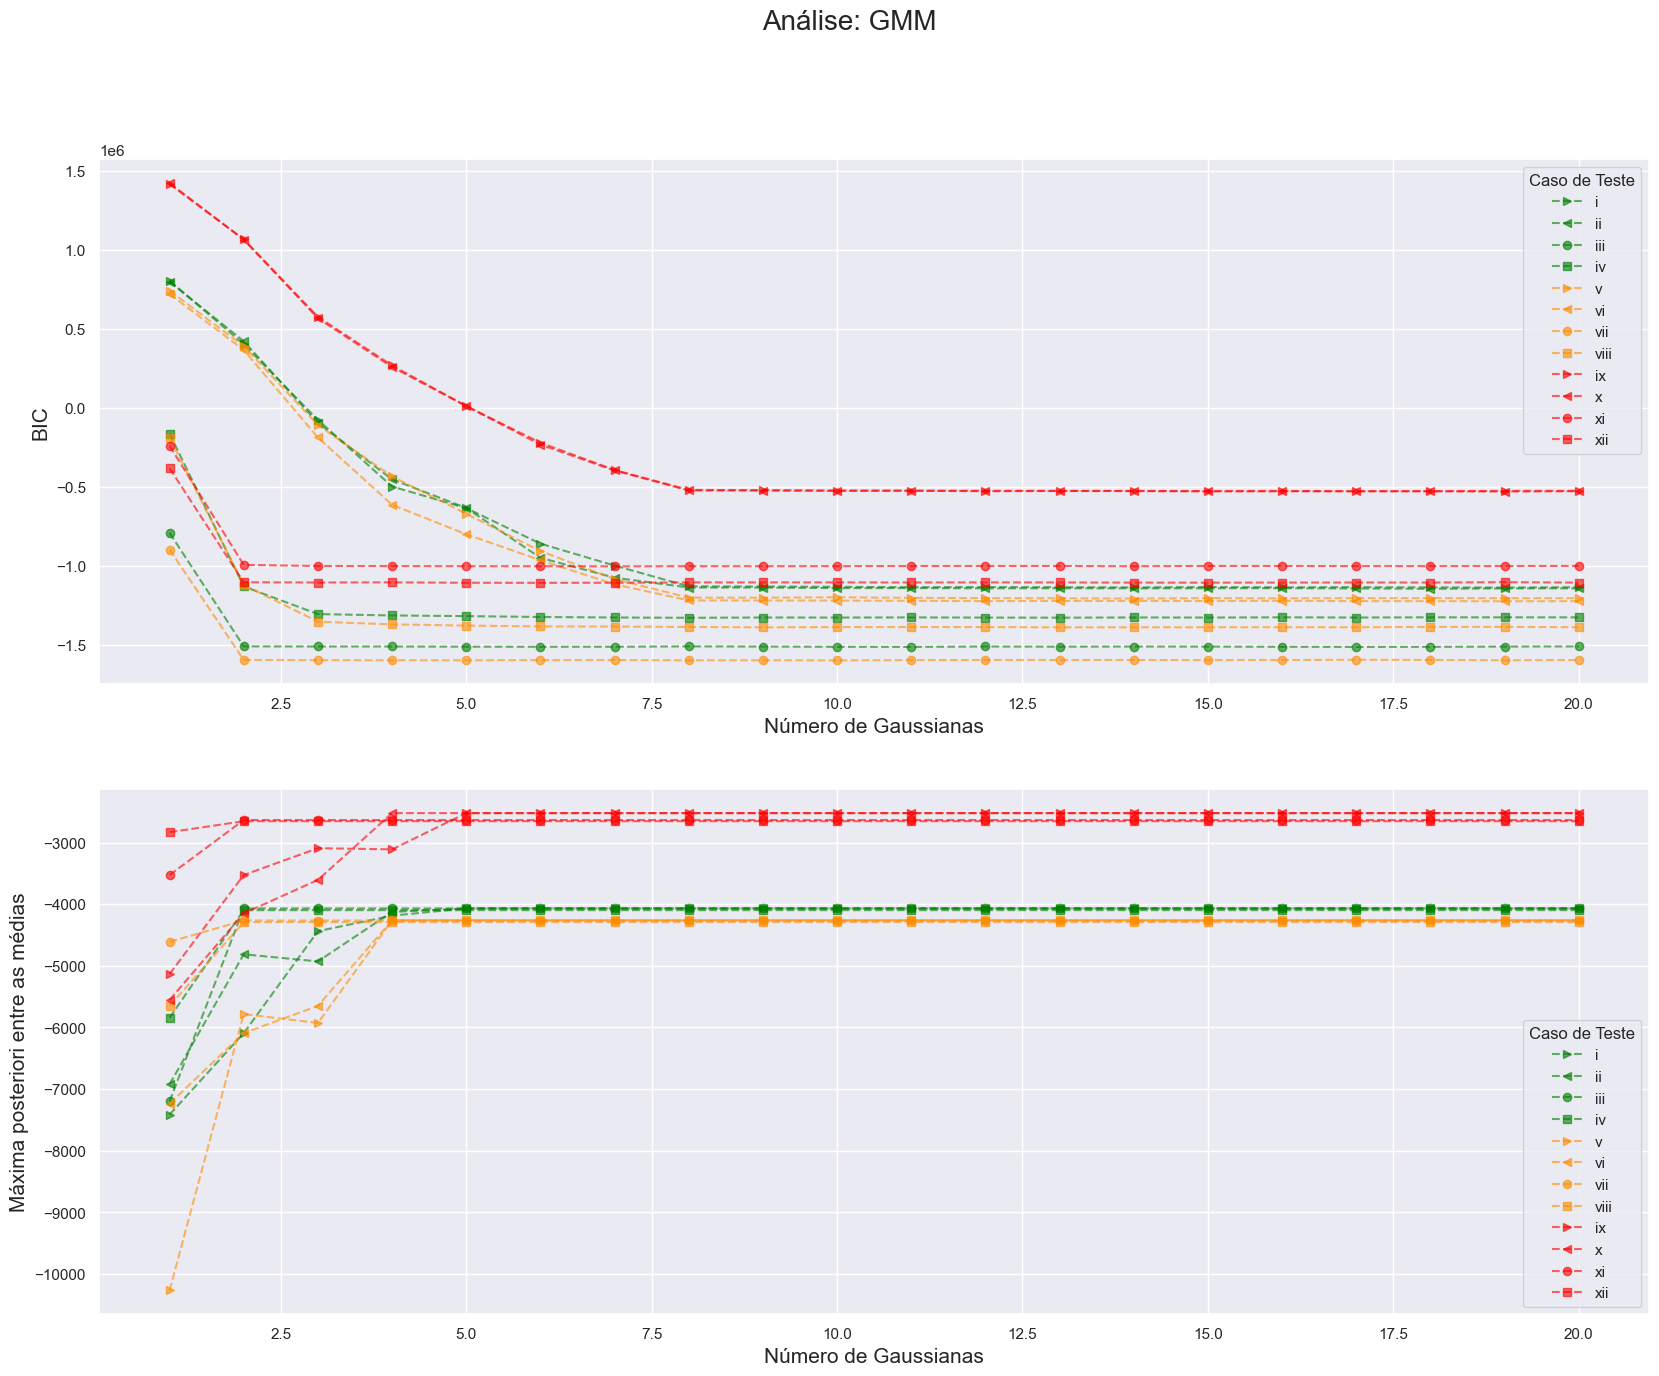

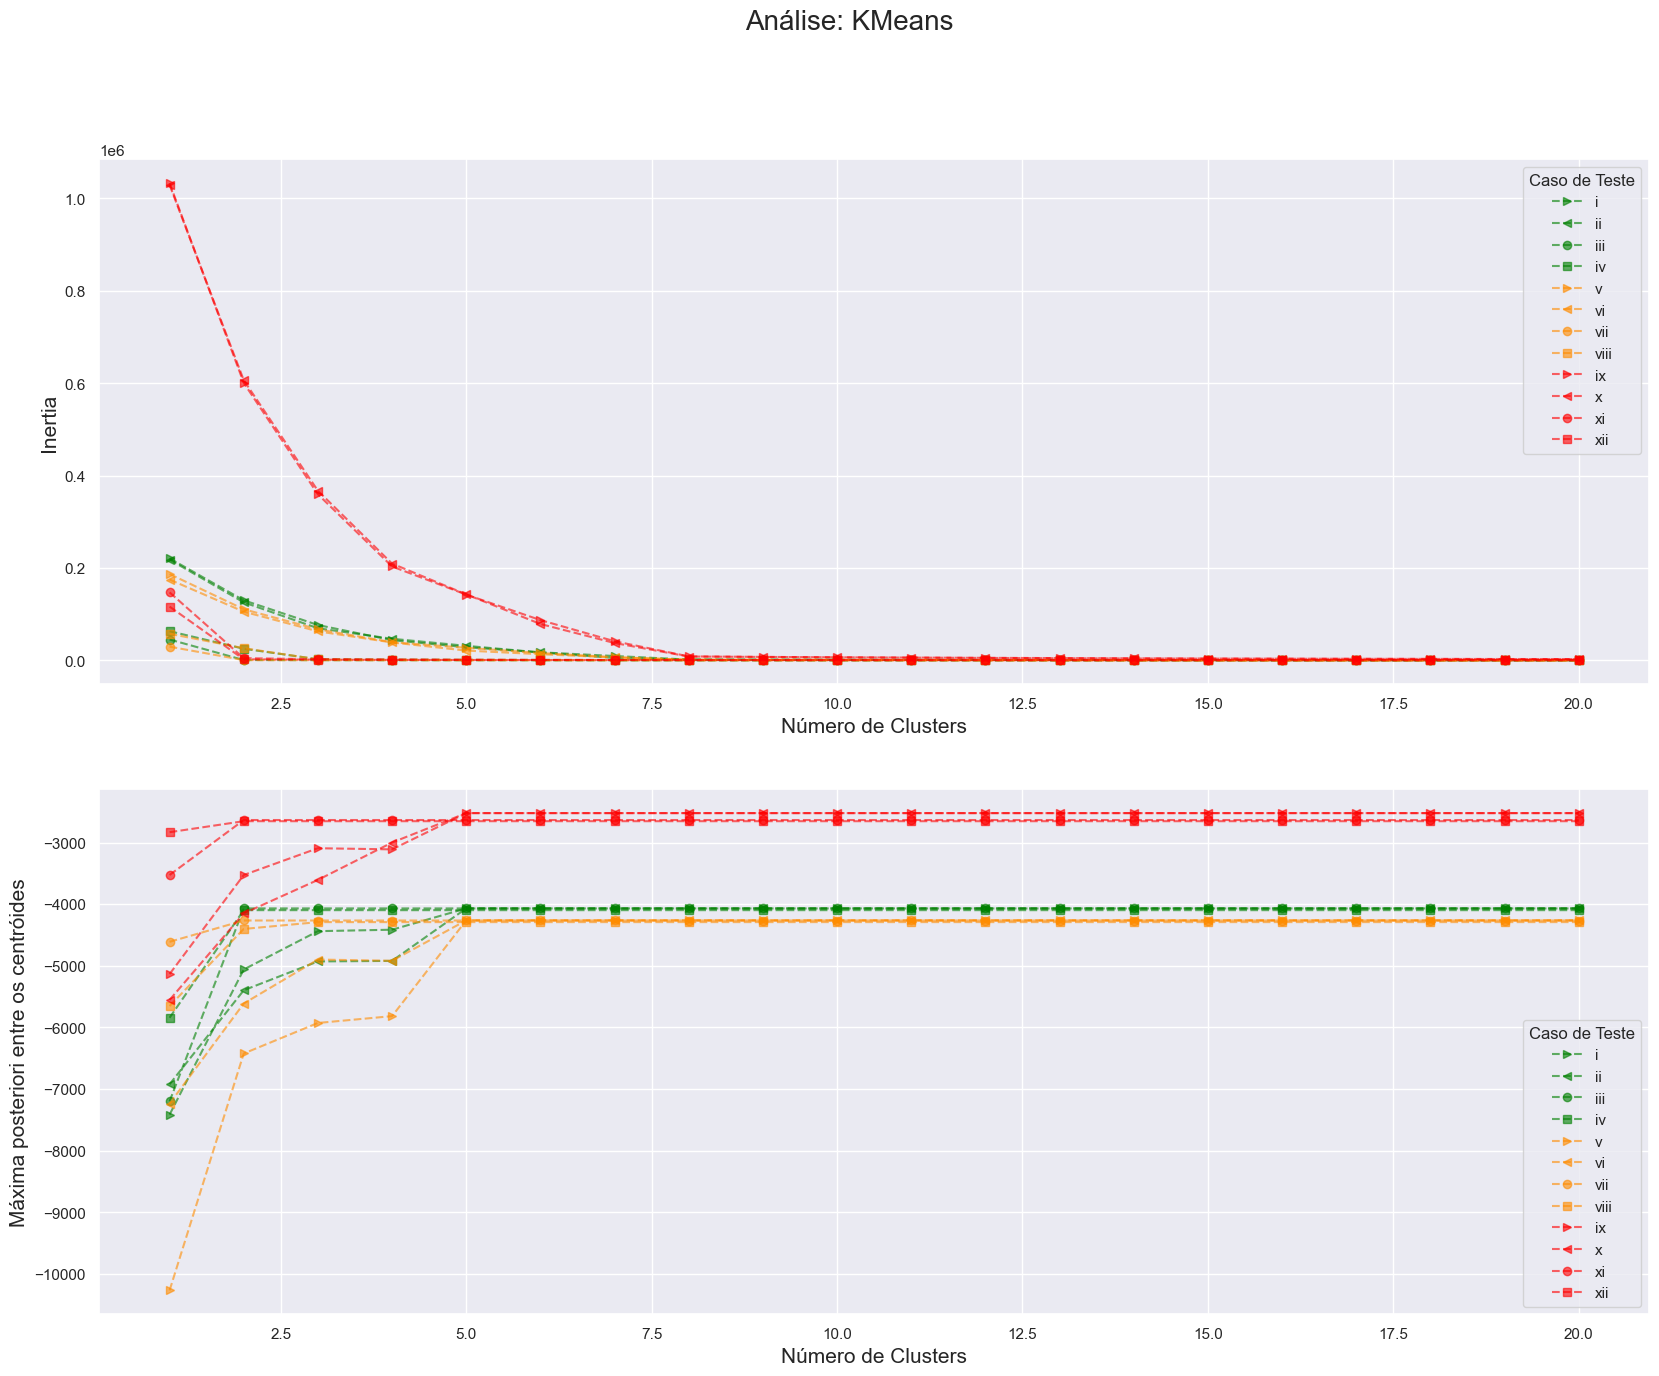

In [ ]:
bic_df, best_models = KMeans_analysis(
    parser,
    n_components=range(1,21),
    test_cases=['i','ii','iii','iv','v','vi','vii','viii','ix','x','xi','xii'],
    samples_for_fit=100000,
    n_init=10,
    init_params={
        'gmm': 'k-means++',
        'kmeans': 'k-means++'
    }
)

In [ ]:
bic_df.to_pickle('bic_df_1M_20clusters.pkl')

In [ ]:
def visualize_cluster_centroids(
    case,
    realization,
    n_clusters,
    clustering_df,
    parser,
    B,
    discard_zero_var=True,
    samples_per_chain=None,
    printed_centroids=10
):
    
    test_case_mapping = {
        'i': 1,
        'ii': 2,
        'iii': 3,
        'iv': 4,
        'v': 5,
        'vi': 6,
        'vii': 7,
        'viii': 8,
        'ix': 9,
        'x': 10,
        'xi': 11,
        'xii': 12
    }

    test_case_signal_mapping = {
        'i': 'perfect_model',
        'ii': 'perfect_model',
        'iii': 'perfect_model',
        'iv': 'perfect_model',
        'v': 'slightly_misspecified_model',
        'vi': 'slightly_misspecified_model',
        'vii': 'slightly_misspecified_model',
        'viii': 'slightly_misspecified_model',
        'ix': 'largely_misspecified_model',
        'x': 'largely_misspecified_model',
        'xi': 'largely_misspecified_model',
        'xii': 'largely_misspecified_model'
    }

    test_case_prior_mapping = {
        'i': 'likelihood',
        'ii': 'non_informative_prior',
        'iii': 'informative_prior',
        'iv': 'identity_transform',
        'v': 'likelihood',
        'vi': 'non_informative_prior',
        'vii': 'informative_prior',
        'viii': 'identity_transform',
        'ix': 'likelihood',
        'x': 'non_informative_prior',
        'xi': 'informative_prior',
        'xii': 'identity_transform'
    }

    # Get source model
    source_pdf = StandardLogisticSource().get()

    # Get prior
    prior_pdf = parser.execution_config['sim']['priors'][test_case_prior_mapping[case]].get()

    # Get posterior
    posterior_fn = PosteriorUtilities.get_log_posterior_fn(
            source_pdf_fn=source_pdf,
            prior_pdf_fn=prior_pdf
    )

    # Get mixture signal
    x = parser.realizations_results[str(0)][
            test_case_signal_mapping[case]
    ]['x']
    
    if samples_per_chain is not None:
        SAMPLES_PER_CHAIN=samples_per_chain
    else:
        SAMPLES_PER_CHAIN = parser.execution_config['mcmc']['n_samples']//parser.execution_config['mcmc']['parallel_chains']
        
    STARTING_DIST_LOW=-5
    STARTING_DIST_HIGH=5

    samples_chains = [
        chain_samples[-SAMPLES_PER_CHAIN:,:,:] for chain_samples in parser.parsed_results[case]['mmse']['object'][0].samples
    ]

    discard_chain = []
    for c_samples in samples_chains:
        discard=True
        for i,j in np.ndindex(B.shape):
            if np.var(c_samples[:1000,i,j])>1E-20:
                discard=False

        discard_chain.append(discard)
    
    retained_chains_samples = [
        c_samples for c_samples, discard in zip(
            samples_chains, discard_chain
        ) if not discard
    ]    
    samples = np.concatenate(
        retained_chains_samples,
        axis=0
    )
    sample_shape = samples.shape[1:]

    for c in n_clusters:
        # Get gmm model
        gmm = clustering_df[
            (clustering_df.test_case==case)&
            (clustering_df.n_components==c)
        ]['gmm'].values[0]

        # Get gaussian means
        gmm_means = [
            np.reshape(
                mu,
                sample_shape
            ) for mu in gmm.means_
        ]

        # Get gmm means posteriors
        means_posteriors = [
            posterior_fn(
                x=x,
                B=mu
            ) for mu in gmm_means
        ]
        
        # Get centroids with largest posterior values
        top_means = np.flip(np.argpartition(means_posteriors, -1))[:printed_centroids]
        max_posterior_centroid = gmm_means[top_means[0]]

        sorted_centroids = {str(i+1): (gmm_means[idx], posterior_fn(x, gmm_means[idx])) for i, idx in enumerate(top_means)}

        # Distances to true B
        B_distances = [
            np.linalg.norm(
                np.subtract(
                    B_est,
                    B
                ) 
            ) for B_est in gmm_means
        ]
        best_centroid = gmm_means[np.argmin(B_distances)]
        smallest_distance = B_distances[np.argmin(B_distances)]

        
        print('Sorted gaussian means by greatest posterior:\n')
        pprint.pp(sorted_centroids)
        print('-'*100)
        print('Gaussian mean closest to true B:')
        pprint.pp(best_centroid)
        print('Smallest distance (Frobenius): {}'.format(round(smallest_distance, 3)))

        dist_fig, dist_axs = plt.subplots(
            nrows=2, ncols=2,
            figsize=(20,15)
        )

        dist_fig.suptitle(
            'Médias: {} gaussianas'.format(c),
            fontsize=20
        )

        for i, j in np.ndindex(B.shape):
            dist_axs[i,j].hist(
                samples[:,i,j],
                alpha=0.3,
                bins='auto',
                color='cornflowerblue'
            )

            dist_axs[i,j].axvline(
                max_posterior_centroid[i,j],
                linestyle='--',
                color='cornflowerblue'
            )
            
            dist_axs[i,j].legend()

    



Sorted gaussian means by greatest posterior:

{'1': (array([[-0.47375638, -0.92651173],
       [-0.49178685,  0.99146635]]),
       np.float64(-4068.732167940392)),
 '2': (array([[-0.47455173, -0.92255076],
       [ 0.49050869, -0.99454853]]),
       np.float64(-4068.737276028496)),
 '3': (array([[ 0.47645212,  0.91828308],
       [-0.48857599,  0.99751344]]),
       np.float64(-4068.7438259114756)),
 '4': (array([[ 0.4737703 ,  0.92349574],
       [ 0.49137469, -0.99219401]]),
       np.float64(-4068.738438059665)),
 '5': (array([[-0.48941084,  0.99440578],
       [-0.47590718, -0.91906983]]),
       np.float64(-4068.746545186264)),
 '6': (array([[ 0.48988954, -0.99450394],
       [-0.47546745, -0.92083688]]),
       np.float64(-4068.740295556899)),
 '7': (array([[ 0.49268464, -0.98955301],
       [ 0.47270451,  0.9263517 ]]),
       np.float64(-4068.7359056156715)),
 '8': (array([[-0.49049838,  0.99421677],
       [ 0.47492461,  0.92214931]]),
       np.float64(-4068.736992578039))}


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


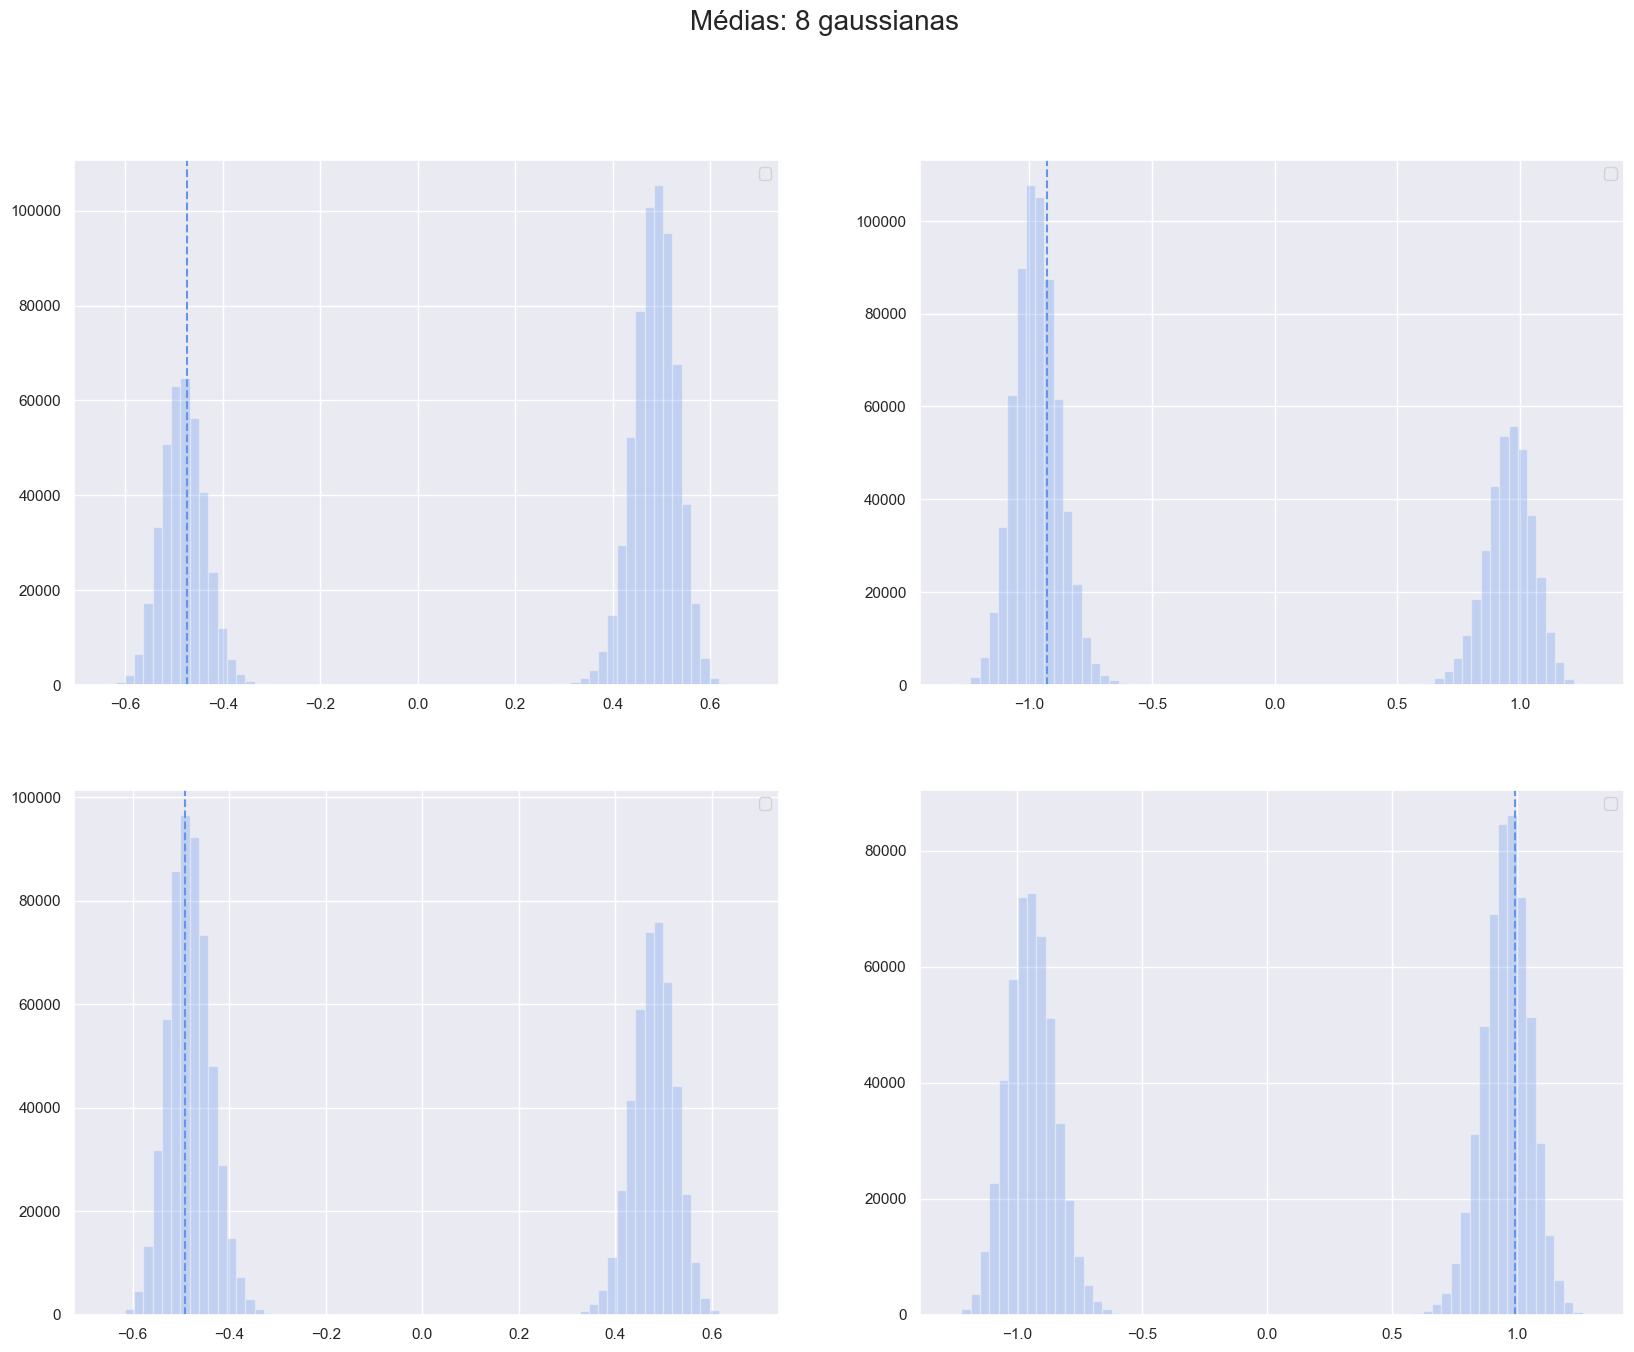

In [ ]:
CASE = 'i'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[8],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B']
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.49097346, -0.99225339],
       [ 0.47418597,  0.92340265]]),
       np.float64(-4068.738513519222)),
 '2': (array([[ 0.49362151, -0.98618998],
       [-0.47154423, -0.92989343]]),
       np.float64(-4068.760177796362)),
 '3': (array([[-0.4917607 ,  0.99092381],
       [ 0.47342366,  0.9245977 ]]),
       np.float64(-4068.7627904625606)),
 '4': (array([[-0.49446935,  0.98447501],
       [-0.47025641, -0.93095232]]),
       np.float64(-4068.7887405236906)),
 '5': (array([[ 0.47749698,  0.91433095],
       [ 0.48688852, -1.00117357]]),
       np.float64(-4068.7924650166933)),
 '6': (array([[-0.47378836, -0.92428868],
       [ 0.49160732, -0.99252676]]),
       np.float64(-4068.7595838434854)),
 '7': (array([[ 0.47330791,  0.92485437],
       [-0.49188451,  0.99168505]]),
       np.float64(-4068.7594612704593)),
 '8': (array([[-0.47281087, -0.92588781],
       [-0.49235275,  0.99060255]]),
       np.float64(-4068.7455202663214

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


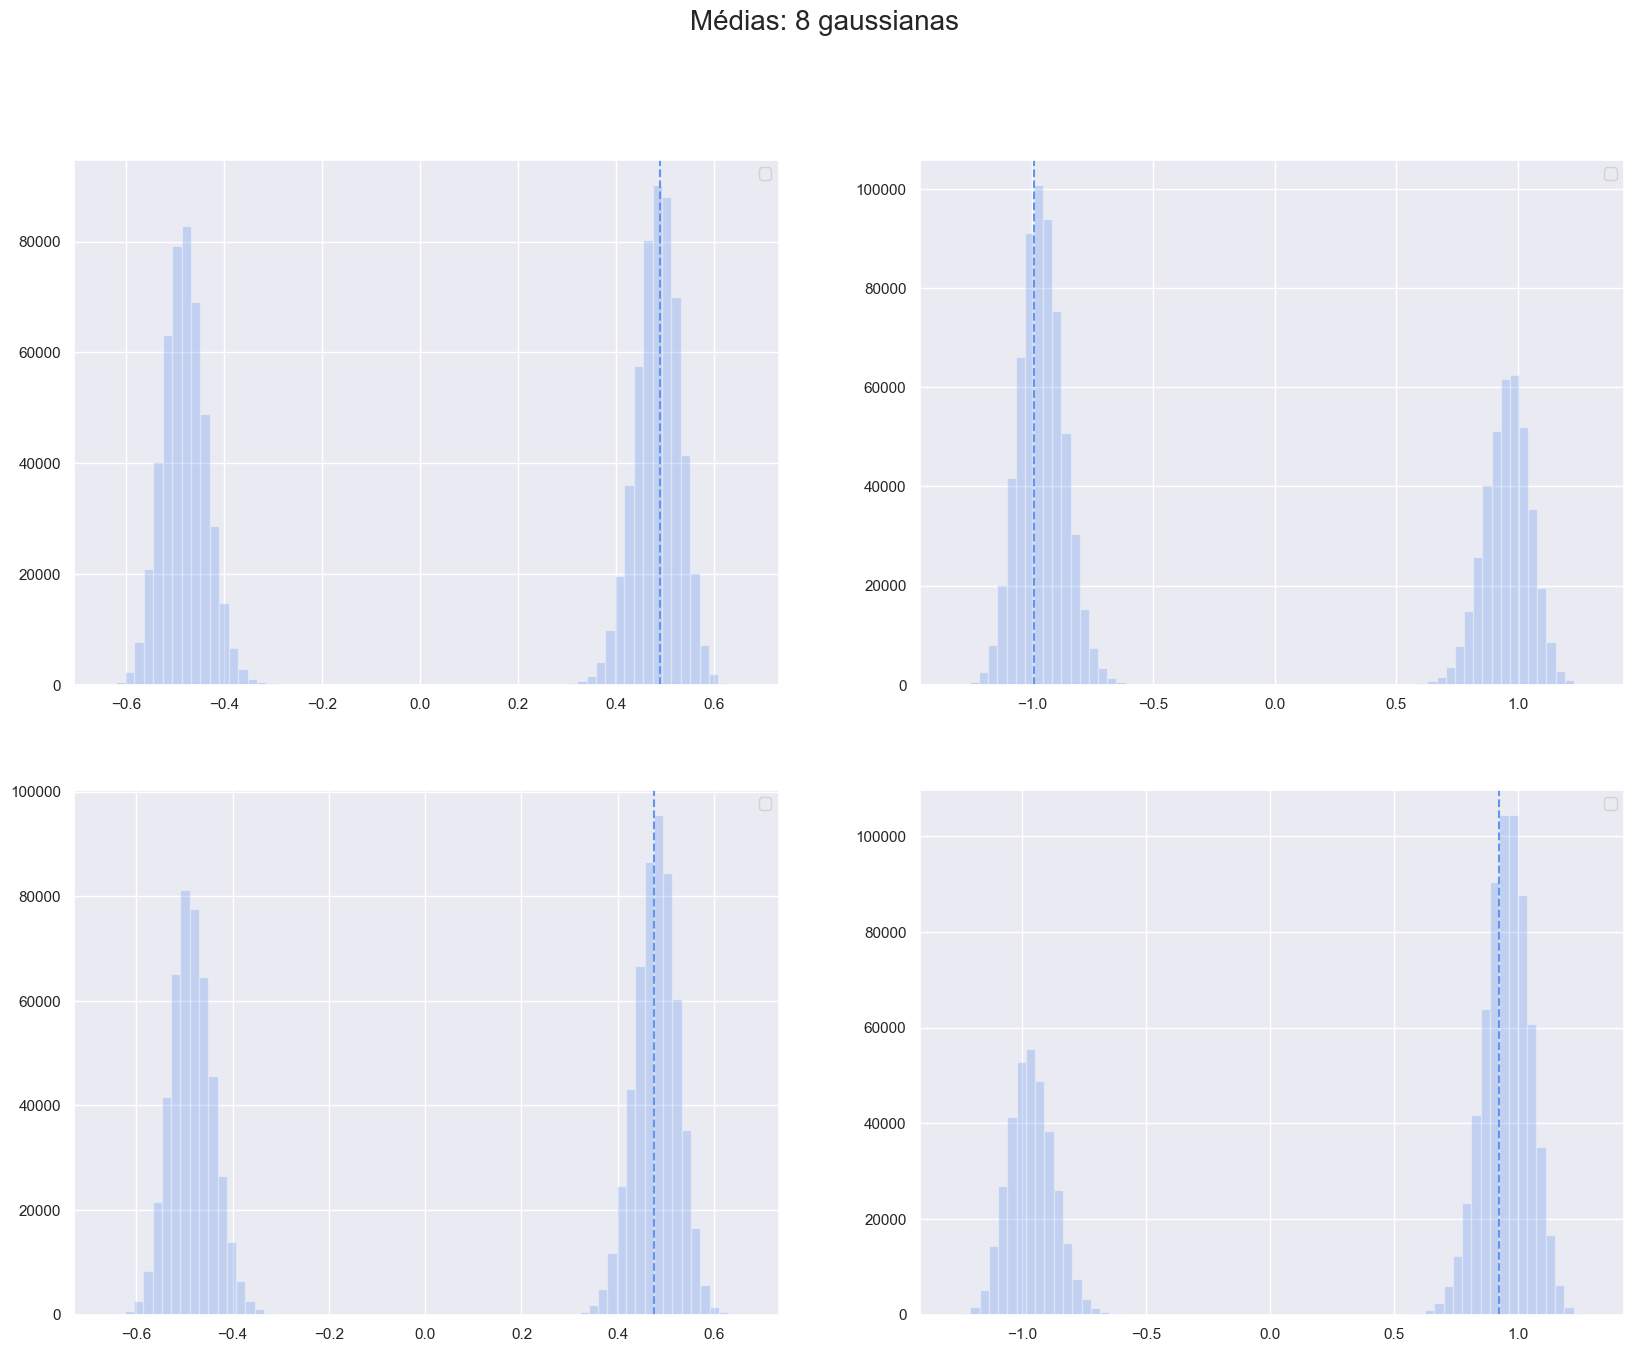

In [ ]:
CASE = 'ii'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[8],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B']
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.50142318, -0.97926771],
       [ 0.46720529,  0.95015659]]),
       np.float64(-4068.9557448232)),
 '2': (array([[-0.44015163, -0.94573795],
       [-0.4758769 ,  0.96523254]]),
       np.float64(-4163.259908537915))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 0.50142318, -0.97926771],
       [ 0.46720529,  0.95015659]])
Smallest distance (Frobenius): 0.063


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


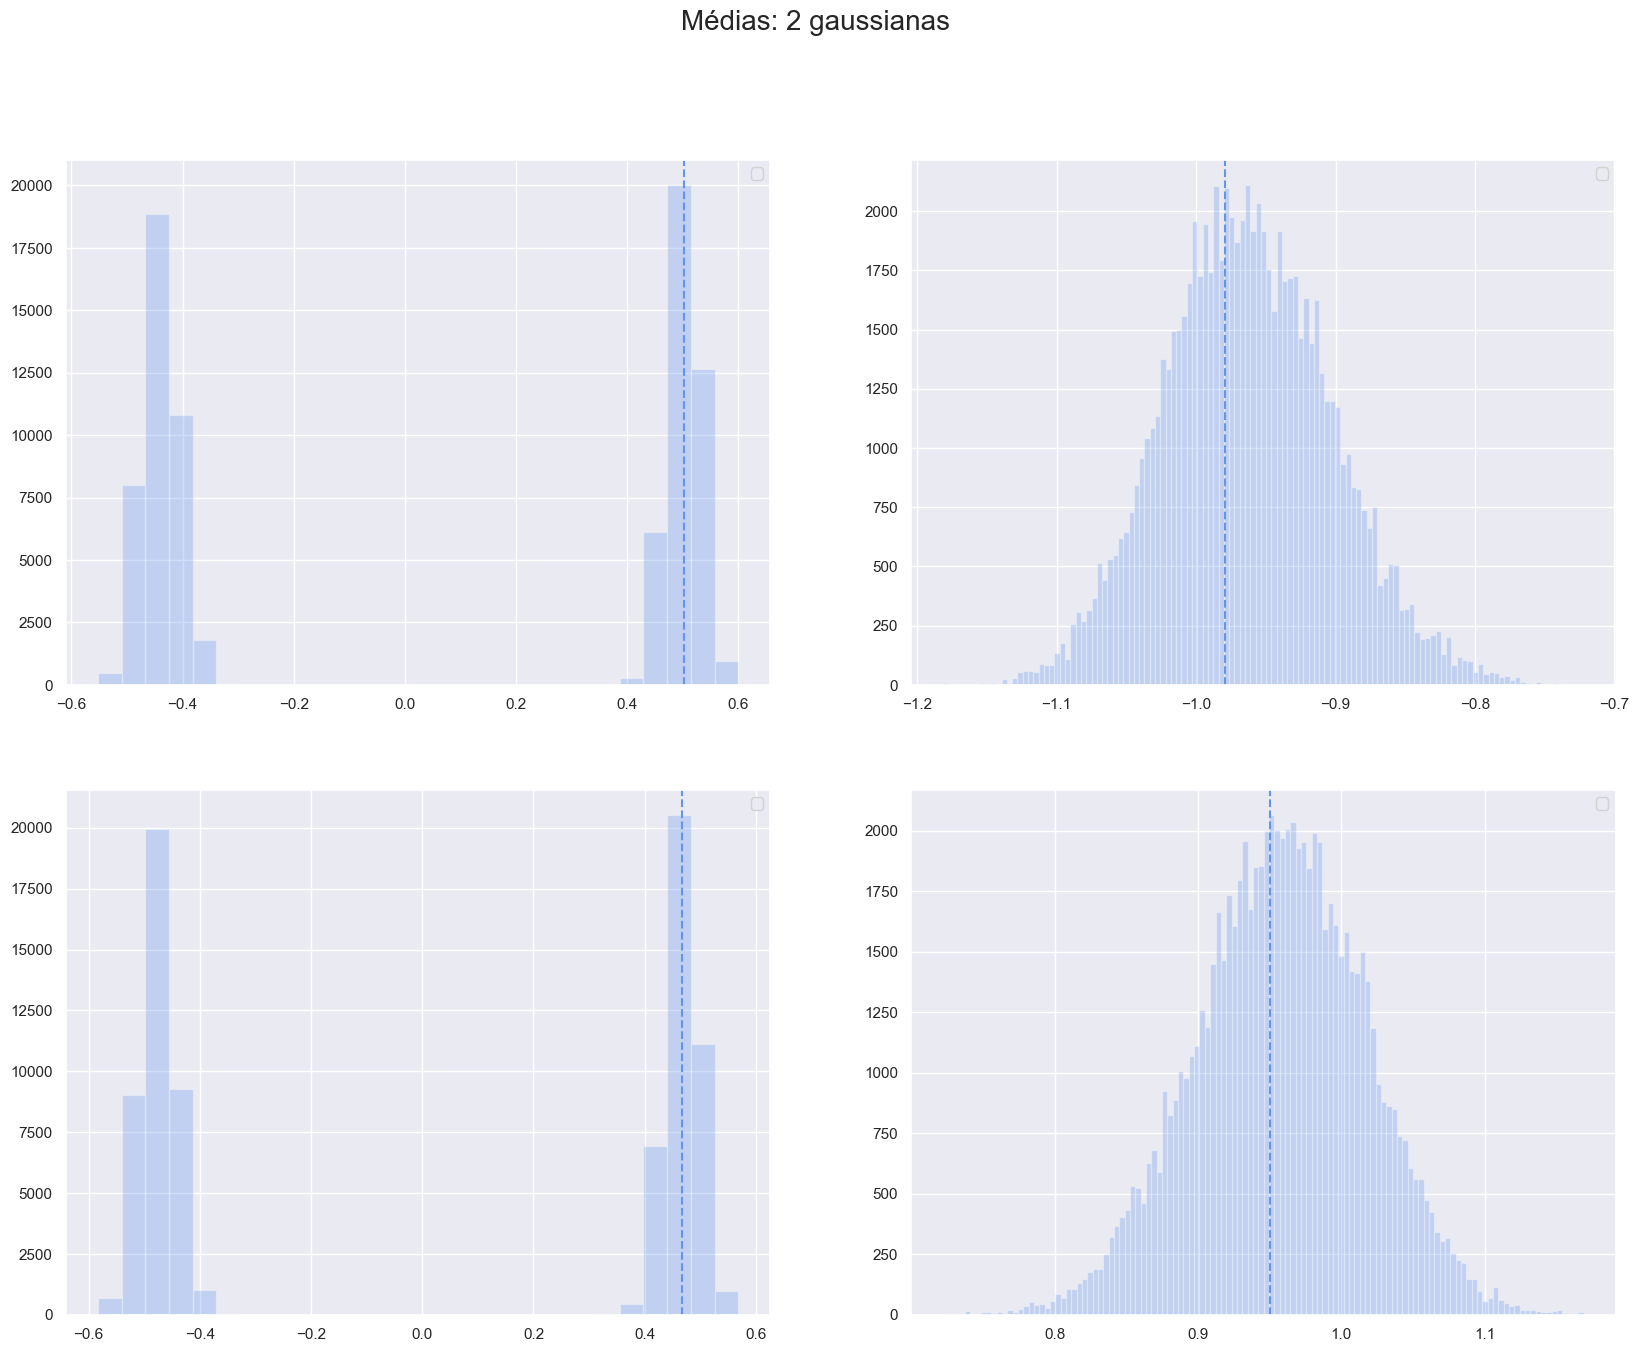

In [ ]:
CASE = 'iii'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[2],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.67110091,  0.16255304],
       [-0.12009567,  1.29370217]]),
       np.float64(-4097.370697532228)),
 '2': (array([[-0.53500154, -0.57416084],
       [-0.34194939,  1.16937085]]),
       np.float64(-4220.914560793781)),
 '3': (array([[ 0.67936995, -0.01228437],
       [-0.02828195,  1.3051685 ]]),
       np.float64(-4097.689051431079)),
 '4': (array([[-0.55067906,  0.61757175],
       [ 0.30968592,  1.13834427]]),
       np.float64(-4226.287901899781))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 0.67936995, -0.01228437],
       [-0.02828195,  1.3051685 ]])
Smallest distance (Frobenius): 1.175


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


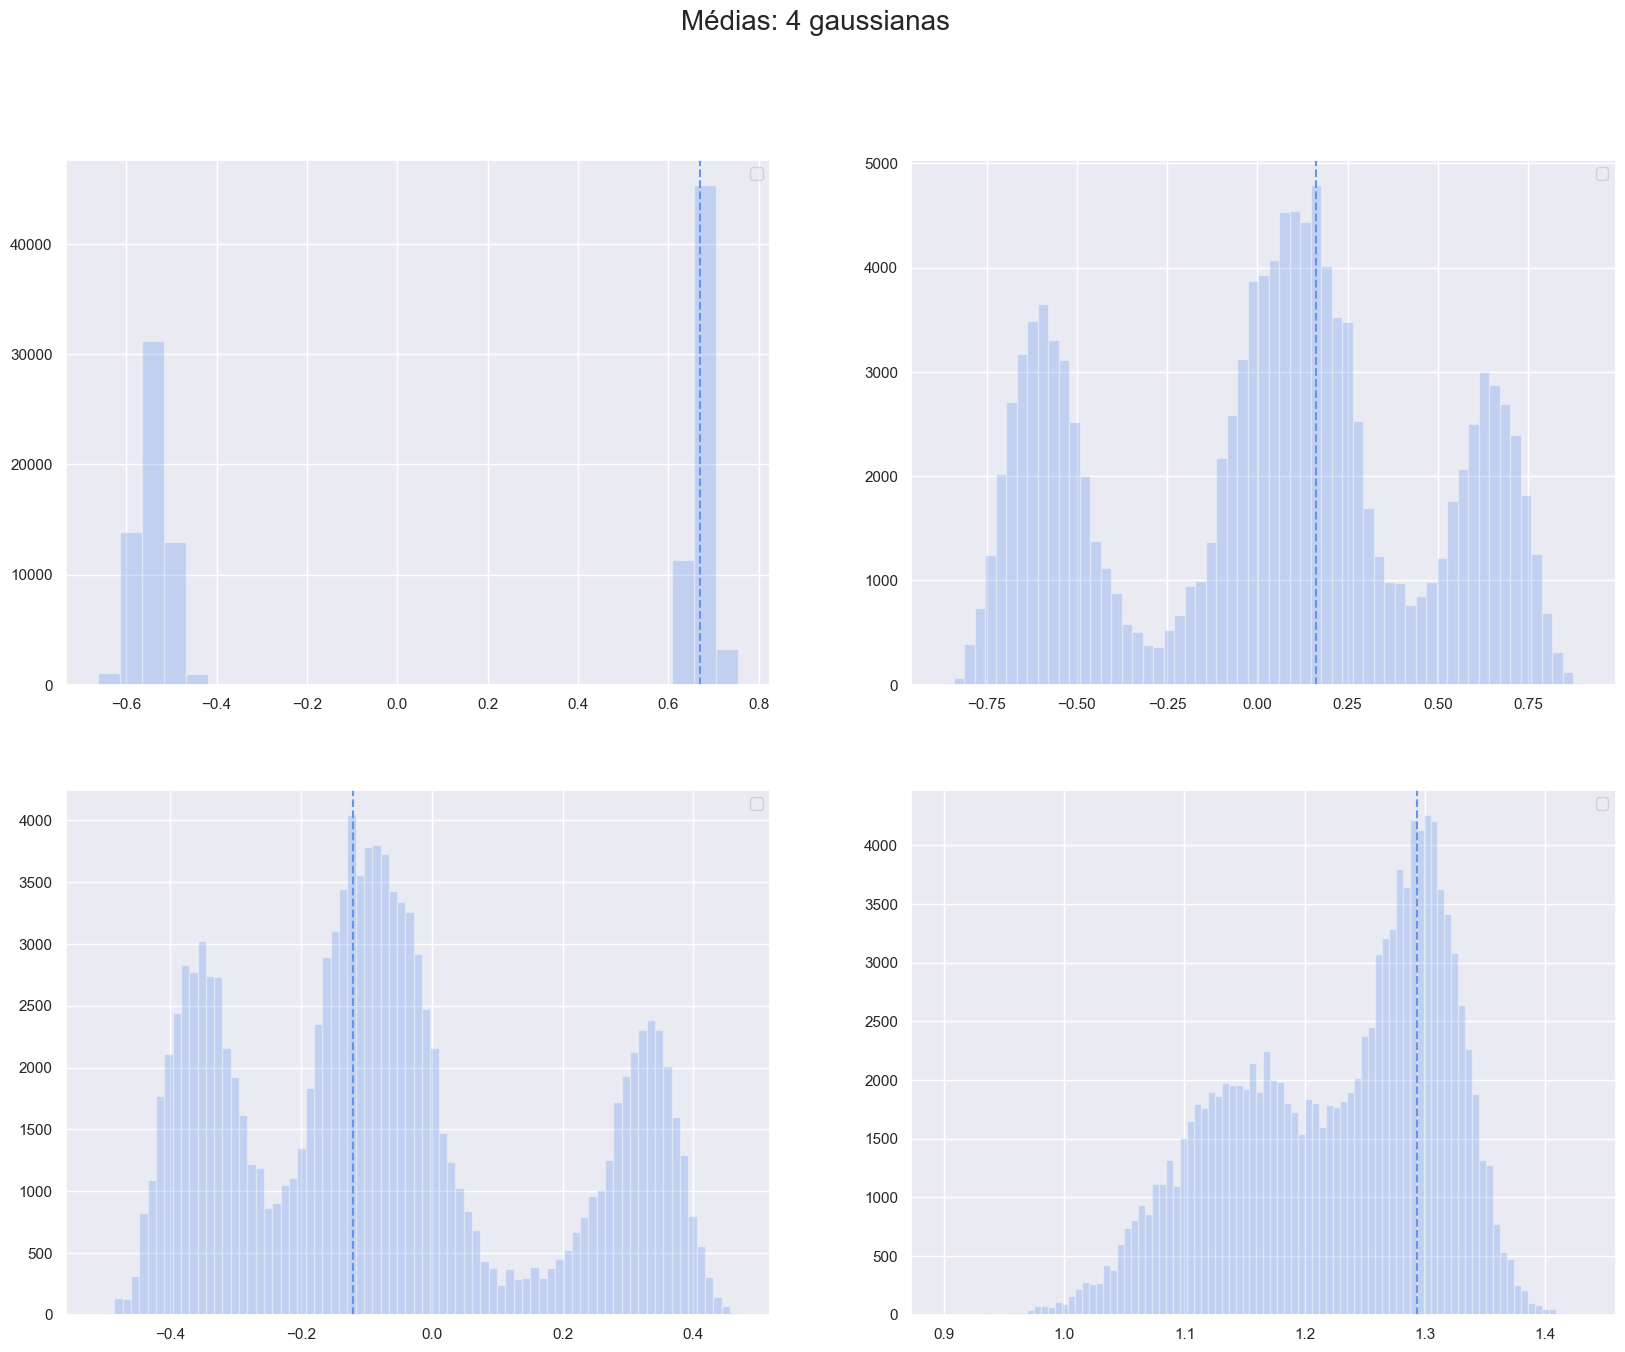

In [ ]:
CASE = 'iv'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[4],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Sorted gaussian means by greatest posterior:

{'1': (array([[-0.42571956, -0.84571247],
       [ 0.44897267, -0.89760691]]),
       np.float64(-4263.08008437457)),
 '2': (array([[-0.42652124, -0.84265922],
       [-0.44733438,  0.89953958]]),
       np.float64(-4263.087626641909)),
 '3': (array([[-0.06693397,  0.87506256],
       [ 0.04582888,  0.86801491]]),
       np.float64(-5790.850270193985)),
 '4': (array([[ 0.447592  , -0.90009115],
       [ 0.42691966,  0.8430569 ]]),
       np.float64(-4263.082296031379)),
 '5': (array([[ 0.44750575, -0.90073982],
       [-0.42713069, -0.84281438]]),
       np.float64(-4263.081258903044)),
 '6': (array([[-0.03736444,  0.87063422],
       [-0.01394742, -0.87330692]]),
       np.float64(-6569.336785898663))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 0.447592  , -0.90009115],
       [ 0.42691966,  0.8430569 ]])
Smallest distance (Frobenius): 0.207

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


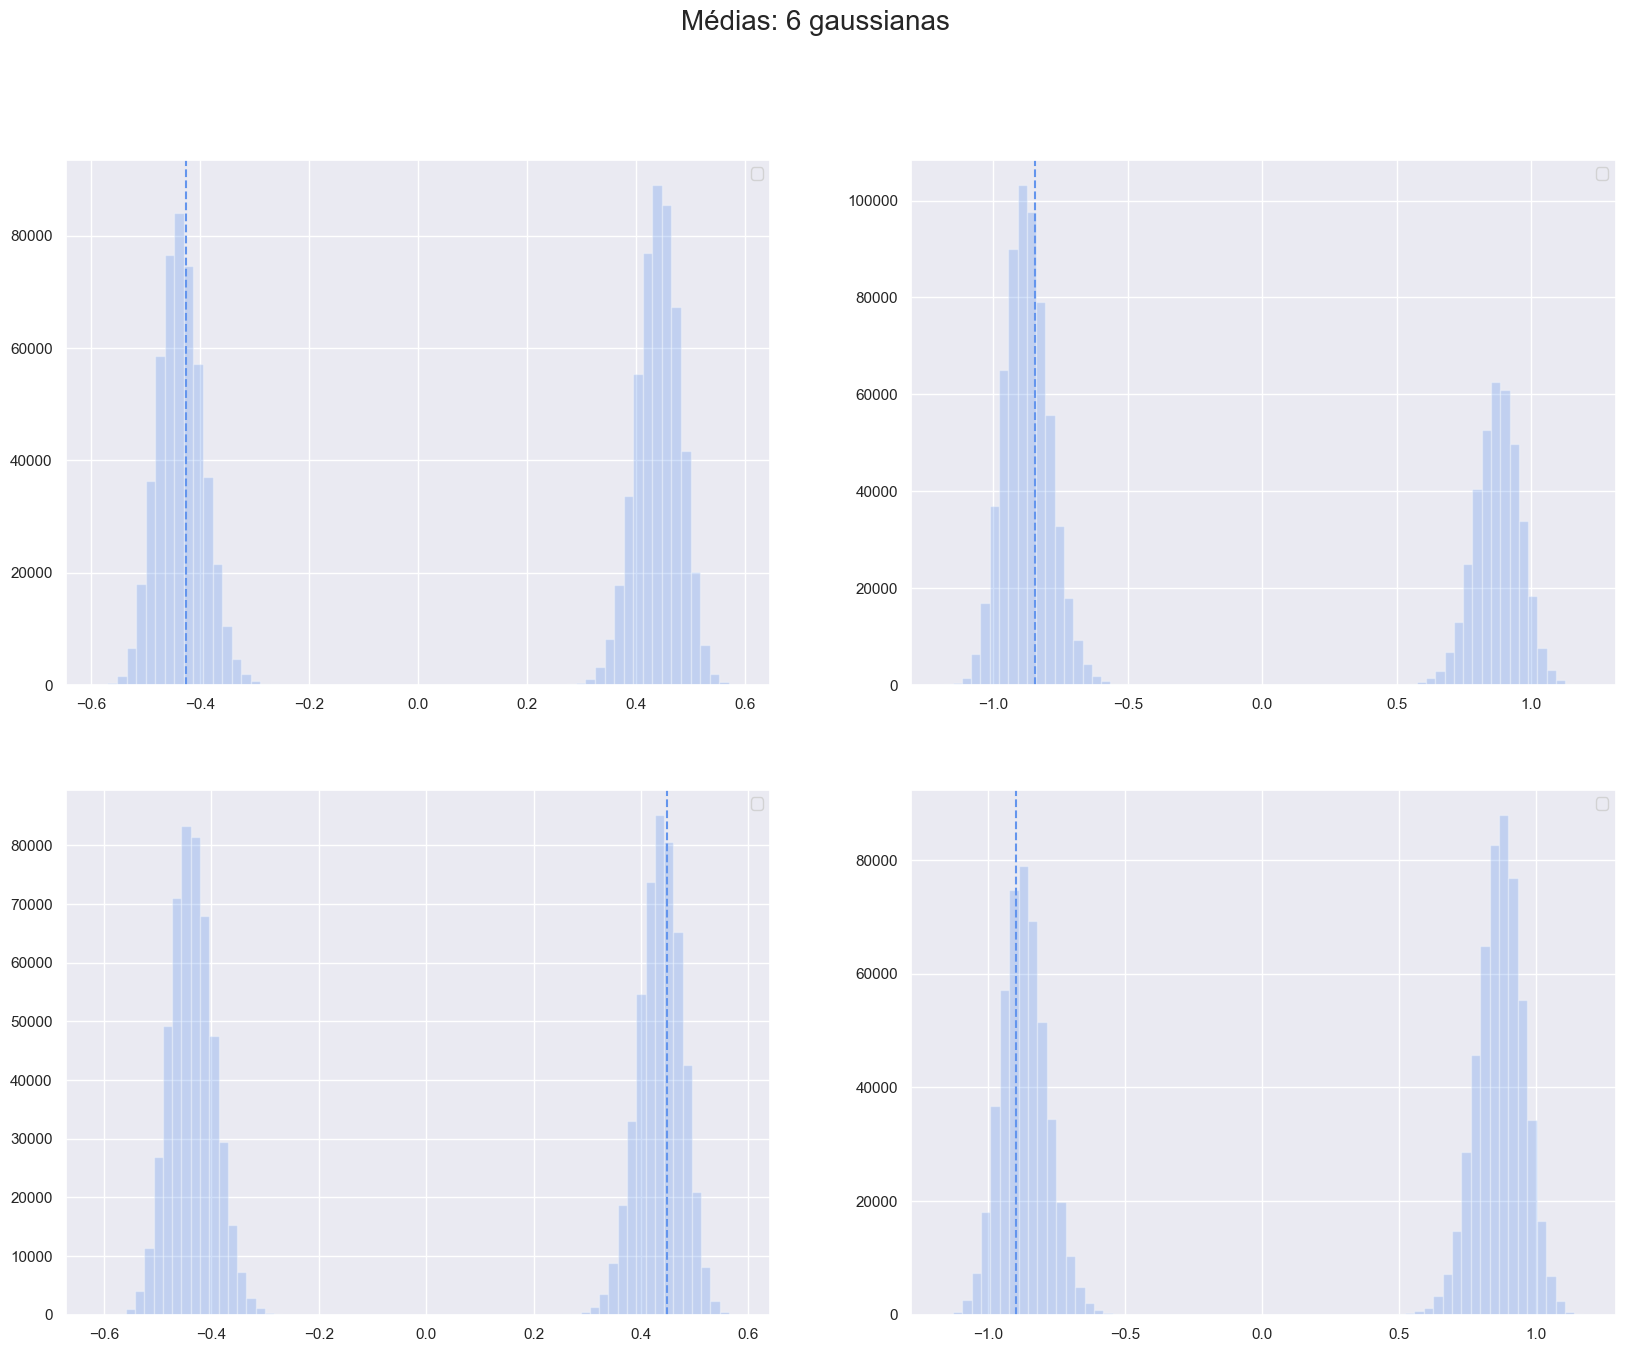

In [ ]:
CASE = 'v'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[6],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B']
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.44800176, -0.89958299],
       [ 0.42660543,  0.84389619]]),
       np.float64(-4263.081011074818)),
 '2': (array([[-0.42613283, -0.84350875],
       [ 0.44830516, -0.89806255]]),
       np.float64(-4263.108389170625)),
 '3': (array([[ 0.44864209, -0.89854525],
       [-0.42571535, -0.84545424]]),
       np.float64(-4263.101766629527)),
 '4': (array([[-0.00850667,  0.86473675],
       [-0.01606432,  0.87843731]]),
       np.float64(-8509.27224193404)),
 '5': (array([[-0.42738121, -0.84229091],
       [-0.44724964,  0.90064828]]),
       np.float64(-4263.091770333366)),
 '6': (array([[ 0.01879748,  0.87372612],
       [ 0.0391076 , -0.86852145]]),
       np.float64(-6448.618202877922))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 0.44800176, -0.89958299],
       [ 0.42660543,  0.84389619]])
Smallest distance (Frobenius): 0.206

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


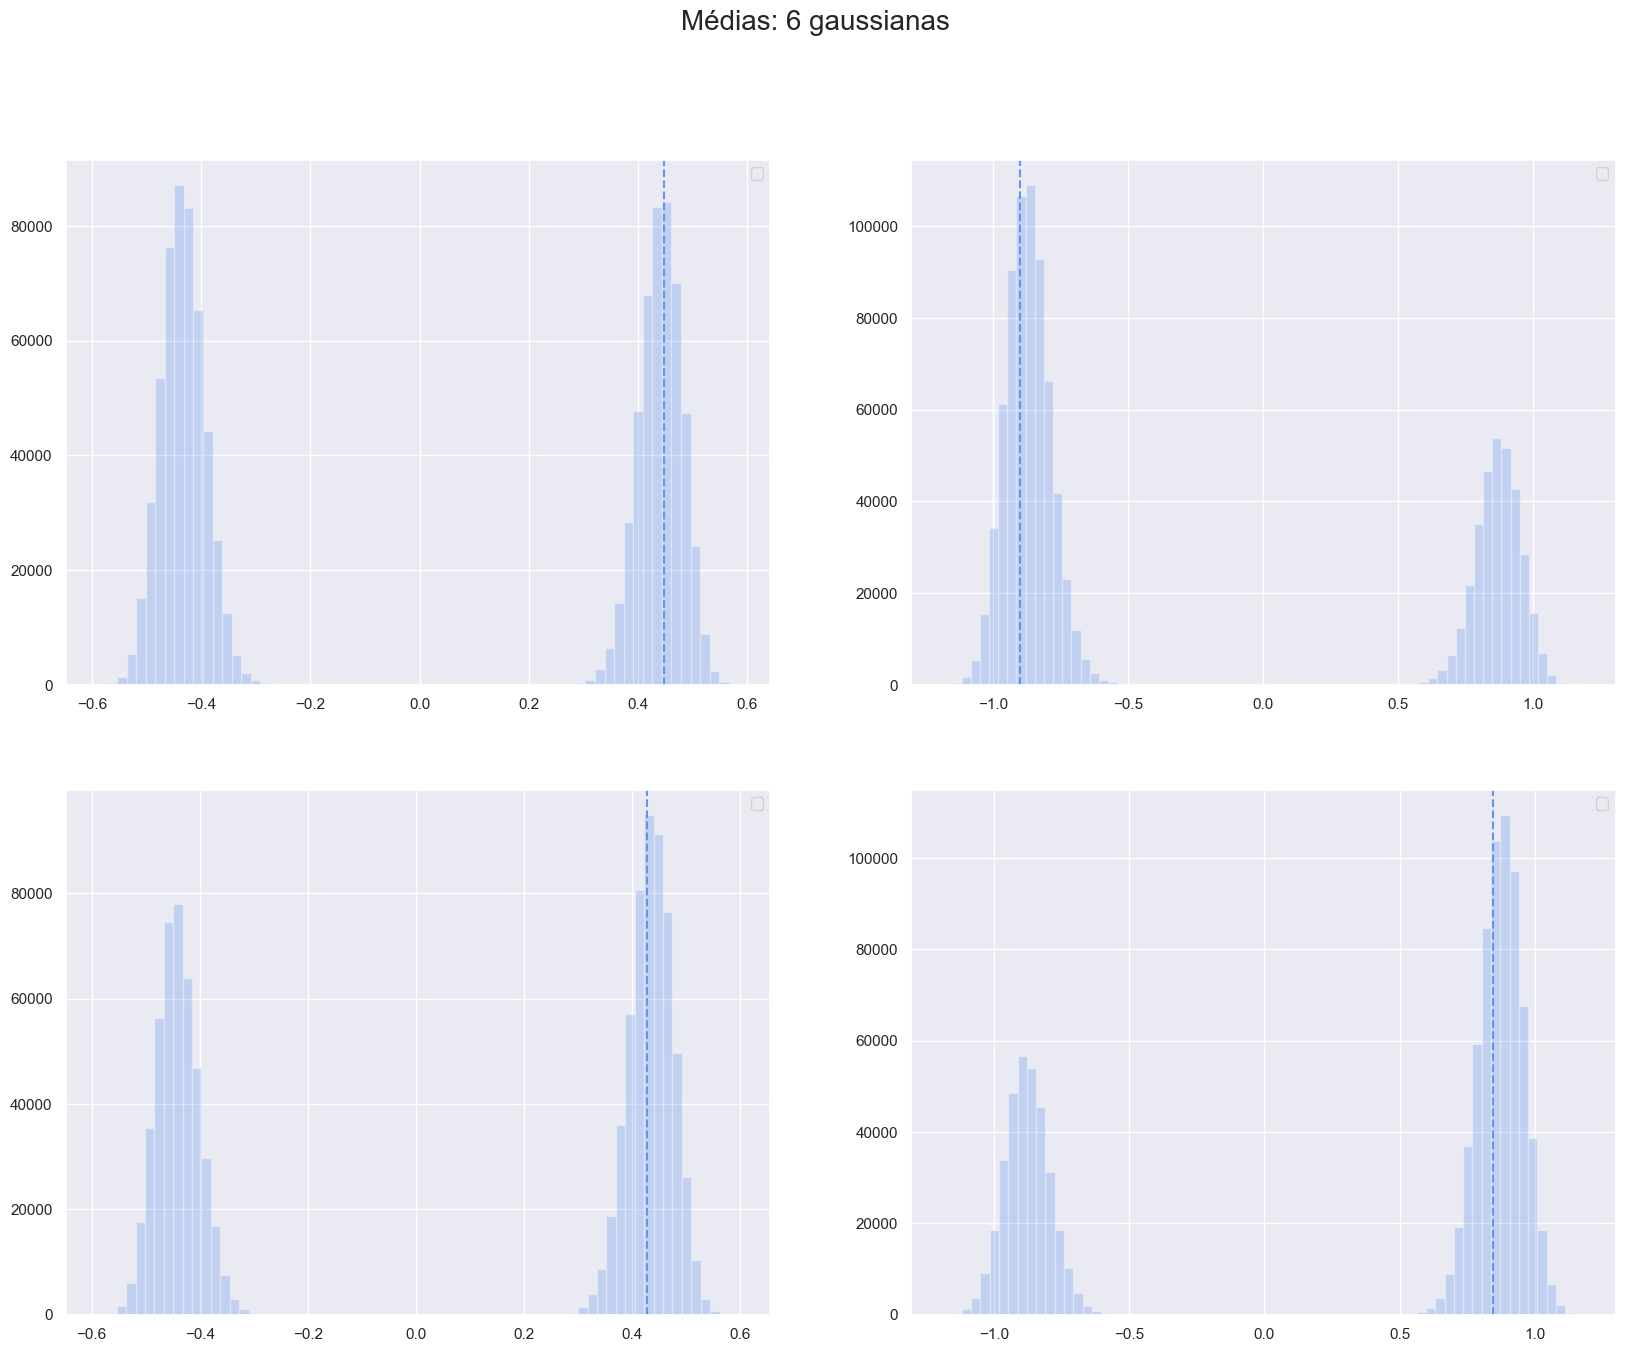

In [ ]:
CASE = 'vi'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[6],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.45701539, -0.89870133],
       [ 0.42345303,  0.87035313]]),
       np.float64(-4264.947831221993)),
 '2': (array([[-0.40069277, -0.86812398],
       [-0.4366075 ,  0.88505972]]),
       np.float64(-4350.882018668277))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 0.45701539, -0.89870133],
       [ 0.42345303,  0.87035313]])
Smallest distance (Frobenius): 0.186


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


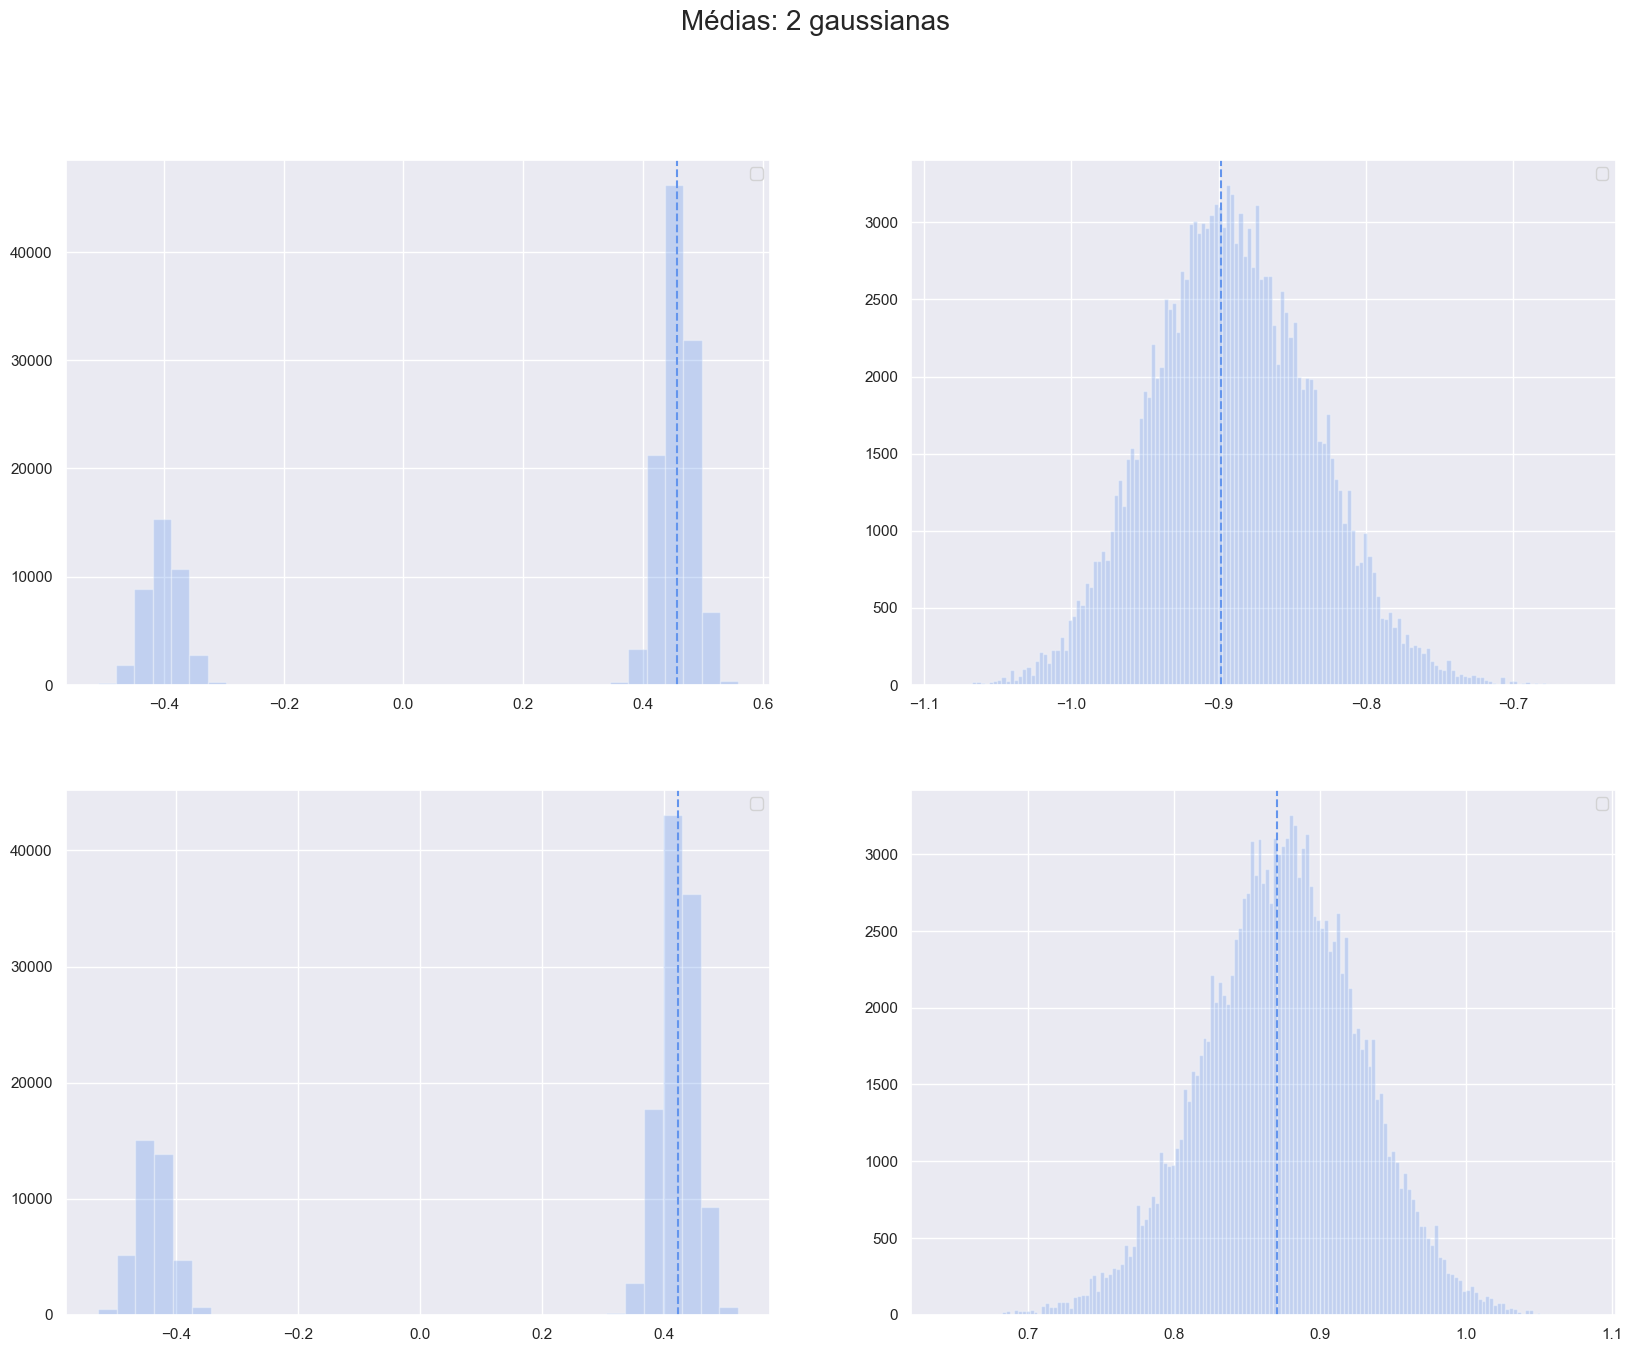

In [ ]:
CASE = 'vii'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[2],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.60804046,  0.11235925],
       [-0.09198413,  1.18848631]]),
       np.float64(-4291.296264510274)),
 '2': (array([[-0.55571412,  0.12590716],
       [ 0.03430732,  1.16312336]]),
       np.float64(-4412.08242098859)),
 '3': (array([[-0.47779604, -0.56834586],
       [-0.33250883,  1.05430777]]),
       np.float64(-4402.160554413372)),
 '4': (array([[-0.49713827,  0.60126029],
       [ 0.2980838 ,  1.02770148]]),
       np.float64(-4407.368576028187))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 0.60804046,  0.11235925],
       [-0.09198413,  1.18848631]])
Smallest distance (Frobenius): 1.279


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


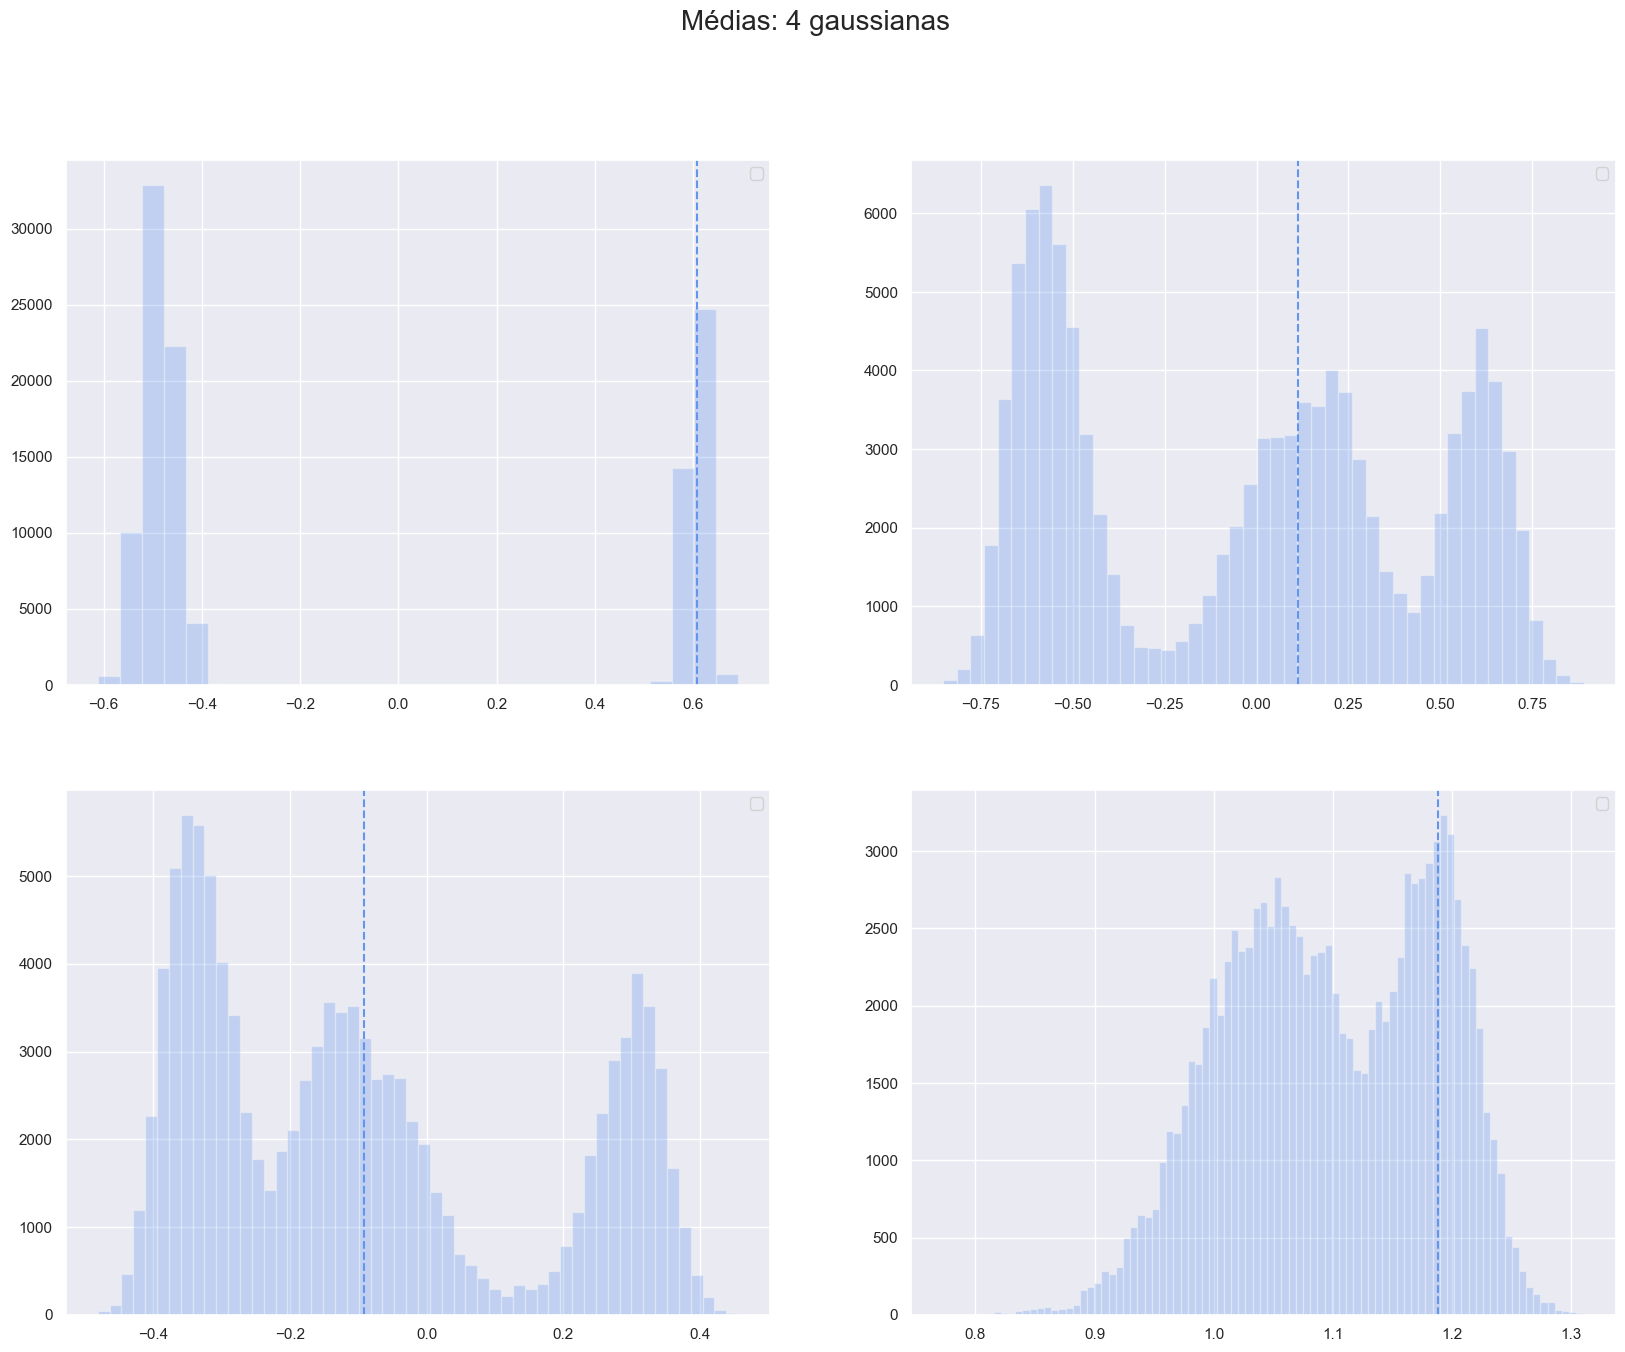

In [ ]:
CASE = 'viii'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[4],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 1.44738281, -0.01903298],
       [ 0.05011454, -2.90714012]]),
       np.float64(-2522.96280134919)),
 '2': (array([[-1.44553203,  0.00739661],
       [-0.05683387,  2.90399809]]),
       np.float64(-2522.9703601565407)),
 '3': (array([[ 0.06070498, -2.90021431],
       [-1.44530814, -0.00299615]]),
       np.float64(-2522.9793572992994)),
 '4': (array([[-5.94169783e-02,  2.90437741e+00],
       [ 1.44654810e+00, -2.20349950e-03]]),
       np.float64(-2522.9664321707223)),
 '5': (array([[-1.44504922,  0.01290379],
       [ 0.05552406, -2.90266362]]),
       np.float64(-2522.9749576979516)),
 '6': (array([[ 1.44719206, -0.00792929],
       [-0.05764711,  2.90521598]]),
       np.float64(-2522.963331318735)),
 '7': (array([[ 0.04903561, -2.90610396],
       [ 1.44723788, -0.02503032]]),
       np.float64(-2522.964837146862)),
 '8': (array([[-0.06753156,  2.90577082],
       [-1.4455841 , -0.01361884]]),
       np.float64(-2522

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


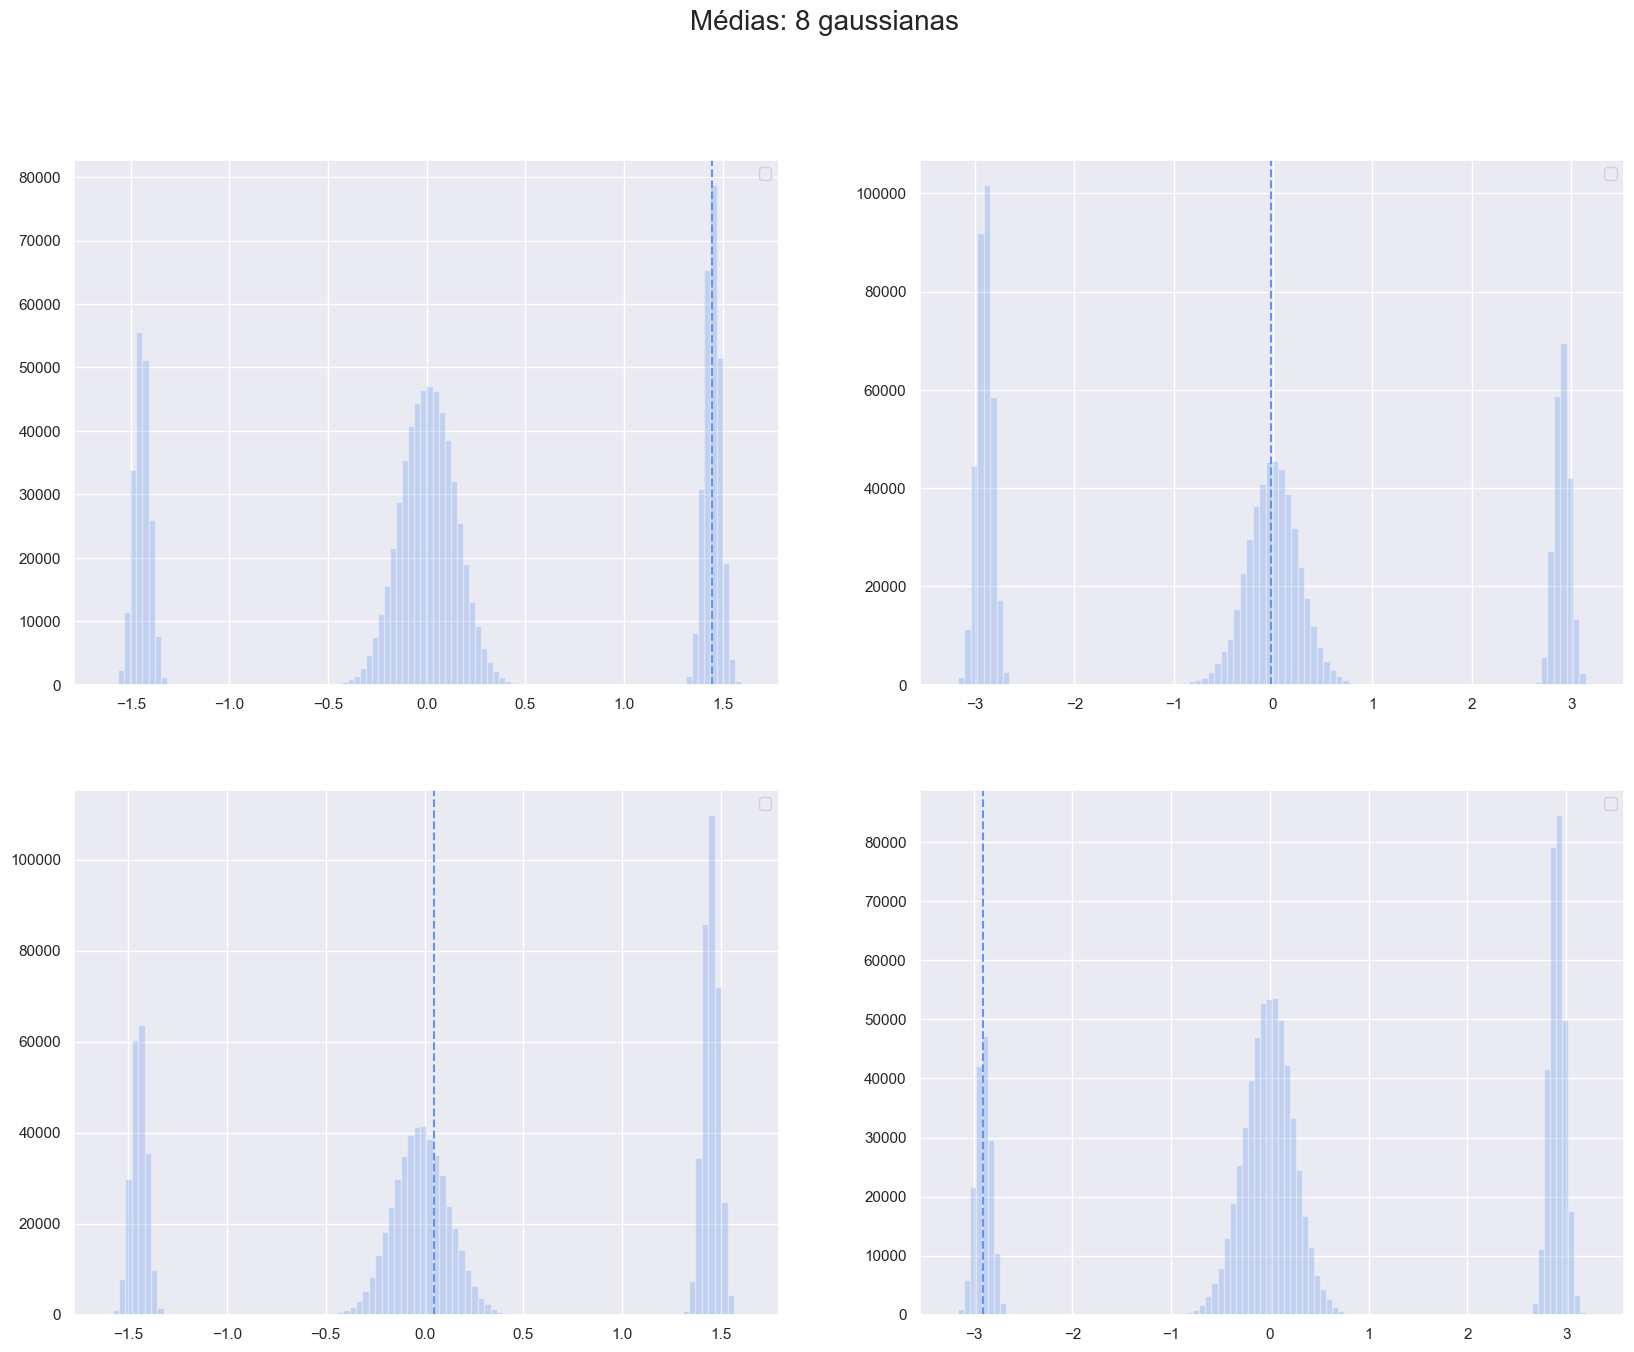

In [ ]:
CASE = 'ix'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[8],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.05643556, -2.90462029],
       [ 1.44722563, -0.00932398]]),
       np.float64(-2522.9927959904107)),
 '2': (array([[-0.06427919,  2.90675157],
       [ 1.44674654,  0.00780187]]),
       np.float64(-2523.0515259151516)),
 '3': (array([[ 1.4463549 , -0.04977202],
       [-0.03666236,  2.90253118]]),
       np.float64(-2523.0138810318467)),
 '4': (array([[ 0.04156361, -2.9045245 ],
       [-1.44738867,  0.04028716]]),
       np.float64(-2523.015647466931)),
 '5': (array([[ 1.44612536,  0.00449993],
       [ 0.06253566, -2.90388682]]),
       np.float64(-2523.0559006874732)),
 '6': (array([[-1.44685907,  0.02172591],
       [-0.0501838 ,  2.90253607]]),
       np.float64(-2523.014123283298)),
 '7': (array([[-1.44724315,  0.01769609],
       [ 0.05323796, -2.90615805]]),
       np.float64(-2523.064476782518)),
 '8': (array([[-0.04821822,  2.90548602],
       [-1.44759942,  0.02436547]]),
       np.float64(-2523.066362428168))

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


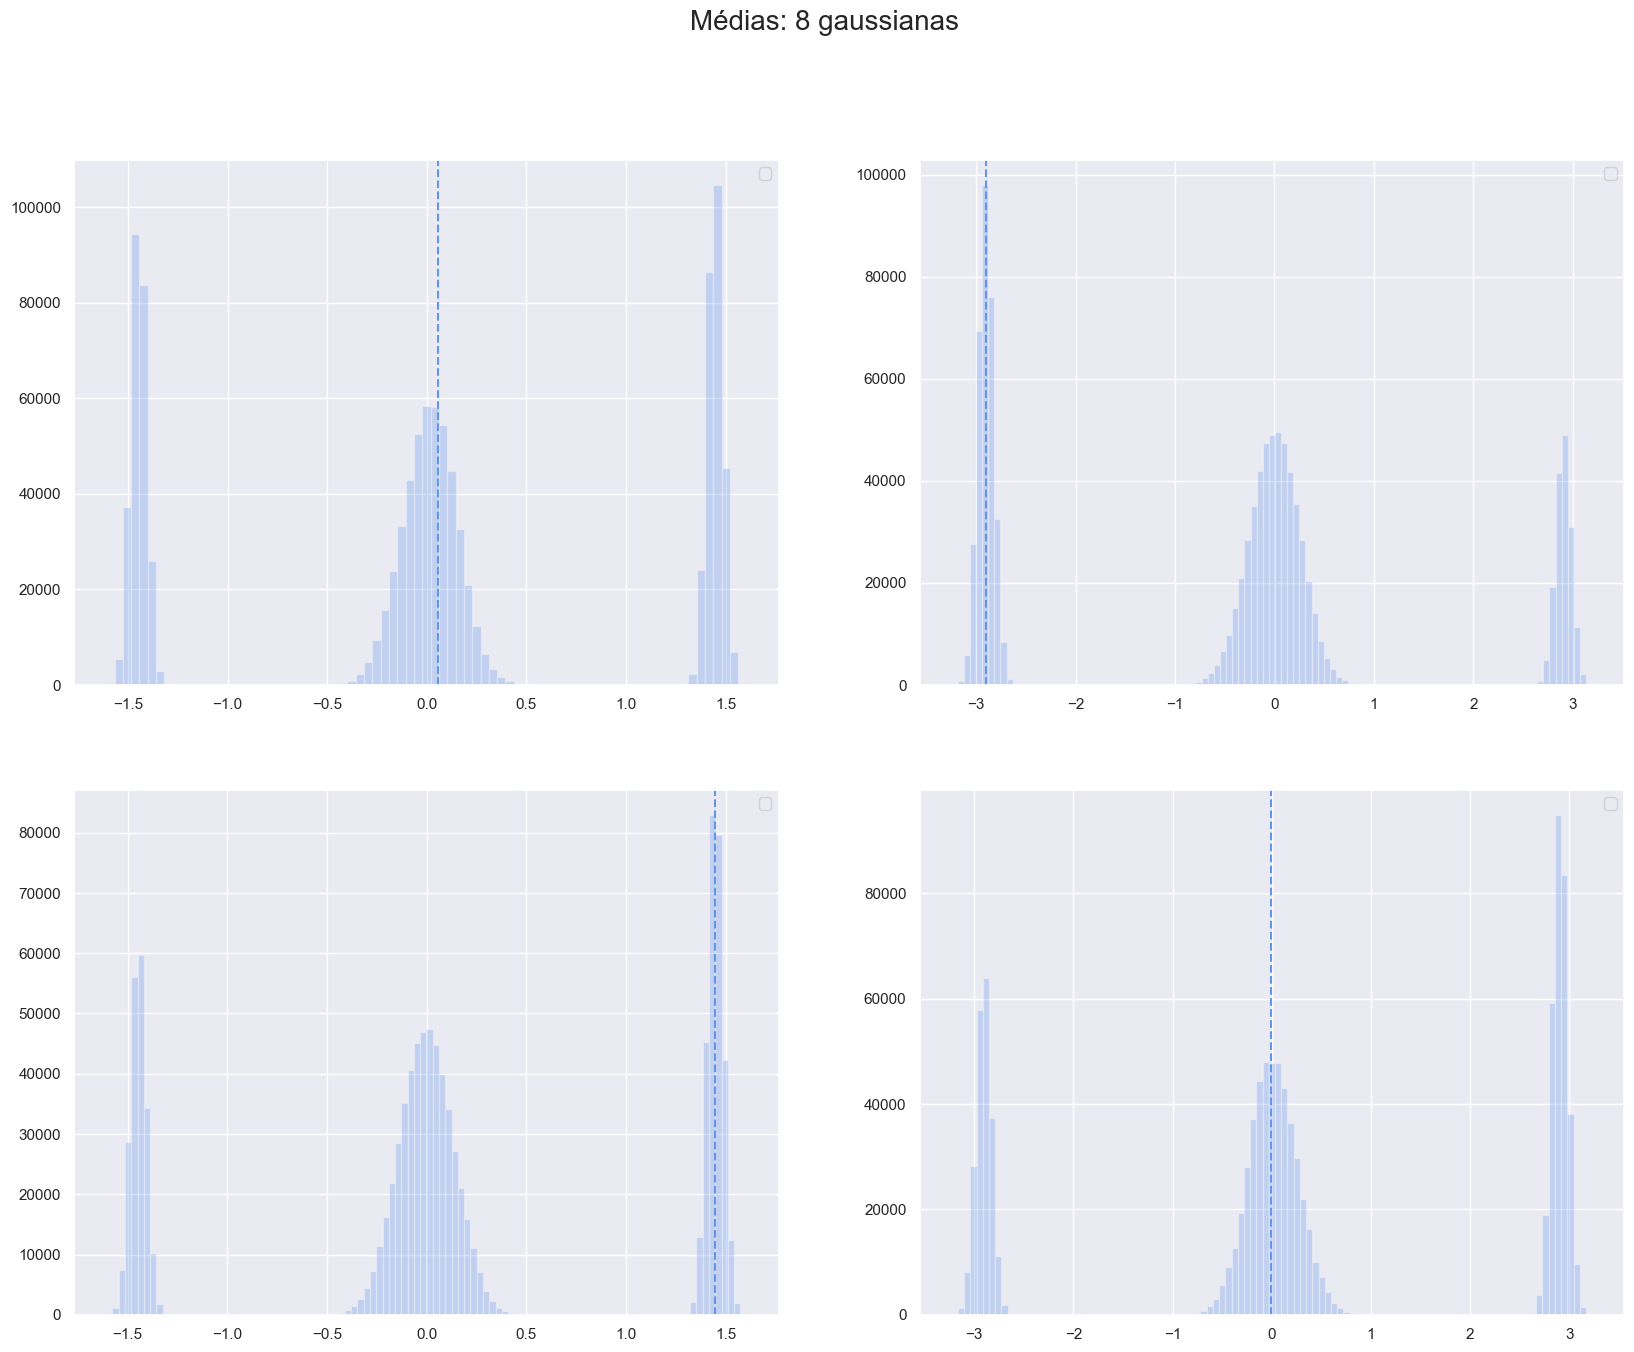

In [ ]:
CASE = 'x'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[8],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 0.96632969, -1.72310074],
       [ 0.91938887,  1.69874133]]),
       np.float64(-2635.037052193782)),
 '2': (array([[-0.78556564, -1.74928325],
       [-0.91023   ,  1.63782153]]),
       np.float64(-2814.3593017864823))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 0.96632969, -1.72310074],
       [ 0.91938887,  1.69874133]])
Smallest distance (Frobenius): 1.185


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


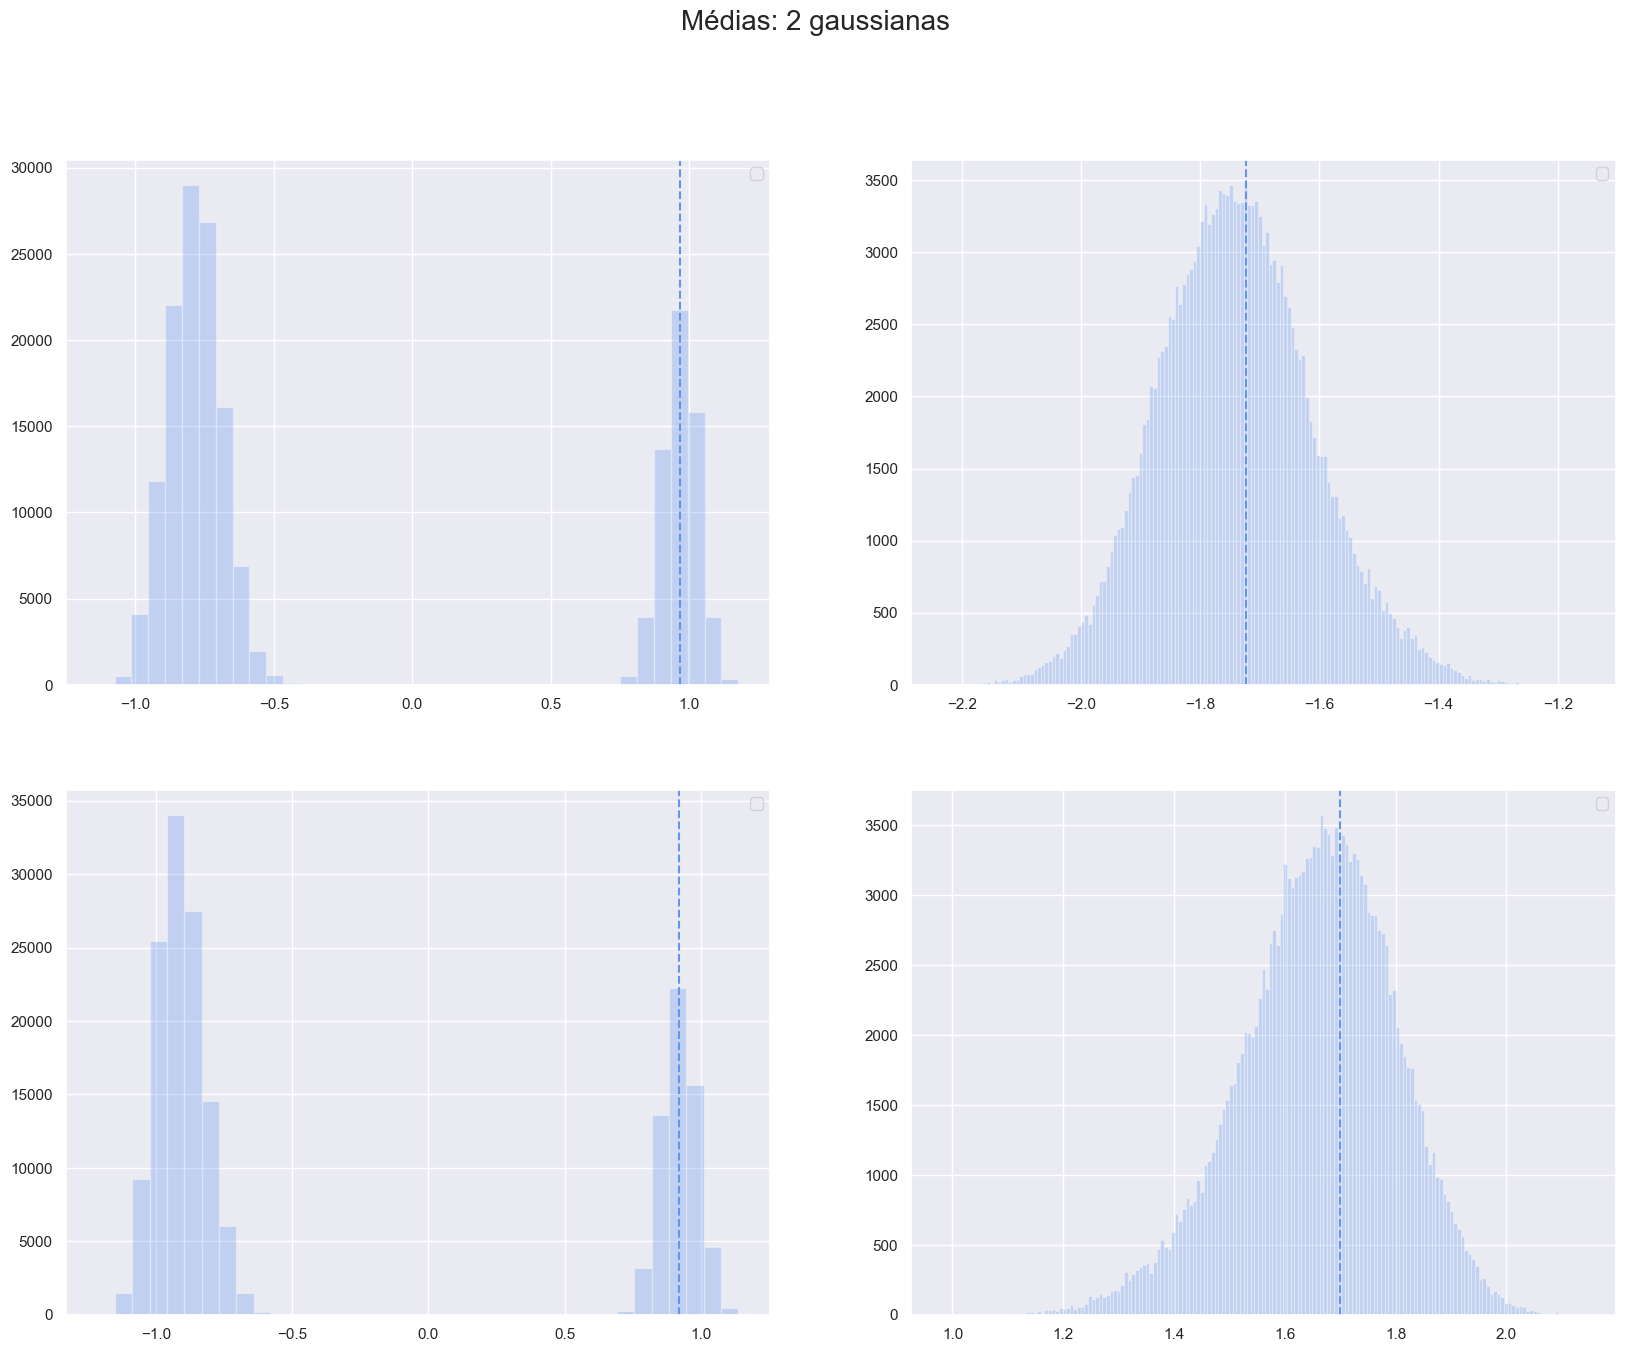

In [ ]:
CASE = 'xi'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[2],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
    # samples_per_chain=10000
)

Sorted gaussian means by greatest posterior:

{'1': (array([[ 1.39551451, -0.02163133],
       [-0.02940375,  2.30395723]]),
       np.float64(-2653.901306329266)),
 '2': (array([[-1.1832231 , -0.09087795],
       [-0.09235411,  2.29634064]]),
       np.float64(-2911.593155873095))}
----------------------------------------------------------------------------------------------------
Gaussian mean closest to true B:
array([[ 1.39551451, -0.02163133],
       [-0.02940375,  2.30395723]])
Smallest distance (Frobenius): 1.934


/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_10761/1299563945.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dist_axs[i,j].legend()


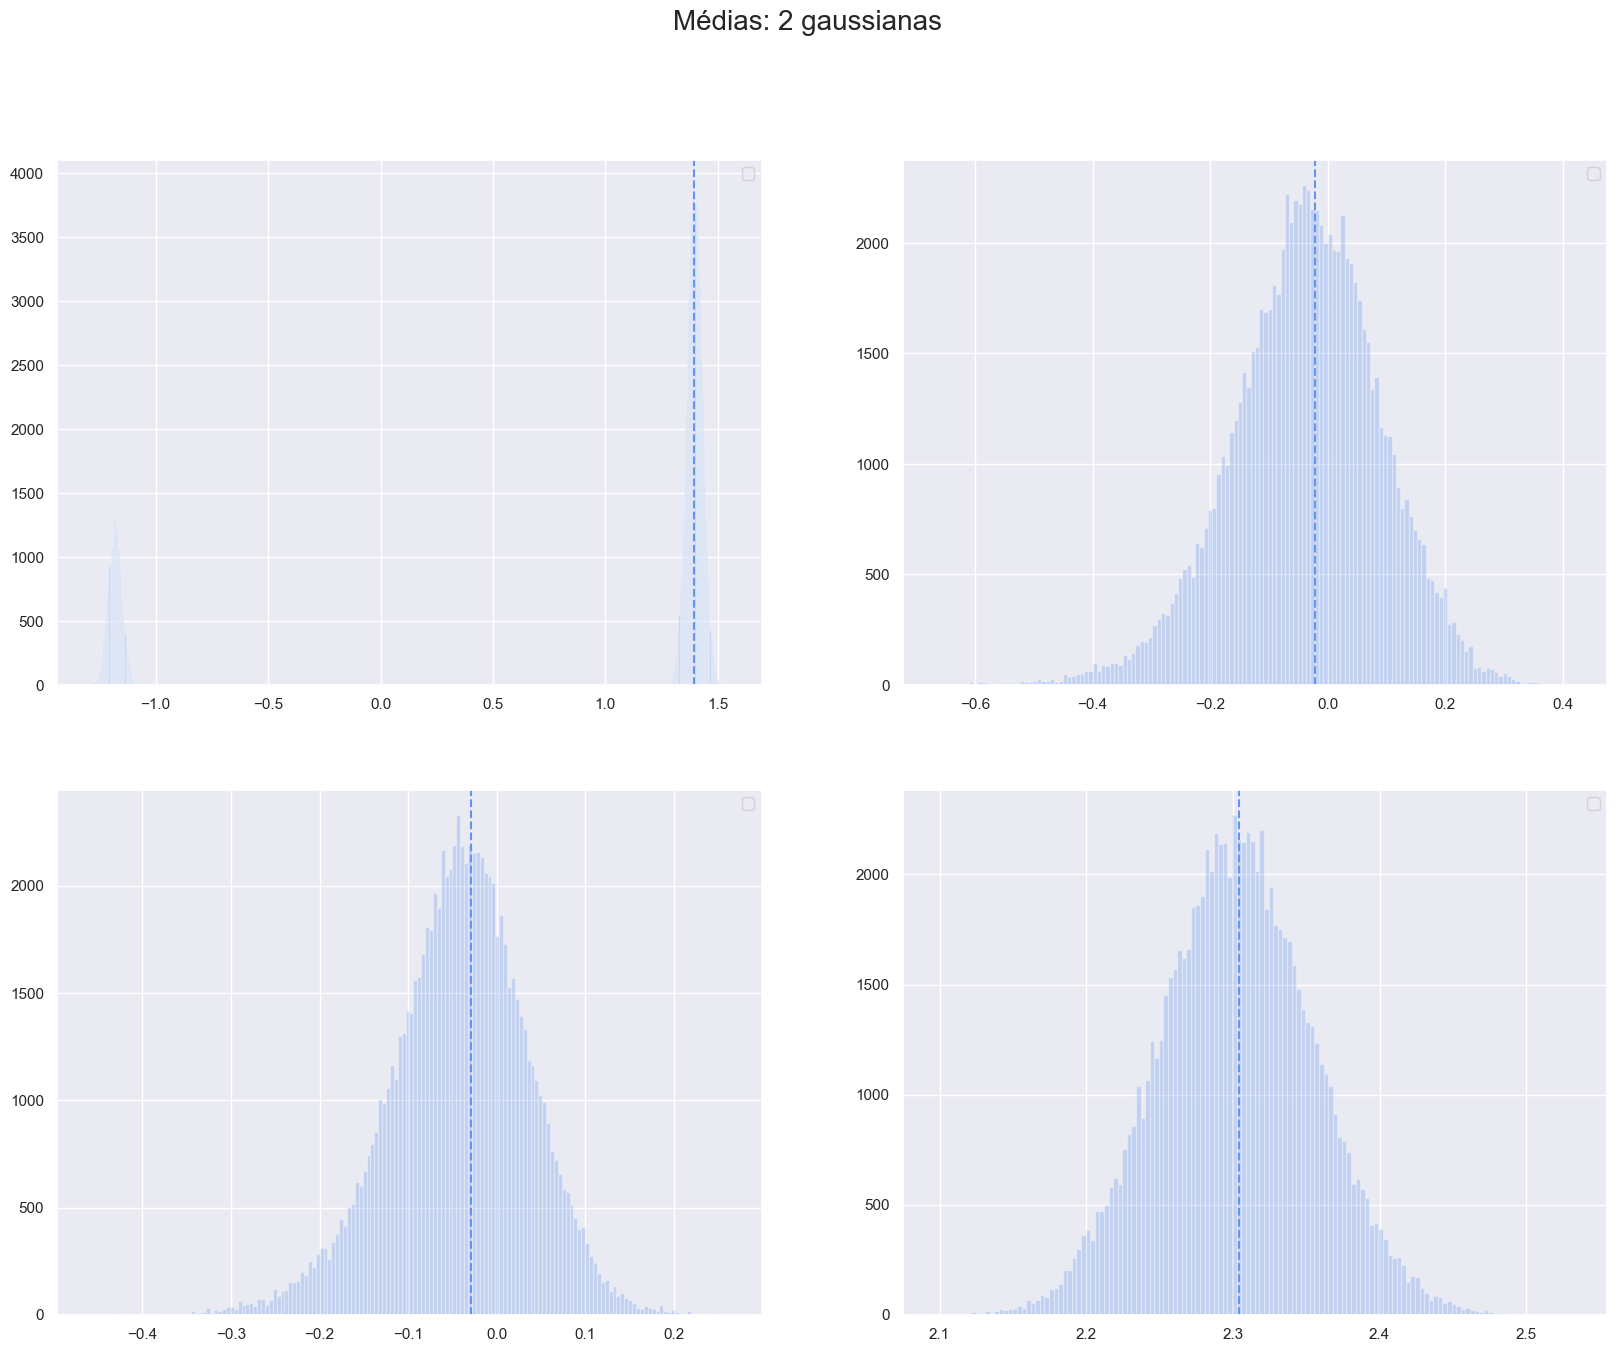

In [ ]:
CASE = 'xii'
REALIZATION = '0'
visualize_cluster_centroids(
    case=CASE,
    realization=REALIZATION,
    parser=parser,
    n_clusters=[2],
    clustering_df=bic_df,
    B=parser.execution_config['general']['B'],
)